# ***Exploratory Data Analysis - Global Road Accident***

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Supress futurewarnings to protect privacy
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Read data

data = pd.read_csv("road_accident_dataset.csv")
data.head()

,Country,Year,Month,Day of Week,Time of Day,Urban/Rural,Road Type,Weather Conditions,Visibility Level,Number of Vehicles Involved,...,Number of Fatalities,Emergency Response Time,Traffic Volume,Road Condition,Accident Cause,Insurance Claims,Medical Cost,Economic Loss,Region,Population Density
0,USA,2002,October,Tuesday,Evening,Rural,Street,Windy,220.414651,1,...,2,58.625720,7412.752760,Wet,Weather,4,40499.856982,22072.878502,Europe,3866.273014
1,UK,2014,December,Saturday,Evening,Urban,Street,Windy,168.311358,3,...,1,58.041380,4458.628820,Snow-covered,Mechanical Failure,3,6486.600073,9534.399441,North America,2333.916224
2,USA,2012,July,Sunday,Afternoon,Urban,Highway,Snowy,341.286506,4,...,4,42.374452,9856.915064,Wet,Speeding,4,29164.412982,58009.145124,South America,4408.889129
3,UK,2017,May,Saturday,Evening,Urban,Main Road,Clear,489.384536,2,...,3,48.554014,4958.646267,Icy,Distracted Driving,3,25797.212566,20907.151302,Australia,2810.822423
4,Canada,2002,July,Tuesday,Afternoon,Rural,Highway,Rainy,348.344850,1,...,4,18.318250,3843.191463,Icy,Distracted Driving,8,15605.293921,13584.060759,South America,3883.645634


### **Data Dictionary**

1. `Country`: Name of the country where the accident occurred.  
2. `Year`: Year in which the accident occurred.  
3. `Month`: Month in which the accident occurred.  
4. `Day of Week`: Day of the week when the accident occurred.  
5. `Time of Day`: Time when the accident occurred (e.g., morning, evening, night).  
6. `Urban/Rural`: Indicates whether the accident occurred in an urban or rural area.  
7. `Road Type`: Type of road where the accident occurred (e.g., highway, intersection).  
8. `Weather Conditions`: Weather conditions at the time of the accident (e.g., clear, rainy).  
9. `Visibility Level`: Visibility level at the time of the accident.  
10. `Number of Vehicles Involved`: Number of vehicles involved in the accident.  
11. `Speed Limit`: Speed limit on the road where the accident occurred.  
12. `Driver Age Group`: Age group of the driver(s) involved (e.g., 18-25, 26-35).  
13. `Driver Gender`: Gender of the driver(s) involved (e.g., male, female).  
14. `Driver Alcohol Level`: Alcohol level of the driver(s) involved.  
15. `Driver Fatigue`: Indicator of whether driver fatigue was a factor in the accident.  
16. `Vehicle Condition`: Condition of the vehicle(s) involved (e.g., good, faulty).  
17. `Pedestrians Involved`: Number of pedestrians involved in the accident.  
18. `Cyclists Involved`: Number of cyclists involved in the accident.  
19. `Accident Severity`: Severity of the accident (e.g., minor, serious, fatal).  
20. `Number of Injuries`: Total number of injuries reported in the accident.  
21. `Number of Fatalities`: Total number of fatalities reported in the accident.  
22. `Emergency Response Time`: Time taken for emergency responders to arrive at the scene.  
23. `Traffic Volume`: Traffic volume on the road at the time of the accident.  
24. `Road Condition`: Condition of the road (e.g., wet, dry, icy).  
25. `Accident Cause`: Primary cause of the accident (e.g., speeding, distraction).  
26. `Insurance Claims`: Number of insurance claims filed related to the accident.  
27. `Medical Cost`: Total medical cost incurred due to the accident.  
28. `Economic Loss`: Estimated economic loss due to the accident.  
29. `Region`: Region or administrative division where the accident occurred.  
30. `Population Density`: Population density in the area of the accident.

## ***Preliminary Analysis Plan:***

1. Data Inspection and Preparation
2. High Level Data Overview
   1. Summary Statistics
   2. Visualize Distribution
   3. Feature Correlations
3. Temporal Analysis
4. Geographic Analysis  
6. Driver and Vehicle Factors
7. Environmental and Road Conditions
8. Severity and Impact Analysis
9. Advanced Analysis
   1. Clustering
   2. Predictive Modelling
   3. Impact Metrics
   4. Seasonal Effects

## **1. Data Exploration and Preparation**

In [3]:
# Check shape of data

data.shape

(132000, 30)

In [4]:
# Get metadata

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132000 entries, 0 to 131999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Country                      132000 non-null  object 
 1   Year                         132000 non-null  int64  
 2   Month                        132000 non-null  object 
 3   Day of Week                  132000 non-null  object 
 4   Time of Day                  132000 non-null  object 
 5   Urban/Rural                  132000 non-null  object 
 6   Road Type                    132000 non-null  object 
 7   Weather Conditions           132000 non-null  object 
 8   Visibility Level             132000 non-null  float64
 9   Number of Vehicles Involved  132000 non-null  int64  
 10  Speed Limit                  132000 non-null  int64  
 11  Driver Age Group             132000 non-null  object 
 12  Driver Gender                132000 non-null  object 
 13 

In [5]:
# Check Missing Values

data.isna().sum()

Country                        0
Year                           0
Month                          0
Day of Week                    0
Time of Day                    0
Urban/Rural                    0
Road Type                      0
Weather Conditions             0
Visibility Level               0
Number of Vehicles Involved    0
Speed Limit                    0
Driver Age Group               0
Driver Gender                  0
Driver Alcohol Level           0
Driver Fatigue                 0
Vehicle Condition              0
Pedestrians Involved           0
Cyclists Involved              0
Accident Severity              0
Number of Injuries             0
Number of Fatalities           0
Emergency Response Time        0
Traffic Volume                 0
Road Condition                 0
Accident Cause                 0
Insurance Claims               0
Medical Cost                   0
Economic Loss                  0
Region                         0
Population Density             0
dtype: int

In [6]:
# Check duplicated 

data.duplicated().sum()

np.int64(0)

#### **Key Insights:** 
- The dataset has 132000 entries and 30 columns. 
- No aparent null values.
- No duplicated entries in the dataset. 

## **Change Datatypes** 

In [7]:
# Driver fatigue feature is a boolean type
data['Driver Fatigue'] = data['Driver Fatigue'].astype(bool)

# Year as object
data['Year'] = data['Year'].astype('object')

## **Feature Engineering**
- Create Date feature with Month and Year

In [8]:
data['Date'] = pd.to_datetime(data['Month'].astype(str) + "-" + data['Year'].astype(str), format= '%B-%Y')
data['Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 132000 entries, 0 to 131999
Series name: Date
Non-Null Count   Dtype         
--------------   -----         
132000 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 1.0 MB


## **2. High Level Overview**

### **2.1 Numerical Variables**

In [9]:
# Separate numerical column names in a list

num_variables = [i for i in data.columns if data[i].dtype in ['int', 'float']]
print(num_variables)

['Visibility Level', 'Number of Vehicles Involved', 'Speed Limit', 'Driver Alcohol Level', 'Pedestrians Involved', 'Cyclists Involved', 'Number of Injuries', 'Number of Fatalities', 'Emergency Response Time', 'Traffic Volume', 'Insurance Claims', 'Medical Cost', 'Economic Loss', 'Population Density']


In [10]:
# Summary Stats: Numerical variables

data.describe()

,Visibility Level,Number of Vehicles Involved,Speed Limit,Driver Alcohol Level,Pedestrians Involved,Cyclists Involved,Number of Injuries,Number of Fatalities,Emergency Response Time,Traffic Volume,Insurance Claims,Medical Cost,Economic Loss,Population Density,Date
count,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000
mean,275.038776,2.501227,74.544068,0.125232,1.000773,0.998356,9.508205,1.995439,32.491746,5041.929098,4.495621,25198.454901,50437.505615,2506.476223,2012-06-05 20:18:02.618181632
min,50.001928,1.000000,30.000000,0.000002,0.000000,0.000000,0.000000,0.000000,5.000177,100.062626,0.000000,500.110090,1000.335085,10.002669,2000-01-01 00:00:00
25%,162.338860,2.000000,52.000000,0.062630,0.000000,0.000000,5.000000,1.000000,18.732879,2560.601299,2.000000,12836.933596,25692.817343,1258.158299,2006-03-01 00:00:00
50%,274.672990,3.000000,74.000000,0.125468,1.000000,1.000000,9.000000,2.000000,32.534944,5037.909855,4.000000,25188.202669,50395.499874,2506.203333,2012-06-01 00:00:00
75%,388.014111,3.000000,97.000000,0.187876,2.000000,2.000000,15.000000,3.000000,46.289527,7524.638162,7.000000,37529.024899,75186.626093,3756.652950,2018-09-01 00:00:00
max,499.999646,4.000000,119.000000,0.249999,2.000000,2.000000,19.000000,4.000000,59.999588,9999.997468,9.000000,49999.930130,99999.622968,4999.991745,2024-12-01 00:00:00
std,129.923625,1.117272,26.001448,0.072225,0.816304,0.817764,5.774366,1.412974,15.889537,2860.671611,2.867347,14274.771691,28584.290822,1440.646352,NaN


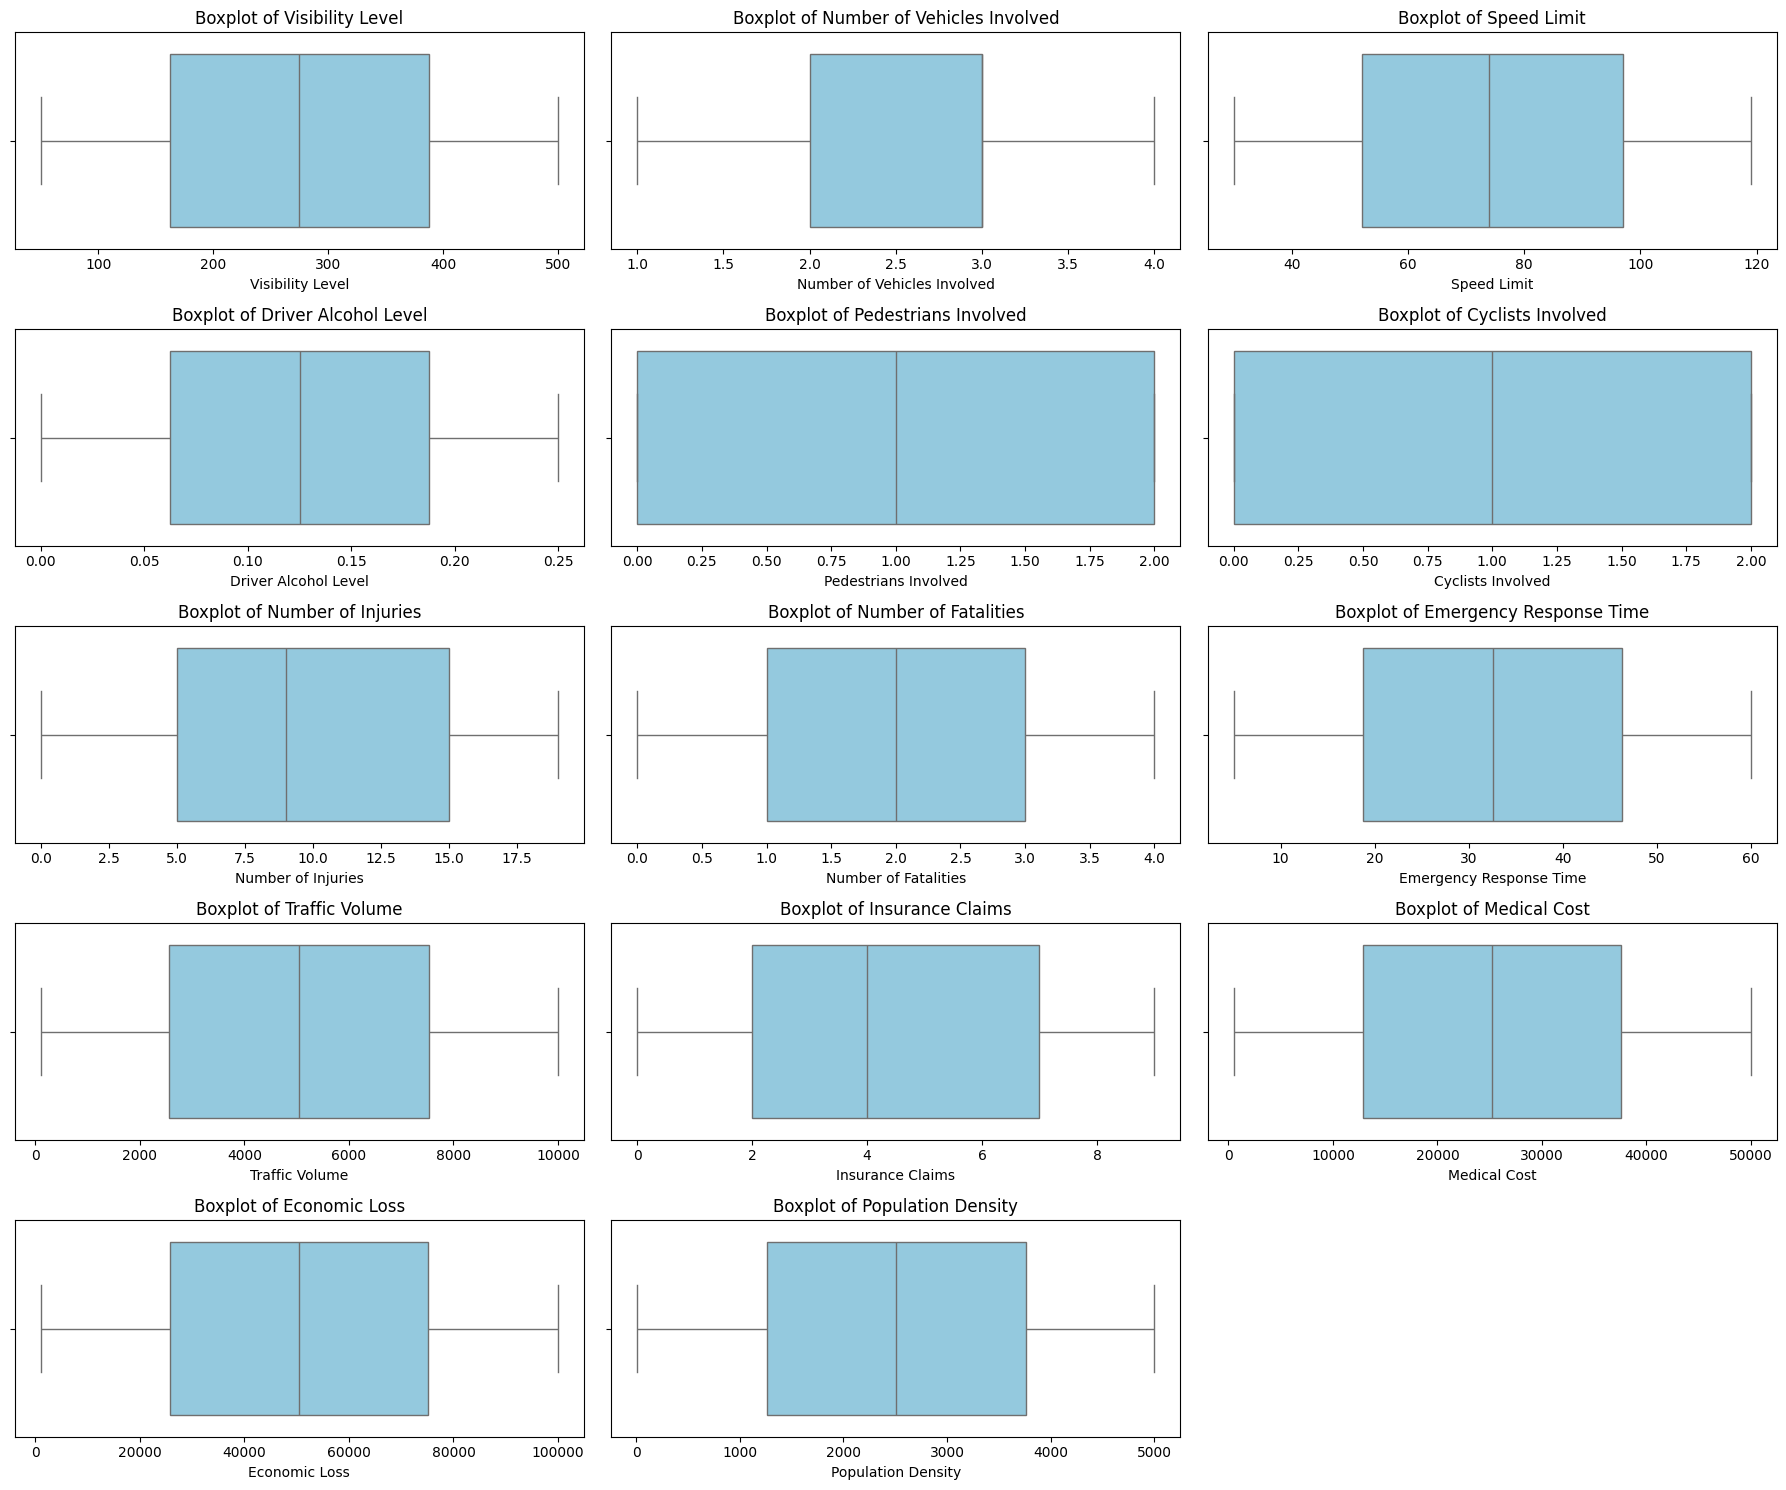

In [11]:
# Outlier Detection: Box plot of Nuemric Variables 

ncols= 3
nrows= len(num_variables)// ncols + (len(num_variables) % ncols > 0)

plt.figure(figsize=(ncols* 6, nrows*3))

for i, j in enumerate(num_variables):
    plt.subplot(nrows, ncols, i+1)
    sns.boxplot(x= data[j], color= 'skyblue')

    plt.title(f"Boxplot of {j}")

plt.tight_layout()
plt.show()

### **2.2 Categorical and Boolean Variables**

In [12]:
# Separate categorical variables
categorical_variables= [i for i in data.columns if data[i].dtype in ['object', 'bool']]
print(categorical_variables)

['Country', 'Year', 'Month', 'Day of Week', 'Time of Day', 'Urban/Rural', 'Road Type', 'Weather Conditions', 'Driver Age Group', 'Driver Gender', 'Driver Fatigue', 'Vehicle Condition', 'Accident Severity', 'Road Condition', 'Accident Cause', 'Region']


In [13]:
# Summary Statistics: Categorical Variables

data[categorical_variables].describe()

,Country,Year,Month,Day of Week,Time of Day,Urban/Rural,Road Type,Weather Conditions,Driver Age Group,Driver Gender,Driver Fatigue,Vehicle Condition,Accident Severity,Road Condition,Accident Cause,Region
count,132000,132000,132000,132000,132000,132000,132000,132000,132000,132000,132000,132000,132000,132000,132000,132000
unique,10,25,12,7,4,2,3,5,5,2,2,3,3,4,5,5
top,Canada,2002,May,Tuesday,Night,Rural,Main Road,Windy,<18,Male,True,Good,Minor,Wet,Drunk Driving,Australia
freq,13349,5433,11158,19061,33231,66502,44197,26626,26524,66098,66076,44094,44063,33356,26506,26625


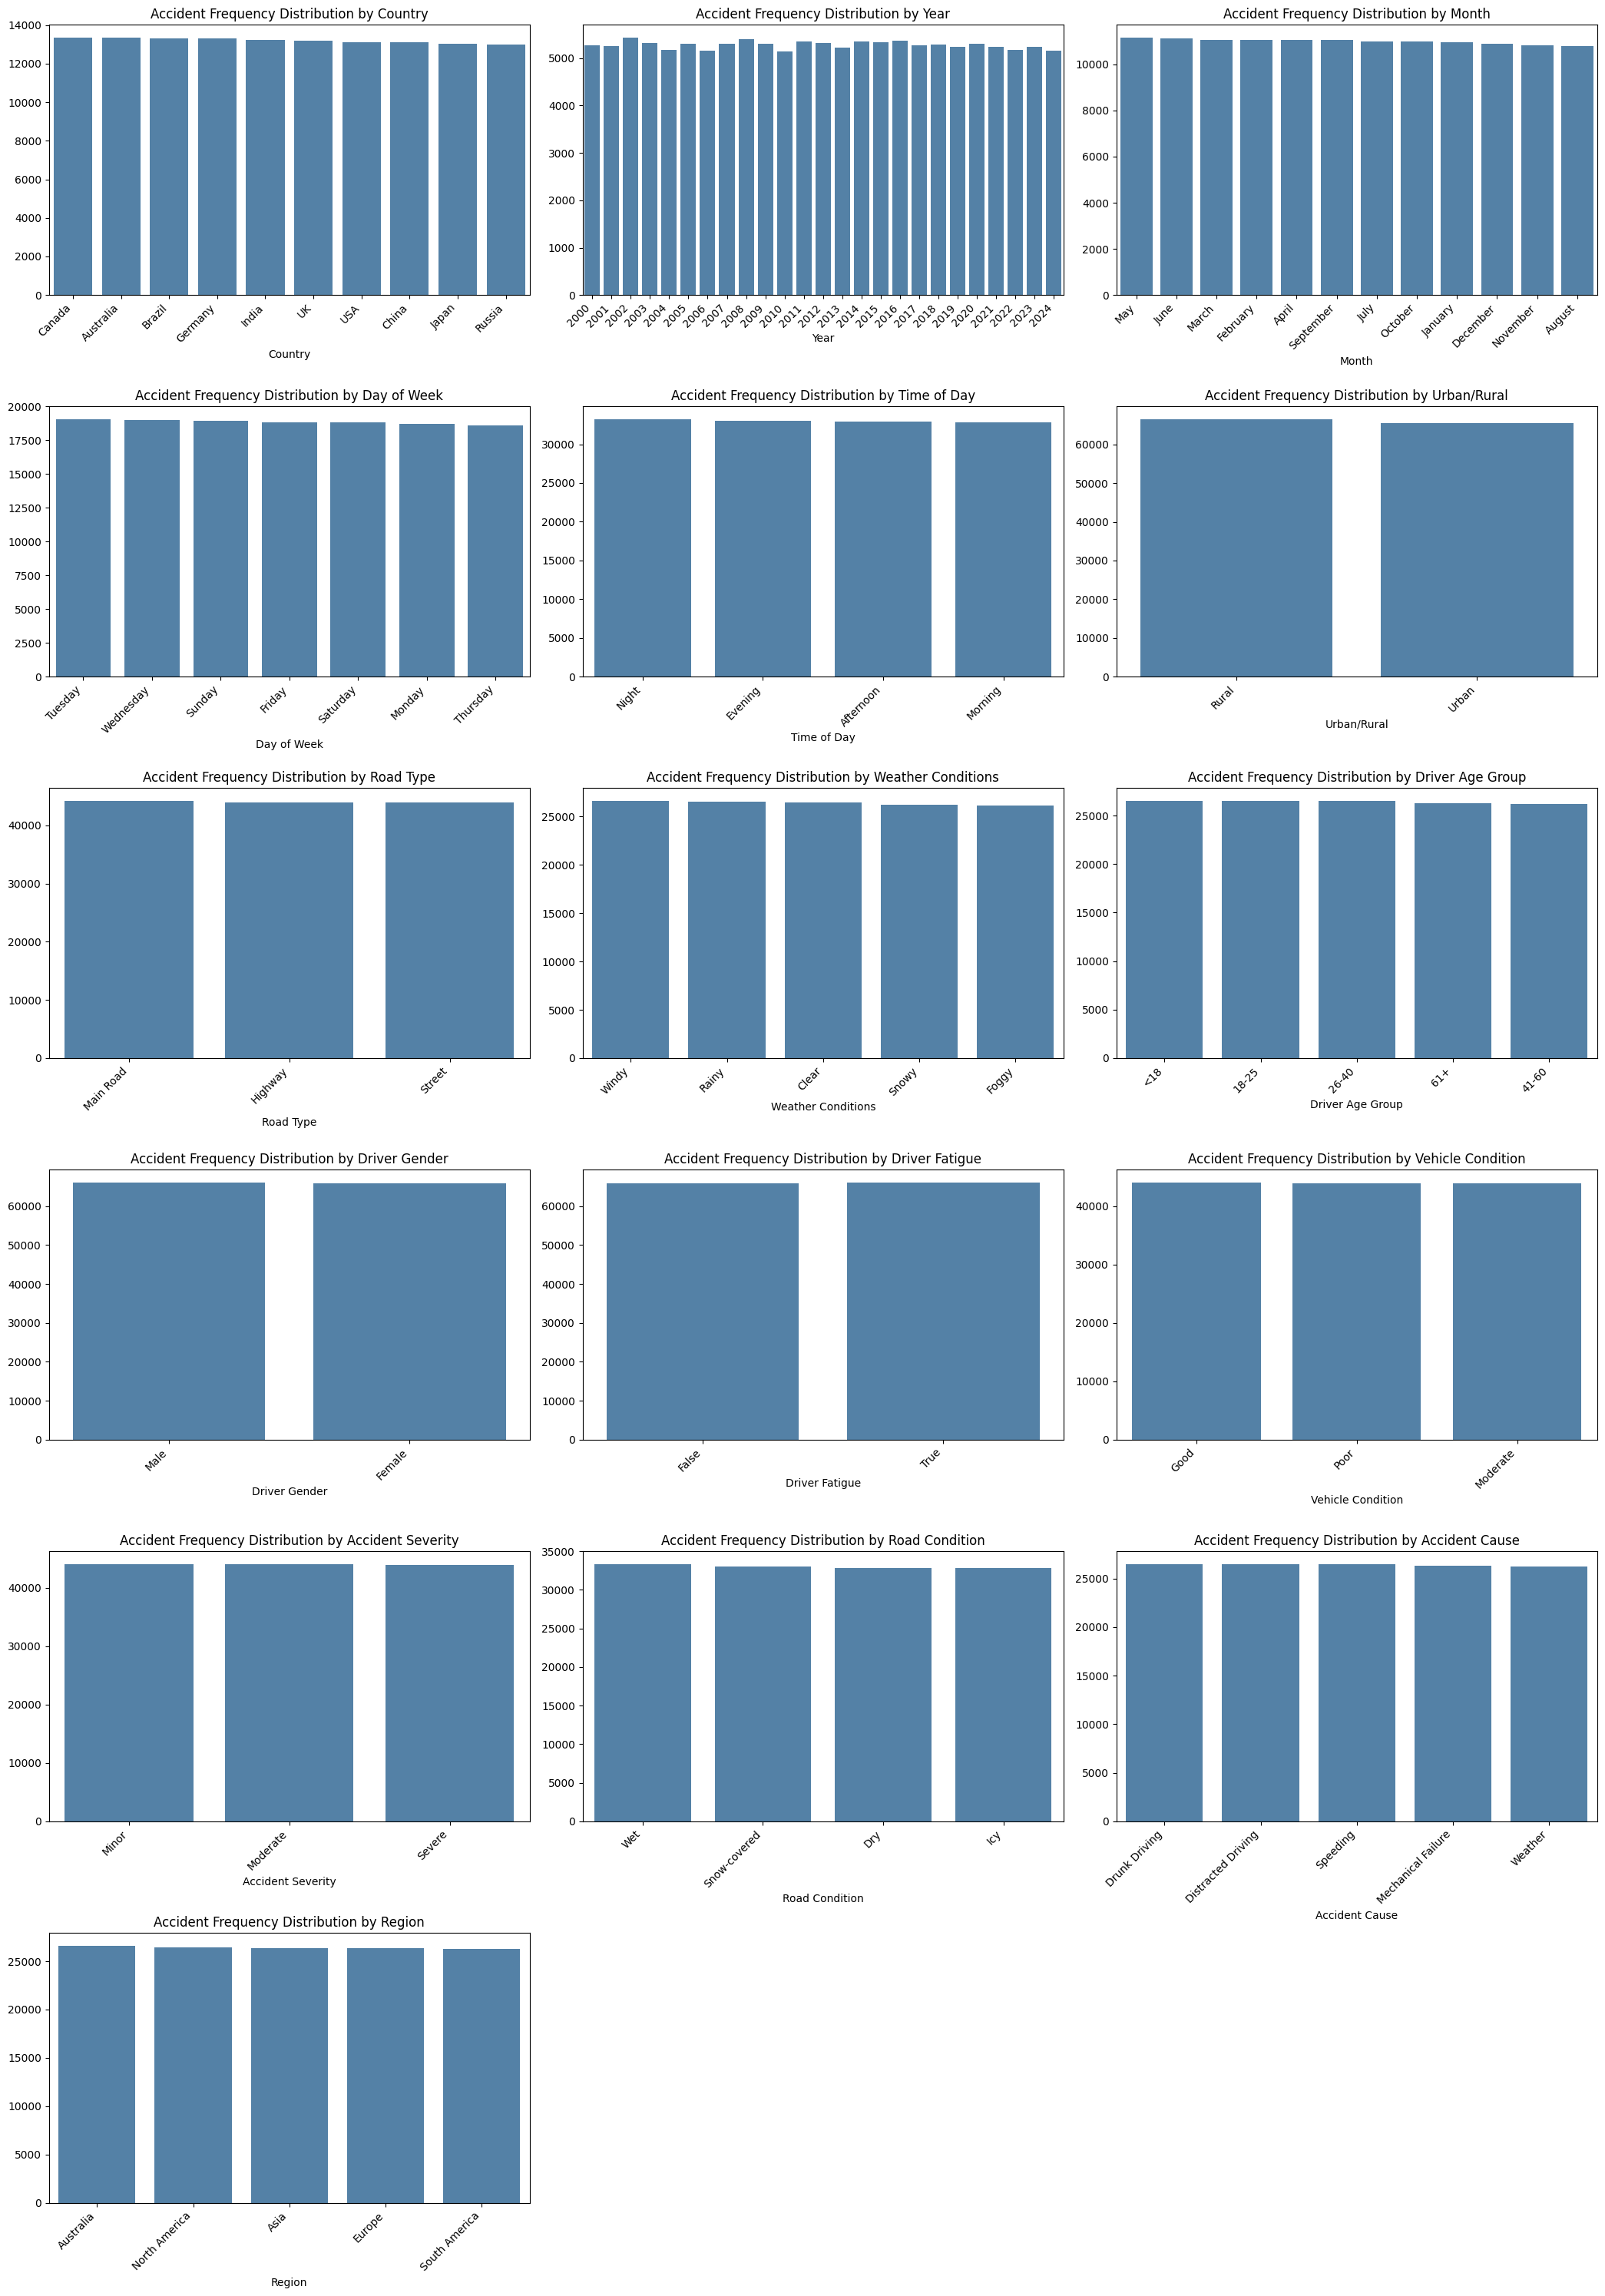

In [14]:
# Frequency Distribution of Accidents: Barplots

ncols = 3
nrows = len(categorical_variables) // ncols + (len(categorical_variables)% ncols > 0)

plt.figure(figsize=(ncols* 7, nrows* 5))

for i, j in enumerate(categorical_variables):
    bar_data = data[j].value_counts()
    
    plt.subplot(nrows, ncols, i+1)
    sns.barplot(x= bar_data.index, y= bar_data.values, color= 'steelblue')
    plt.title(f"Accident Frequency Distribution by {j}")
    plt.xticks(rotation= 45, ha= 'right')

plt.tight_layout()
plt.show()

### **2.3 Correlations**

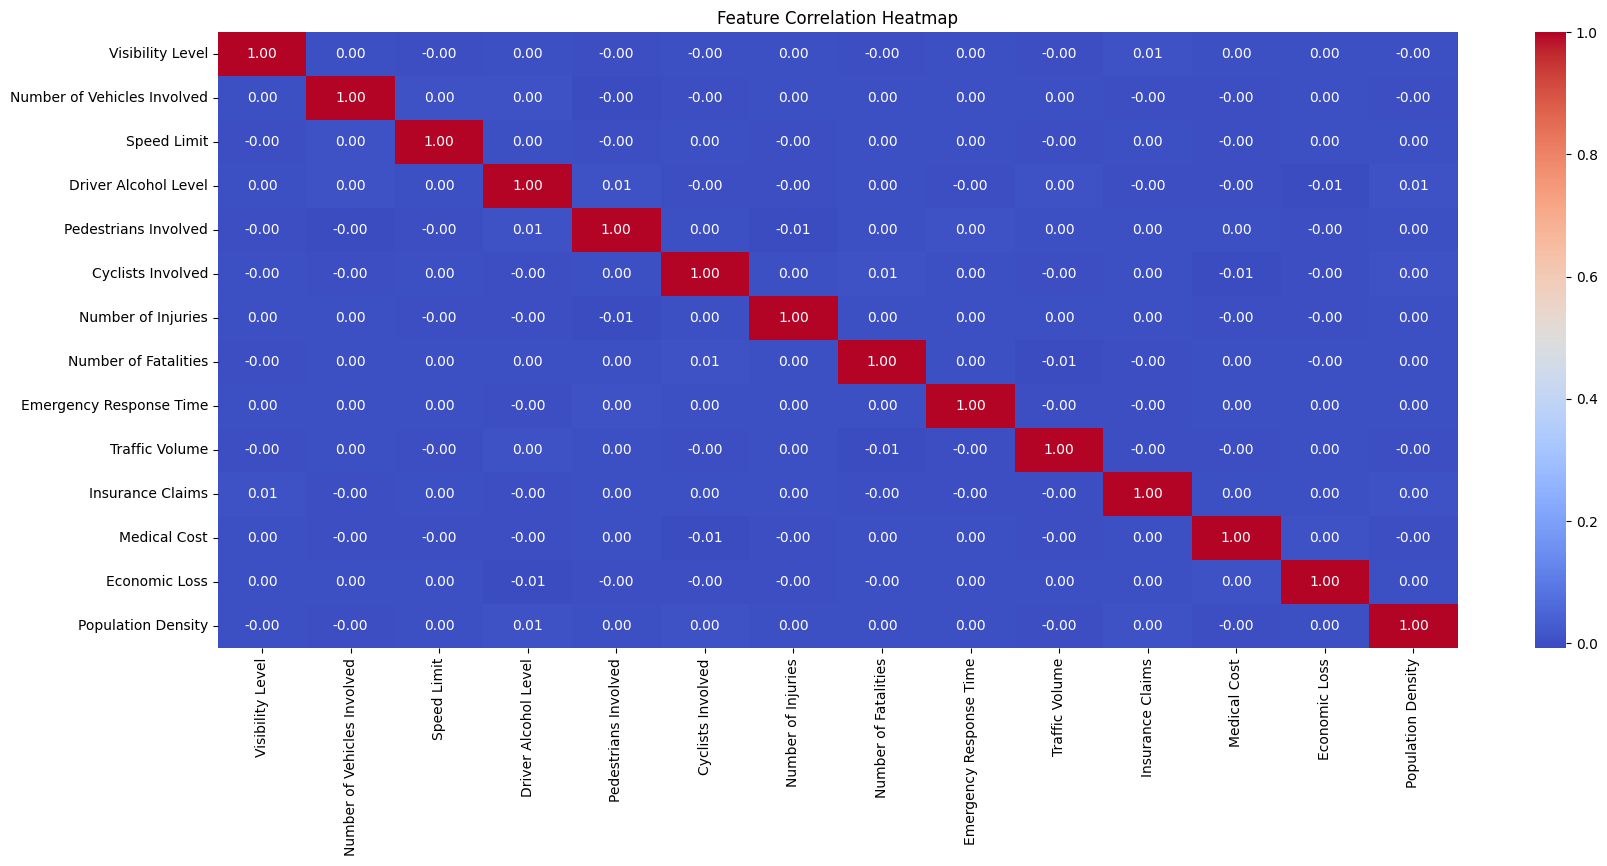

,Visibility Level,Number of Vehicles Involved,Speed Limit,Driver Alcohol Level,Pedestrians Involved,Cyclists Involved,Number of Injuries,Number of Fatalities,Emergency Response Time,Traffic Volume,Insurance Claims,Medical Cost,Economic Loss,Population Density
Visibility Level,1.000000,0.000461,-0.002504,0.002469,-0.003712,-0.000416,0.000960,-0.000637,0.001501,-0.002471,0.005050,0.001066,0.002969,-0.000137
Number of Vehicles Involved,0.000461,1.000000,0.003759,0.003767,-0.004993,-0.001884,0.002234,0.003353,0.001926,0.003168,-0.003621,-0.001092,0.000377,-0.004312
Speed Limit,-0.002504,0.003759,1.000000,0.000760,-0.001365,0.001922,-0.001118,0.000621,0.000189,-0.001970,0.000065,-0.001014,0.000349,0.001393
Driver Alcohol Level,0.002469,0.003767,0.000760,1.000000,0.005053,-0.000792,-0.001200,0.002115,-0.001453,0.003478,-0.004082,-0.001981,-0.005284,0.005116
Pedestrians Involved,-0.003712,-0.004993,-0.001365,0.005053,1.000000,0.002873,-0.008377,0.003346,0.004827,0.001052,0.001225,0.001900,-0.000812,0.000973
Cyclists Involved,-0.000416,-0.001884,0.001922,-0.000792,0.002873,1.000000,0.000406,0.005160,0.000356,-0.001033,0.000451,-0.005207,-0.002288,0.003785
Number of Injuries,0.000960,0.002234,-0.001118,-0.001200,-0.008377,0.000406,1.000000,0.000389,0.000222,0.000243,0.003242,-0.003123,-0.001570,0.002038
Number of Fatalities,-0.000637,0.003353,0.000621,0.002115,0.003346,0.005160,0.000389,1.000000,0.003322,-0.005178,-0.003330,0.001990,-0.000185,0.003267
Emergency Response Time,0.001501,0.001926,0.000189,-0.001453,0.004827,0.000356,0.000222,0.003322,1.000000,-0.001661,-0.003526,0.000392,0.000357,0.001627
Traffic Volume,-0.002471,0.003168,-0.001970,0.003478,0.001052,-0.001033,0.000243,-0.005178,-0.001661,1.000000,-0.001543,-0.001800,0.001227,-0.001889


In [15]:
# Correlation between Numeric Variables
corr_matrix = data[num_variables].corr()

plt.figure(figsize=(20, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

corr_matrix

## **3. Key Metrics**

In [16]:
# Period of the dataset

min_date = data['Date'].min()
max_date = data['Date'].max()

print(f"The dataset contains accident events from {min_date.strftime('%B')}, {min_date.year} to {max_date.strftime('%B')}, {max_date.year}.")

The dataset contains accident events from January, 2000 to December, 2024.


### **3.1 Accident Frequency**

In [17]:
# Total number of accidents:
total_accidents = len(data)
print(f"Total Number of Accidents reported in the dataset is {total_accidents}")

Total Number of Accidents reported in the dataset is 132000


### **3.2 Severity Matric**

In [18]:
# Total fatalities
total_fatalities = data['Number of Fatalities'].sum()
print(f"Total fatalities occured: {total_fatalities}")

# Total injuries
total_injuries = data['Number of Injuries'].sum()
print(f"Total injuries occured: {total_injuries}")

# Fatalities per accident
fatality_rate= total_fatalities / total_accidents
print(f"Fatalities per accident (Fatality Rate): {fatality_rate: .2f}")

# Injuries per accident
injury_rate= total_injuries / total_accidents 
print(f"Injuries per accident: {injury_rate: .2f}")

# NUmber of Vehicles involved
total_vehicle_involved= data['Number of Vehicles Involved'].sum()
print(f"Total number of vehicle involved: {total_vehicle_involved}")

# Averahe number of Vehicles involved
avg_vehicle_involved= data['Number of Vehicles Involved'].mean()
print(f"Number of vehicle involved per Accident: {avg_vehicle_involved: .2f}")

Total fatalities occured: 263398
Total injuries occured: 1255083
Fatalities per accident (Fatality Rate):  2.00
Injuries per accident:  9.51
Total number of vehicle involved: 330162
Number of vehicle involved per Accident:  2.50


In [19]:
# Emergency Stats
avg_emergency_response_time = data['Emergency Response Time'].mean()
print(f'The average emergency response time was {avg_emergency_response_time: .2f} minutes.')

The average emergency response time was  32.49 minutes.


### **3.3 Economic Impact**

In [20]:
# Total Medical Cost of Accidents
total_medical_cost = data['Medical Cost'].sum()
print(f"Total Medical Cost: {total_medical_cost:,.2f}")

# Average Medical Cost of Accidents
avg_medical_cost = data['Medical Cost'].mean()
print(f"Average Medical Cost per Accident: {avg_medical_cost:,.2f}")

# Total Economic Loss due to accidents
total_economic_loss = data['Economic Loss'].sum()
print(f"Total Economic Loss: {total_economic_loss:,.2f}")

# Average Medical Loss due to accidents
avg_economic_loss = data['Economic Loss'].mean()
print(f"Average Economic Loss per Accident: {avg_economic_loss:,.2f}")

Total Medical Cost: 3,326,196,046.90
Average Medical Cost per Accident: 25,198.45
Total Economic Loss: 6,657,750,741.18
Average Economic Loss per Accident: 50,437.51


## **3. Temporal Analysis**

- **Temporal variables** - `Year`, `Month`, `Day of the Week`, and `Time of the Day`
- **Impact Metrics** - `Medical Cost`, `Economic Loss`, `Number of Injuries`, and `Number of Fatalities`.

### **3.1 Accident Count Over Time**

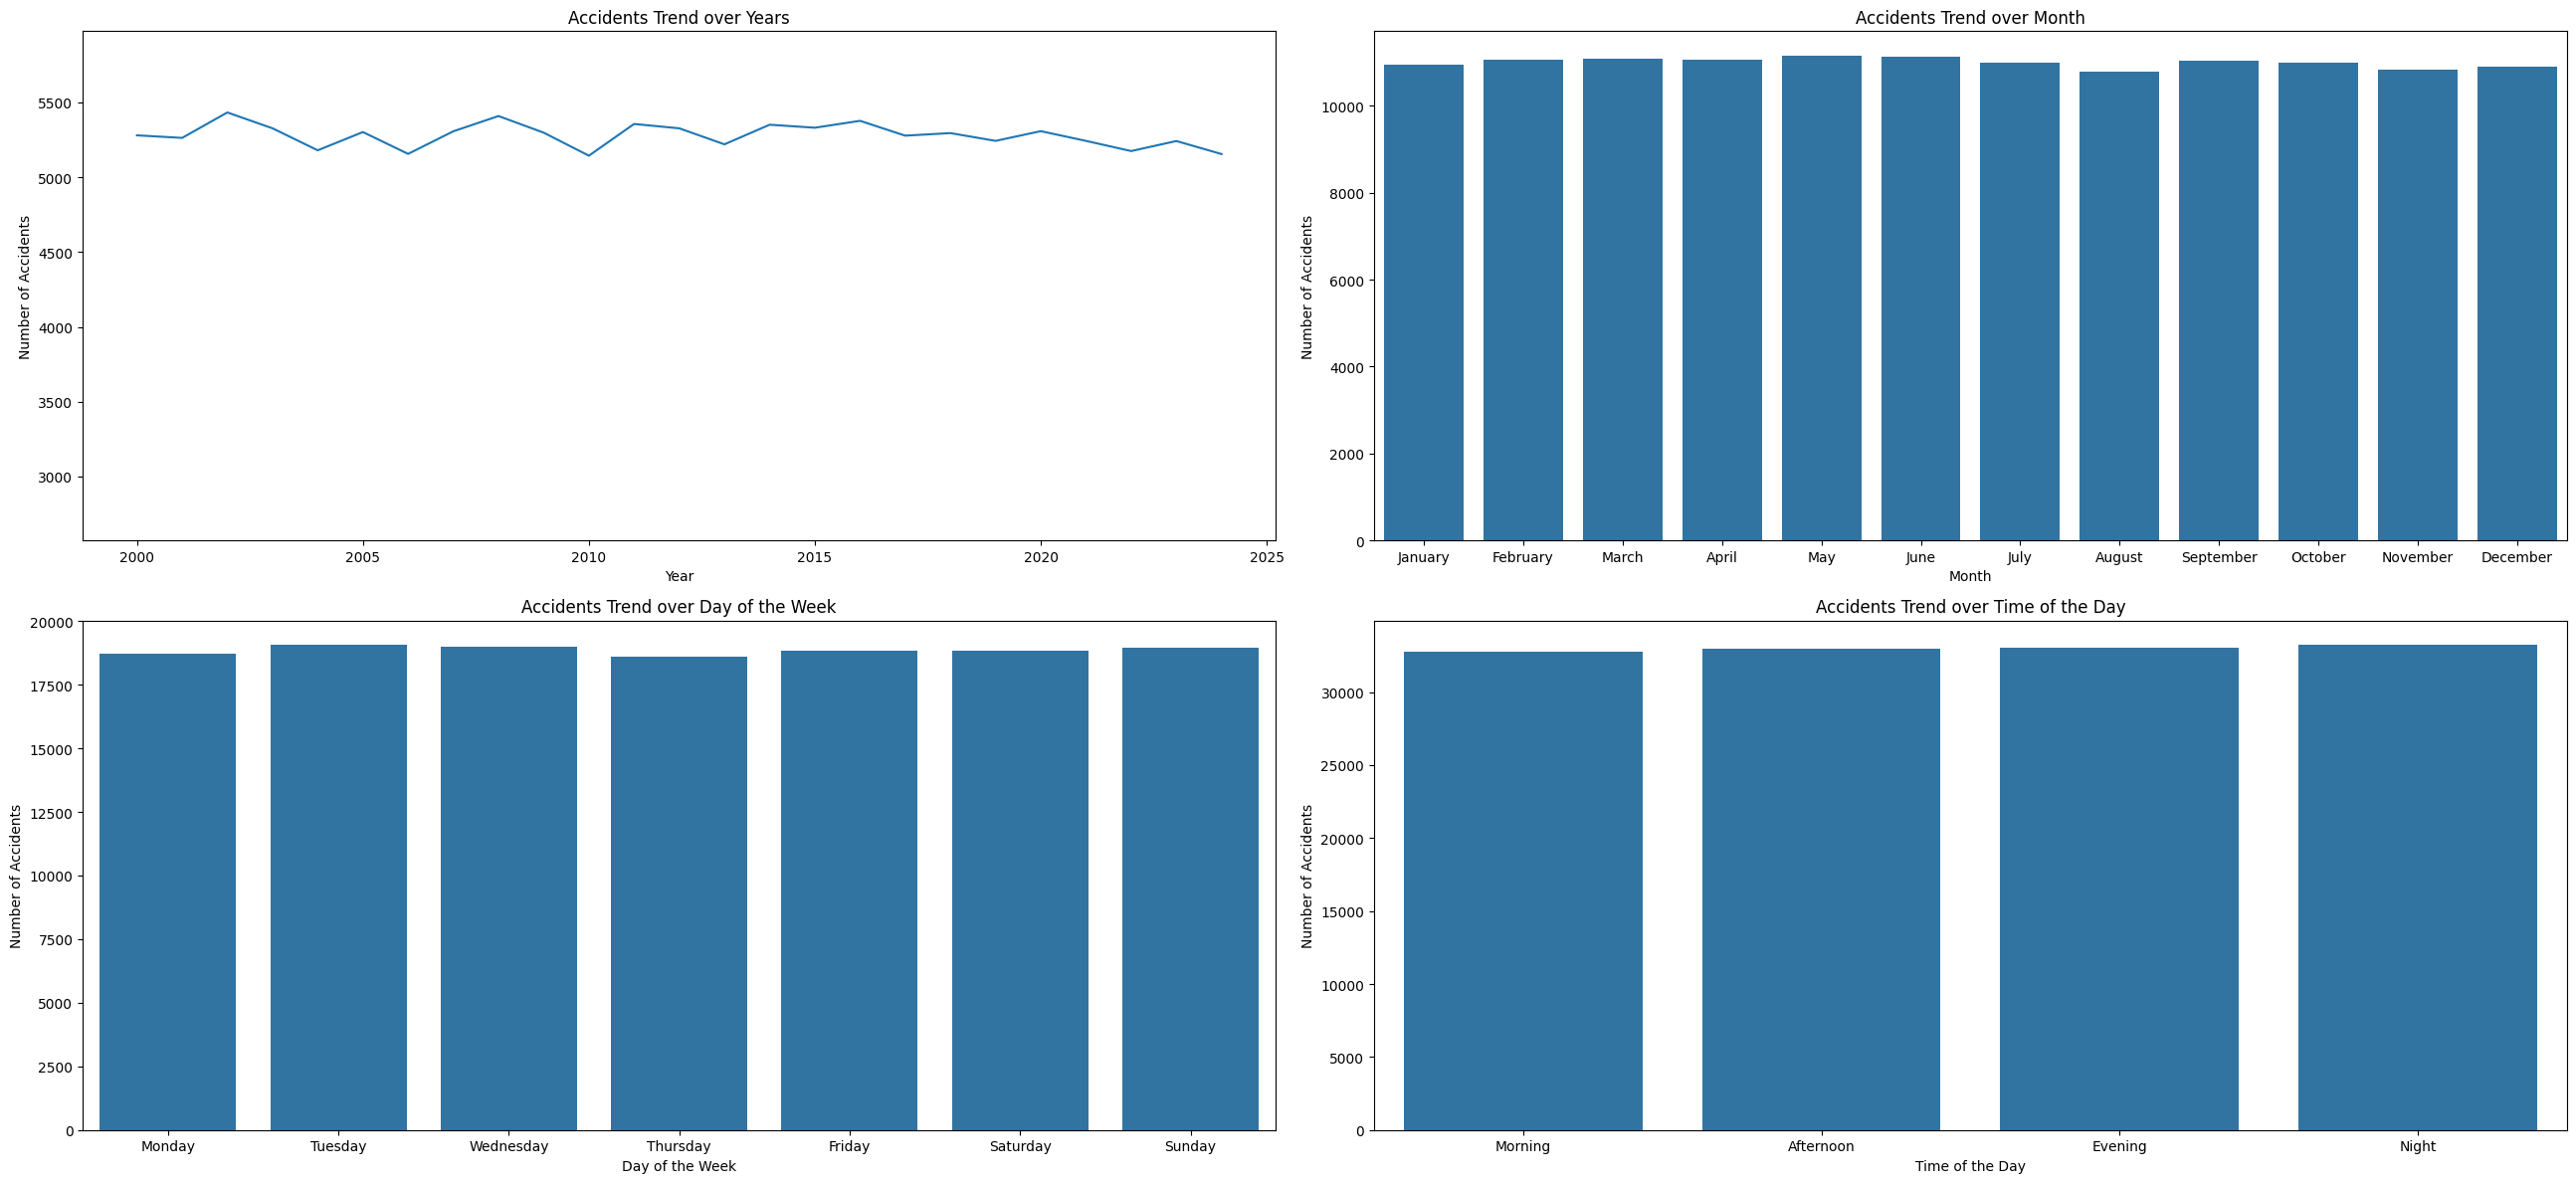

In [21]:
## Accident Trends Over Temporal Variables

accidents_by_year = data['Year'].value_counts().reset_index()
accidents_by_month = data['Month'].value_counts().reset_index()
accidents_by_dayofweek = data['Day of Week'].value_counts().reset_index()
accidents_by_timeofday = data['Time of Day'].value_counts().reset_index()

# For ordering
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
time_order = ["Morning", "Afternoon", "Evening", "Night"]

# Plots
plt.figure(figsize=(26, 12))

# 1. Total Accidents Per Years
plt.subplot(2, 2, 1)
sns.lineplot(data= accidents_by_year, x= 'Year', y= 'count')
plt.title("Accidents Trend over Years")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.ylim(accidents_by_year['count'].min()*0.5, accidents_by_year['count'].max()*1.1)

# 2. Total Accidents Per Month
plt.subplot(2, 2, 2)
sns.barplot(data= accidents_by_month, x= 'Month', y= 'count', order= month_order)
plt.title("Accidents Trend over Month")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")

# 3. Total Accidents Per Day of the Week
plt.subplot(2, 2, 3)
sns.barplot(data= accidents_by_dayofweek, x= 'Day of Week', y= 'count', order= day_order)
plt.title("Accidents Trend over Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Accidents")

# 4. Total Accidents Per Time of the Day
plt.subplot(2, 2, 4)
sns.barplot(data= accidents_by_timeofday, x= 'Time of Day', y= 'count', order= time_order)
plt.title("Accidents Trend over Time of the Day")
plt.xlabel("Time of the Day")
plt.ylabel("Number of Accidents")

plt.tight_layout()
plt.show()

### **3.2 Impact Metrics By Year**

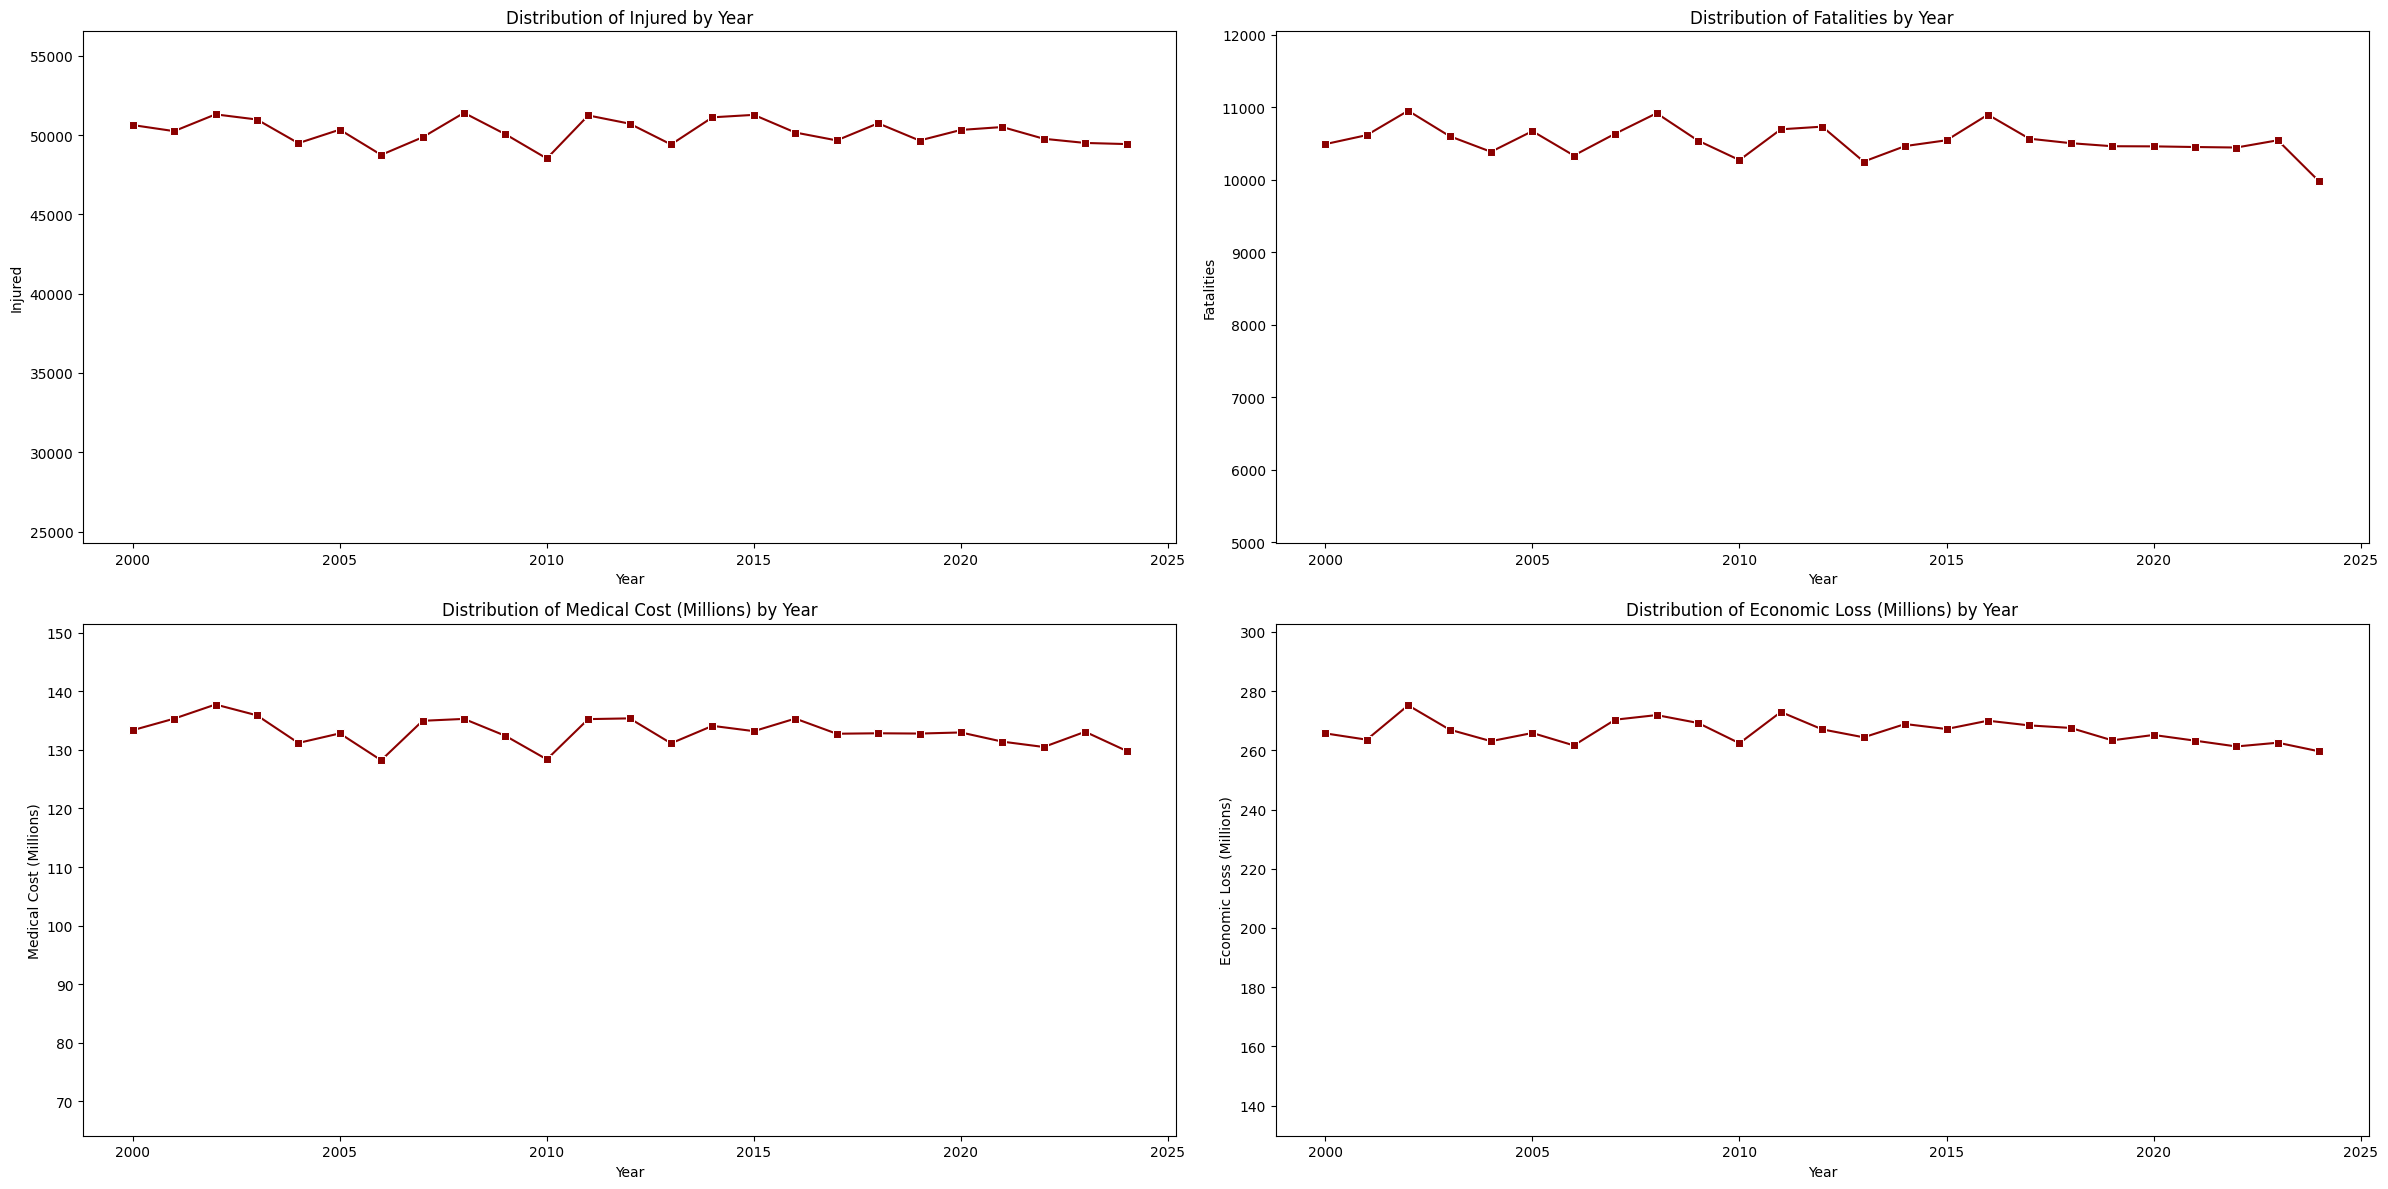

In [22]:
# Aggregate impact features by year
yearly_impact = data.groupby('Year').agg(injured = ('Number of Injuries', 'sum'),
                                         fatalities = ('Number of Fatalities', 'sum'),
                                         medical_cost = ("Medical Cost", 'sum'),
                                         economic_loss = ("Economic Loss", 'sum')).reset_index()

# Convert cost values to millions for better scaling
yearly_impact['Medical Cost (Millions)'] = yearly_impact['medical_cost'] / 1_000_000
yearly_impact['Economic Loss (Millions)'] = yearly_impact['economic_loss'] / 1_000_000

# Plots
plot_columns = ['injured', 'fatalities', 'Medical Cost (Millions)', 'Economic Loss (Millions)']

nrows, ncols = 2, 2
plt.figure(figsize= (nrows * 12, ncols* 6))

for i, j in enumerate(plot_columns):
    plt.subplot(nrows, ncols, i + 1)
    sns.lineplot(x=yearly_impact['Year'], y=yearly_impact[j], color='darkred', marker= 's')
        
    plt.title(f"Distribution of {j.replace('_', ' ').title()} by Year")
    plt.xlabel("Year")
    plt.ylabel(f"{j.replace("_", " ").title()}")
    plt.ylim(yearly_impact[j].min()* 0.5, yearly_impact[j].max()* 1.1)

plt.tight_layout()
plt.show()

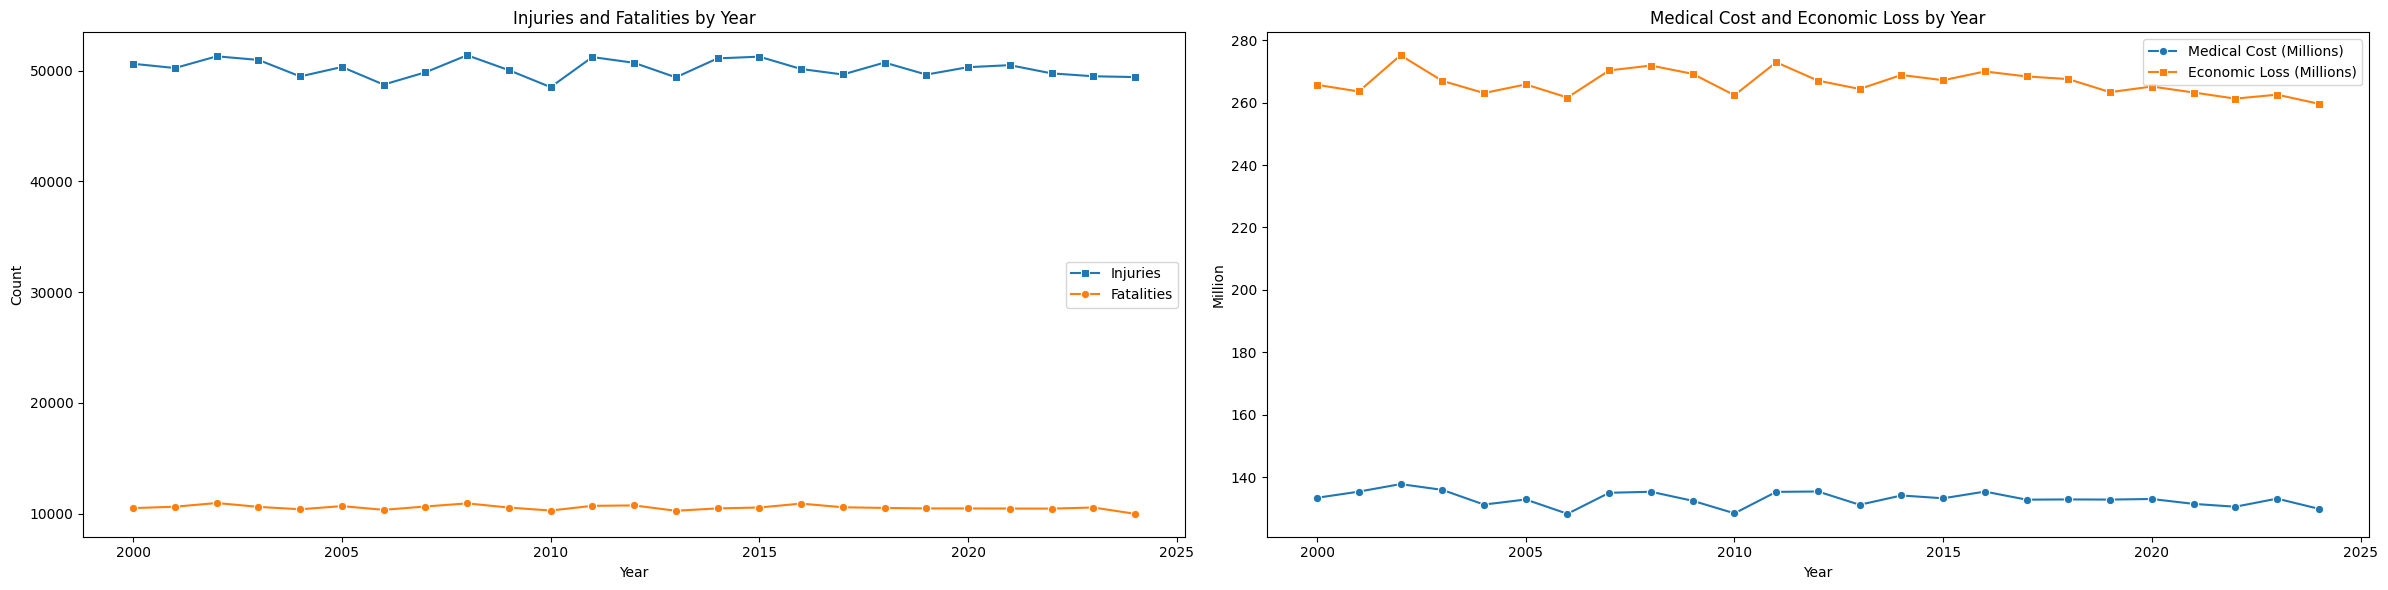

In [23]:
# Comparison
plt.figure(figsize= (24, 6))

# Injuries Vs Fatalities
plt.subplot(1, 2, 1)
sns.lineplot(x= yearly_impact['Year'], y= yearly_impact['injured'],label="Injuries", marker="s")
sns.lineplot(x= yearly_impact['Year'], y= yearly_impact['fatalities'], label="Fatalities", marker="o")
plt.title("Injuries and Fatalities by Year")
plt.xlabel("Year")
plt.ylabel("Count")

# Medical Cost Vs Economic Loss
plt.subplot(1, 2, 2)
sns.lineplot(data=yearly_impact, x= 'Year', y= 'Medical Cost (Millions)', label="Medical Cost (Millions)", marker="o")
sns.lineplot(data=yearly_impact, x= 'Year', y= 'Economic Loss (Millions)', label="Economic Loss (Millions)", marker="s")
plt.title("Medical Cost and Economic Loss by Year")
plt.xlabel("Year")
plt.ylabel("Million")

plt.tight_layout()
plt.show()

### **3.3 Impact Metrics By Month**

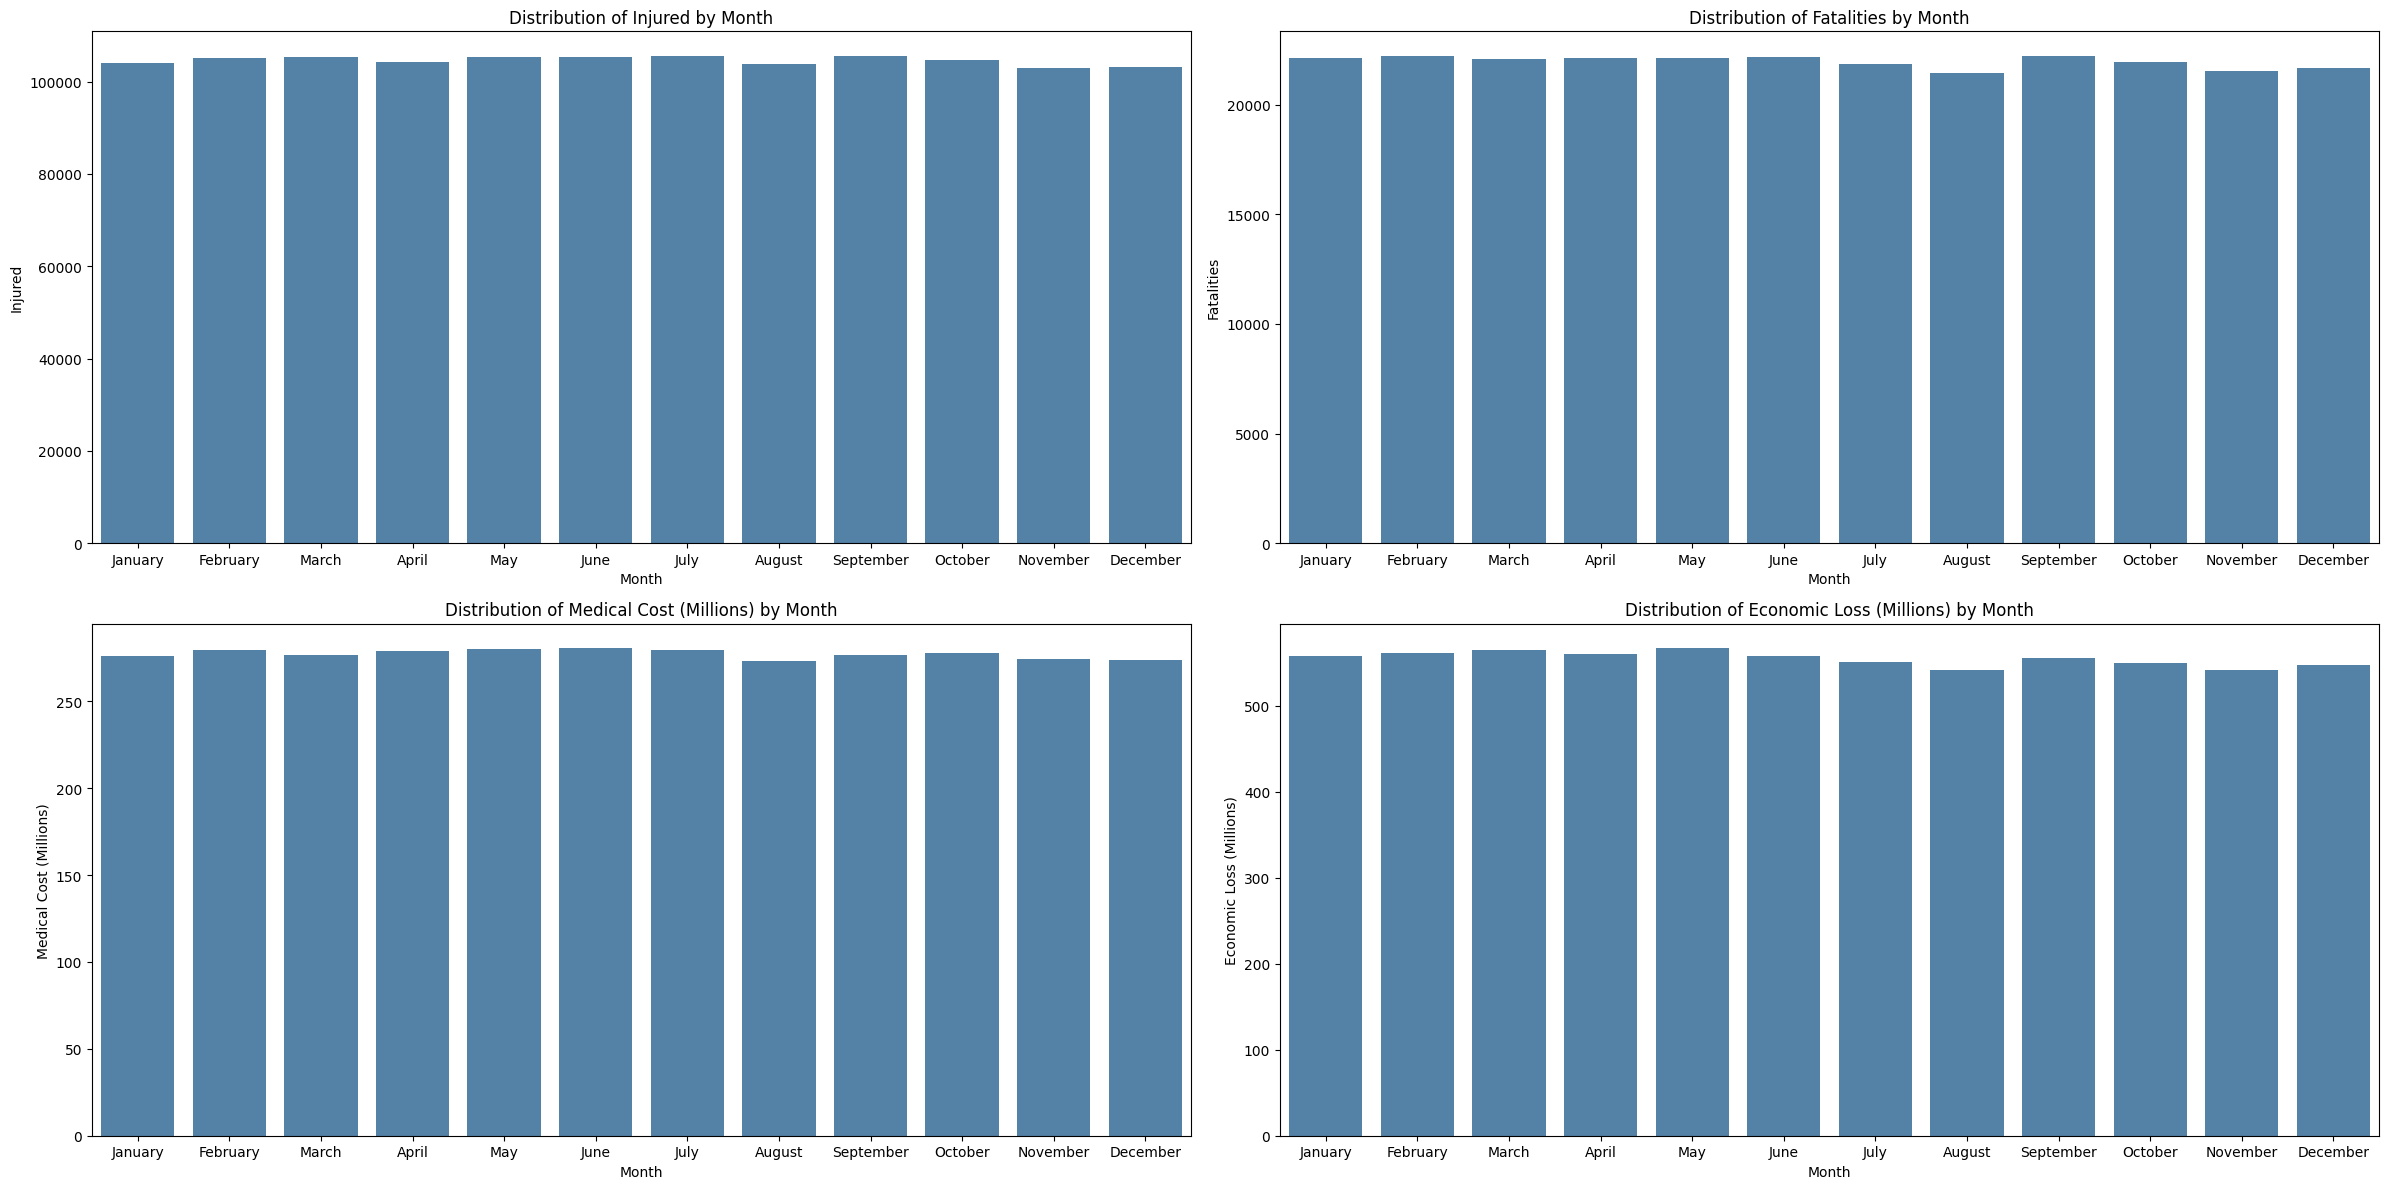

In [24]:
# Aggregate impact variables by Month
monthly_impact = data.groupby(['Month']).agg(injured = ("Number of Injuries", "sum"), 
                                             fatalities = ("Number of Fatalities", "sum"),
                                             medical_cost = ("Medical Cost", "sum"), 
                                             economic_loss = ("Economic Loss", "sum")).reset_index()

# Convert large values into millions for better context
monthly_impact['Medical Cost (Millions)']= monthly_impact['medical_cost'] / 1_000_000
monthly_impact['Economic Loss (Millions)'] = monthly_impact['economic_loss']/ 1_000_000

# Plots
plot_columns = ['injured', 'fatalities', 'Medical Cost (Millions)', 'Economic Loss (Millions)']

# Ordeing Months
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
monthly_impact['Month'] = pd.Categorical(monthly_impact['Month'], categories= month_order, ordered=True)
monthly_impact= monthly_impact.sort_values(by="Month").reset_index(drop=True)

# Plot
nrows, ncols = 2, 2
plt.figure(figsize= (nrows * 12, ncols* 6))

for i, j in enumerate(plot_columns):
    plt.subplot(nrows, ncols, i + 1)
    sns.barplot(x=monthly_impact['Month'],  y=monthly_impact[j], color='steelblue')
    
    plt.title(f"Distribution of {j.replace('_', ' ').title()} by Month")
    plt.xlabel("Month")
    plt.ylabel(f"{j.replace("_", " ").title()}")

plt.tight_layout()
plt.show()

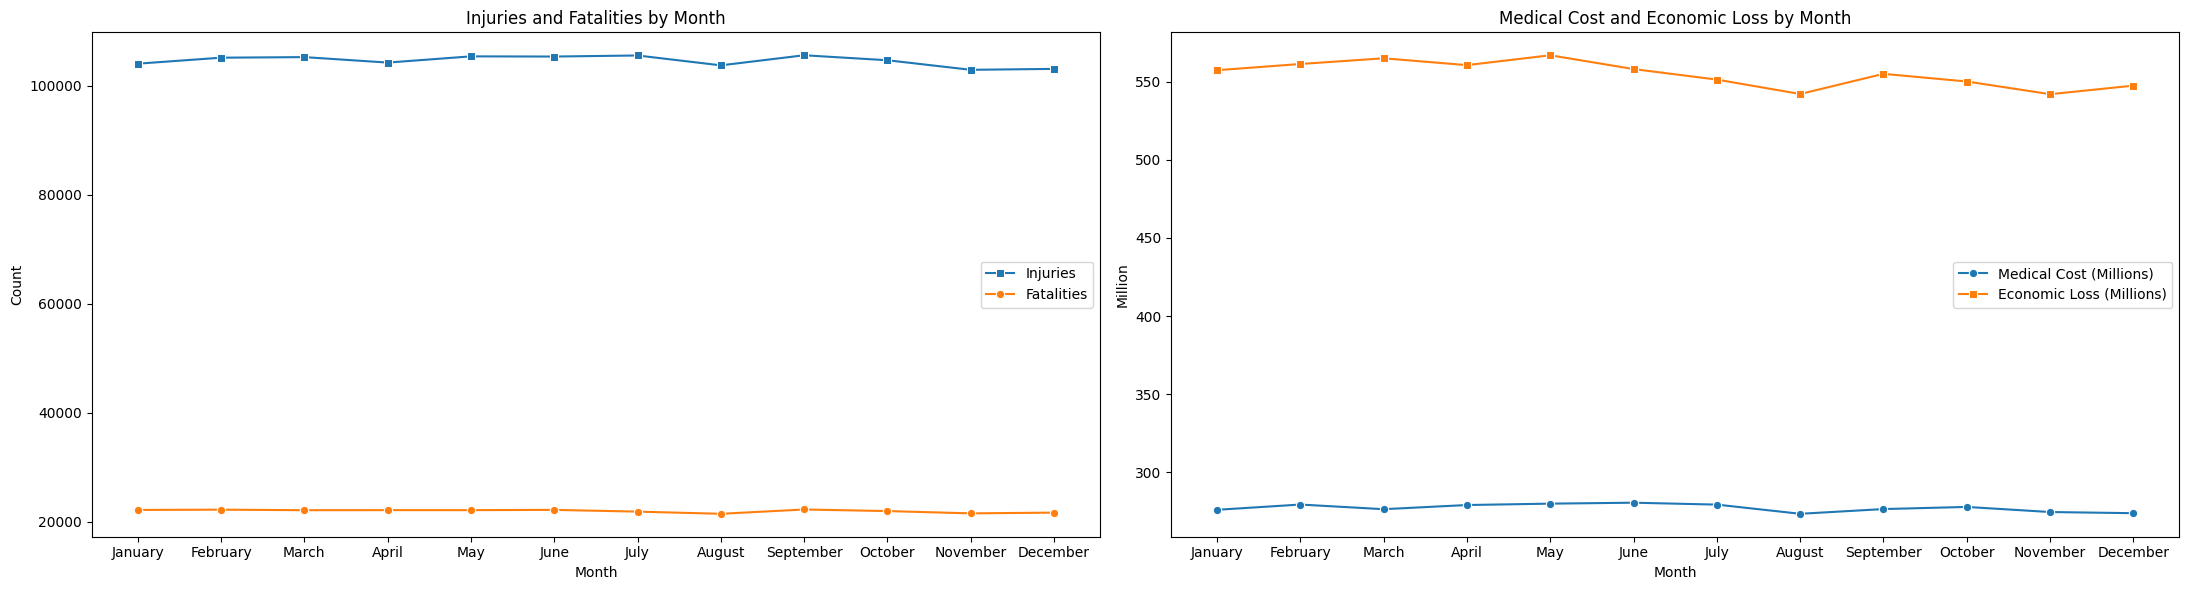

In [25]:
# Comparision
plt.figure(figsize= (22, 6))

# Injuries Vs Fatalities
plt.subplot(1, 2, 1)
sns.lineplot(x= monthly_impact['Month'], y= monthly_impact['injured'],label="Injuries", marker="s")
sns.lineplot(x= monthly_impact['Month'], y= monthly_impact['fatalities'], label="Fatalities", marker="o")
plt.title("Injuries and Fatalities by Month")
plt.xlabel("Month")
plt.ylabel("Count")

# Medical Cost and Economic Loss (Millions)
plt.subplot(1, 2, 2)
sns.lineplot(data=monthly_impact, x= 'Month', y= 'Medical Cost (Millions)', label="Medical Cost (Millions)", marker="o")
sns.lineplot(data=monthly_impact, x= 'Month', y= 'Economic Loss (Millions)', label="Economic Loss (Millions)", marker="s")
plt.title("Medical Cost and Economic Loss by Month")
plt.xlabel("Month")
plt.ylabel("Million")

plt.legend()
plt.tight_layout()
plt.show()

#### **3.3.1: Monthly Trends in Accident Impact: Injuries, Fatalities, and Economic Losses** 

In [26]:
# Group data
monthly_impact_timeline = data.groupby(['Year','Month']).agg(injured = ("Number of Injuries", "sum"), 
                                                             fatalities = ("Number of Fatalities", "sum"),
                                                             medical_cost = ("Medical Cost", "sum"), 
                                                             economic_loss = ("Economic Loss", "sum")).reset_index()

# Convert large values into millions for better context
monthly_impact_timeline['Medical Cost (Millions)']= monthly_impact_timeline['medical_cost'] / 1_000_000
monthly_impact_timeline['Economic Loss (Millions)'] = monthly_impact_timeline['economic_loss']/ 1_000_000

# Month order for clarity
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
monthly_impact_timeline['Month'] = pd.Categorical(monthly_impact_timeline['Month'], categories=month_order, ordered=True)
monthly_impact_timeline = monthly_impact_timeline.sort_values(by=["Year", "Month"]).reset_index(drop=True)

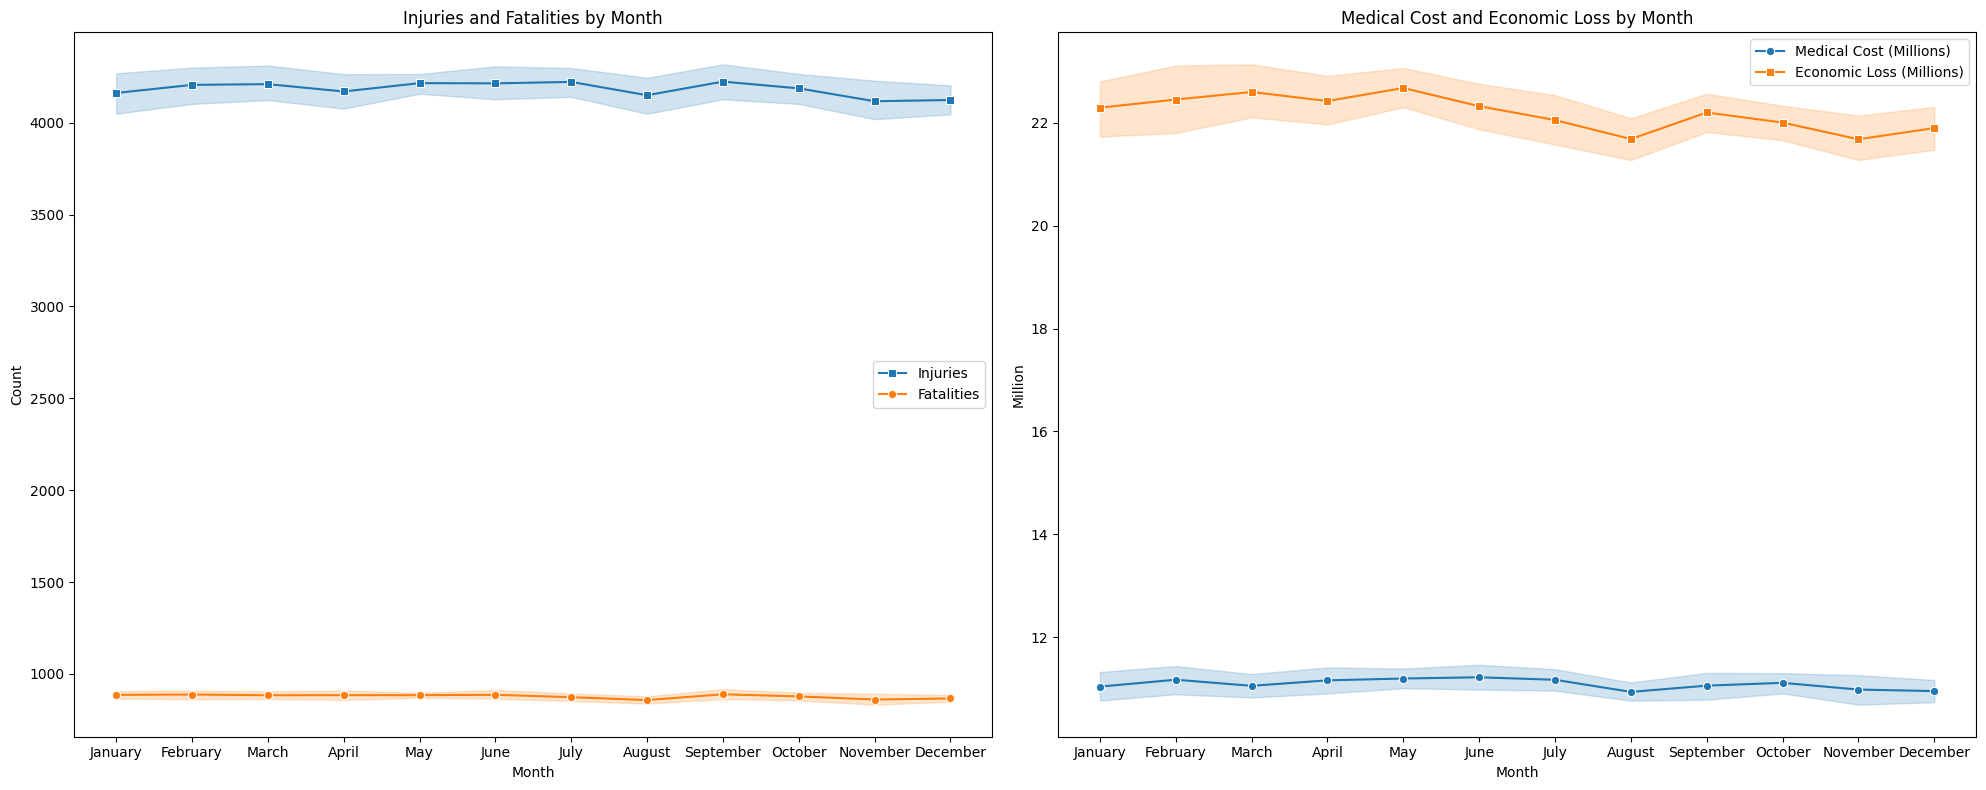

In [27]:
# Impact Variables by Month and their variance

plt.figure(figsize= (20, 8))

# 1. Injured Vs Fatalities
plt.subplot(1, 2, 1)
sns.lineplot(x= monthly_impact_timeline['Month'], y= monthly_impact_timeline['injured'],label="Injuries", marker="s")
sns.lineplot(x= monthly_impact_timeline['Month'], y= monthly_impact_timeline['fatalities'], label="Fatalities", marker="o")
plt.title("Injuries and Fatalities by Month")
plt.xlabel("Month")
plt.ylabel("Count")

# Medical Cost Vs Economic Loss in Millions
plt.subplot(1, 2, 2)
sns.lineplot(data=monthly_impact_timeline, x= 'Month', y= 'Medical Cost (Millions)', label="Medical Cost (Millions)", marker="o")
sns.lineplot(data=monthly_impact_timeline, x= 'Month', y= 'Economic Loss (Millions)', label="Economic Loss (Millions)", marker="s")
plt.title("Medical Cost and Economic Loss by Month")
plt.xlabel("Month")
plt.ylabel("Million")

plt.legend()
plt.tight_layout()
plt.show()

### **3.4 Impact Metrics by Month and Year Date**

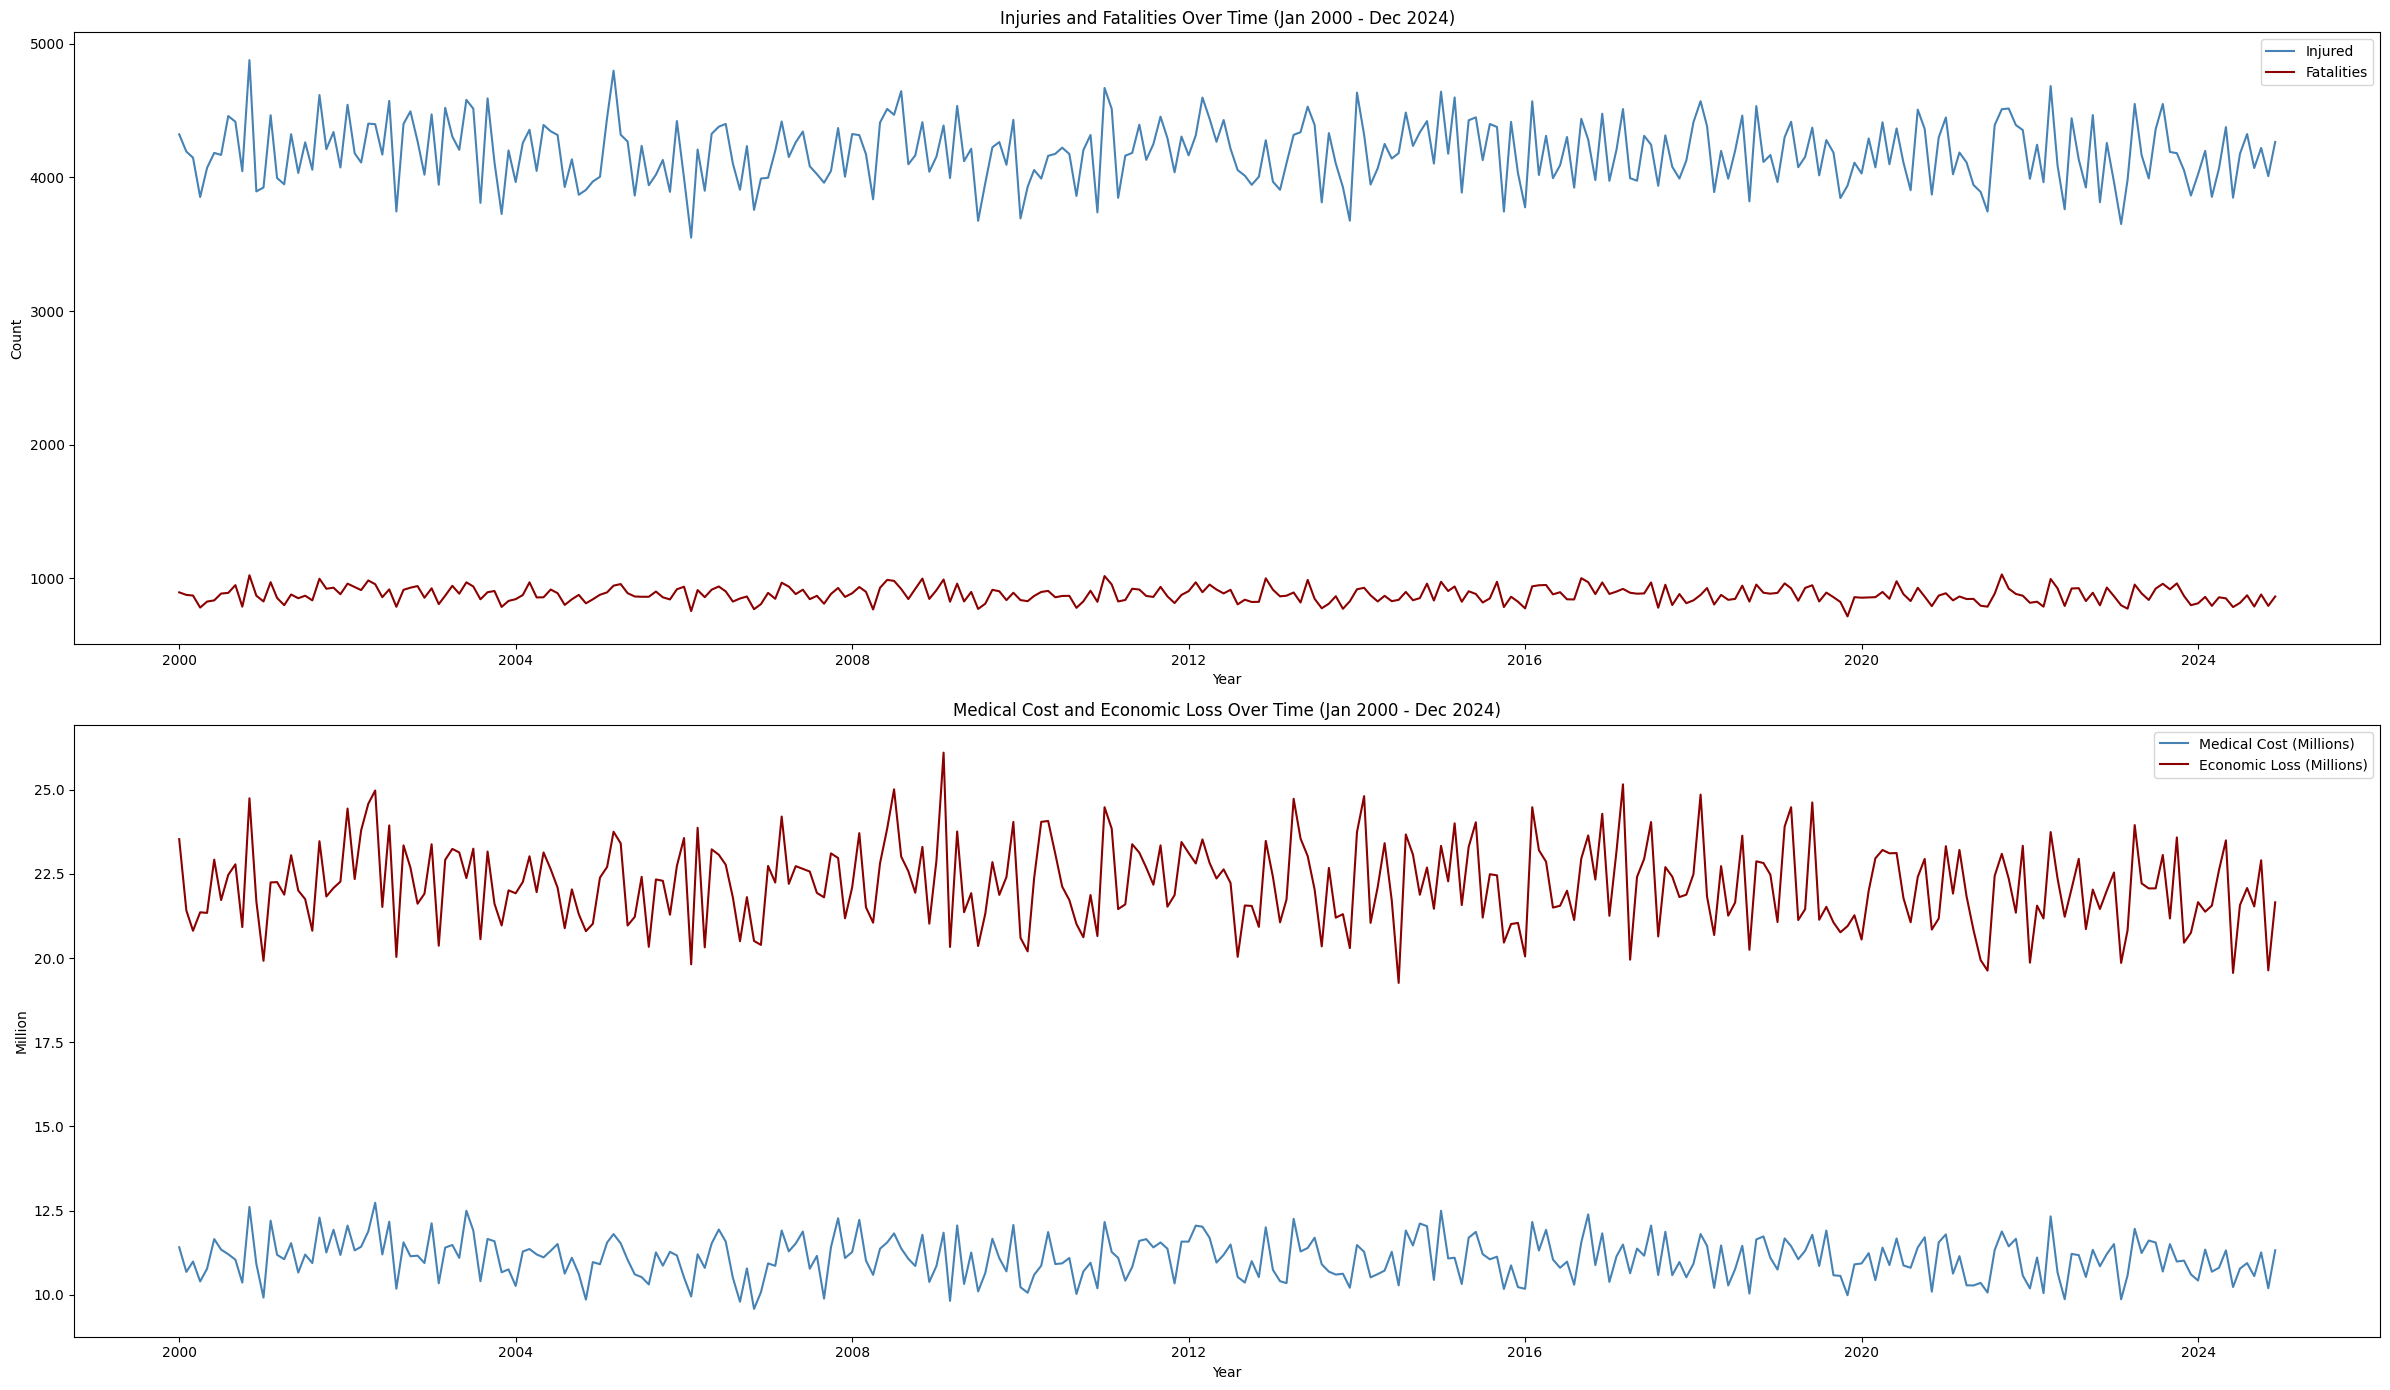

In [28]:
# Timeline of the Injuries and Fatlities
monthly_impact_timeline['Date'] = pd.to_datetime(monthly_impact_timeline['Year'].astype(str) + "-" + monthly_impact_timeline['Month'].astype(str), format='%Y-%B')

plt.figure(figsize=(24, 14))

# Injured Vs Fatalities
plt.subplot(2, 1, 1)
sns.lineplot(data=monthly_impact_timeline, x='Date', y='injured', label="Injured", color="steelblue")
sns.lineplot(data=monthly_impact_timeline, x='Date', y='fatalities', label="Fatalities", color="darkred")
plt.title("Injuries and Fatalities Over Time (Jan 2000 - Dec 2024)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()

# Medical Cost and Economic Loss (Millions)
plt.subplot(2, 1, 2)
sns.lineplot(data=monthly_impact_timeline, x= 'Date', y= 'Medical Cost (Millions)', label="Medical Cost (Millions)", color="steelblue")
sns.lineplot(data=monthly_impact_timeline, x= 'Date', y= 'Economic Loss (Millions)', label="Economic Loss (Millions)", color="darkred")
plt.title("Medical Cost and Economic Loss Over Time (Jan 2000 - Dec 2024)")
plt.xlabel("Year")
plt.ylabel("Million")
plt.legend()

plt.tight_layout()
plt.show()

### **3.5 Accident Severity by Time**

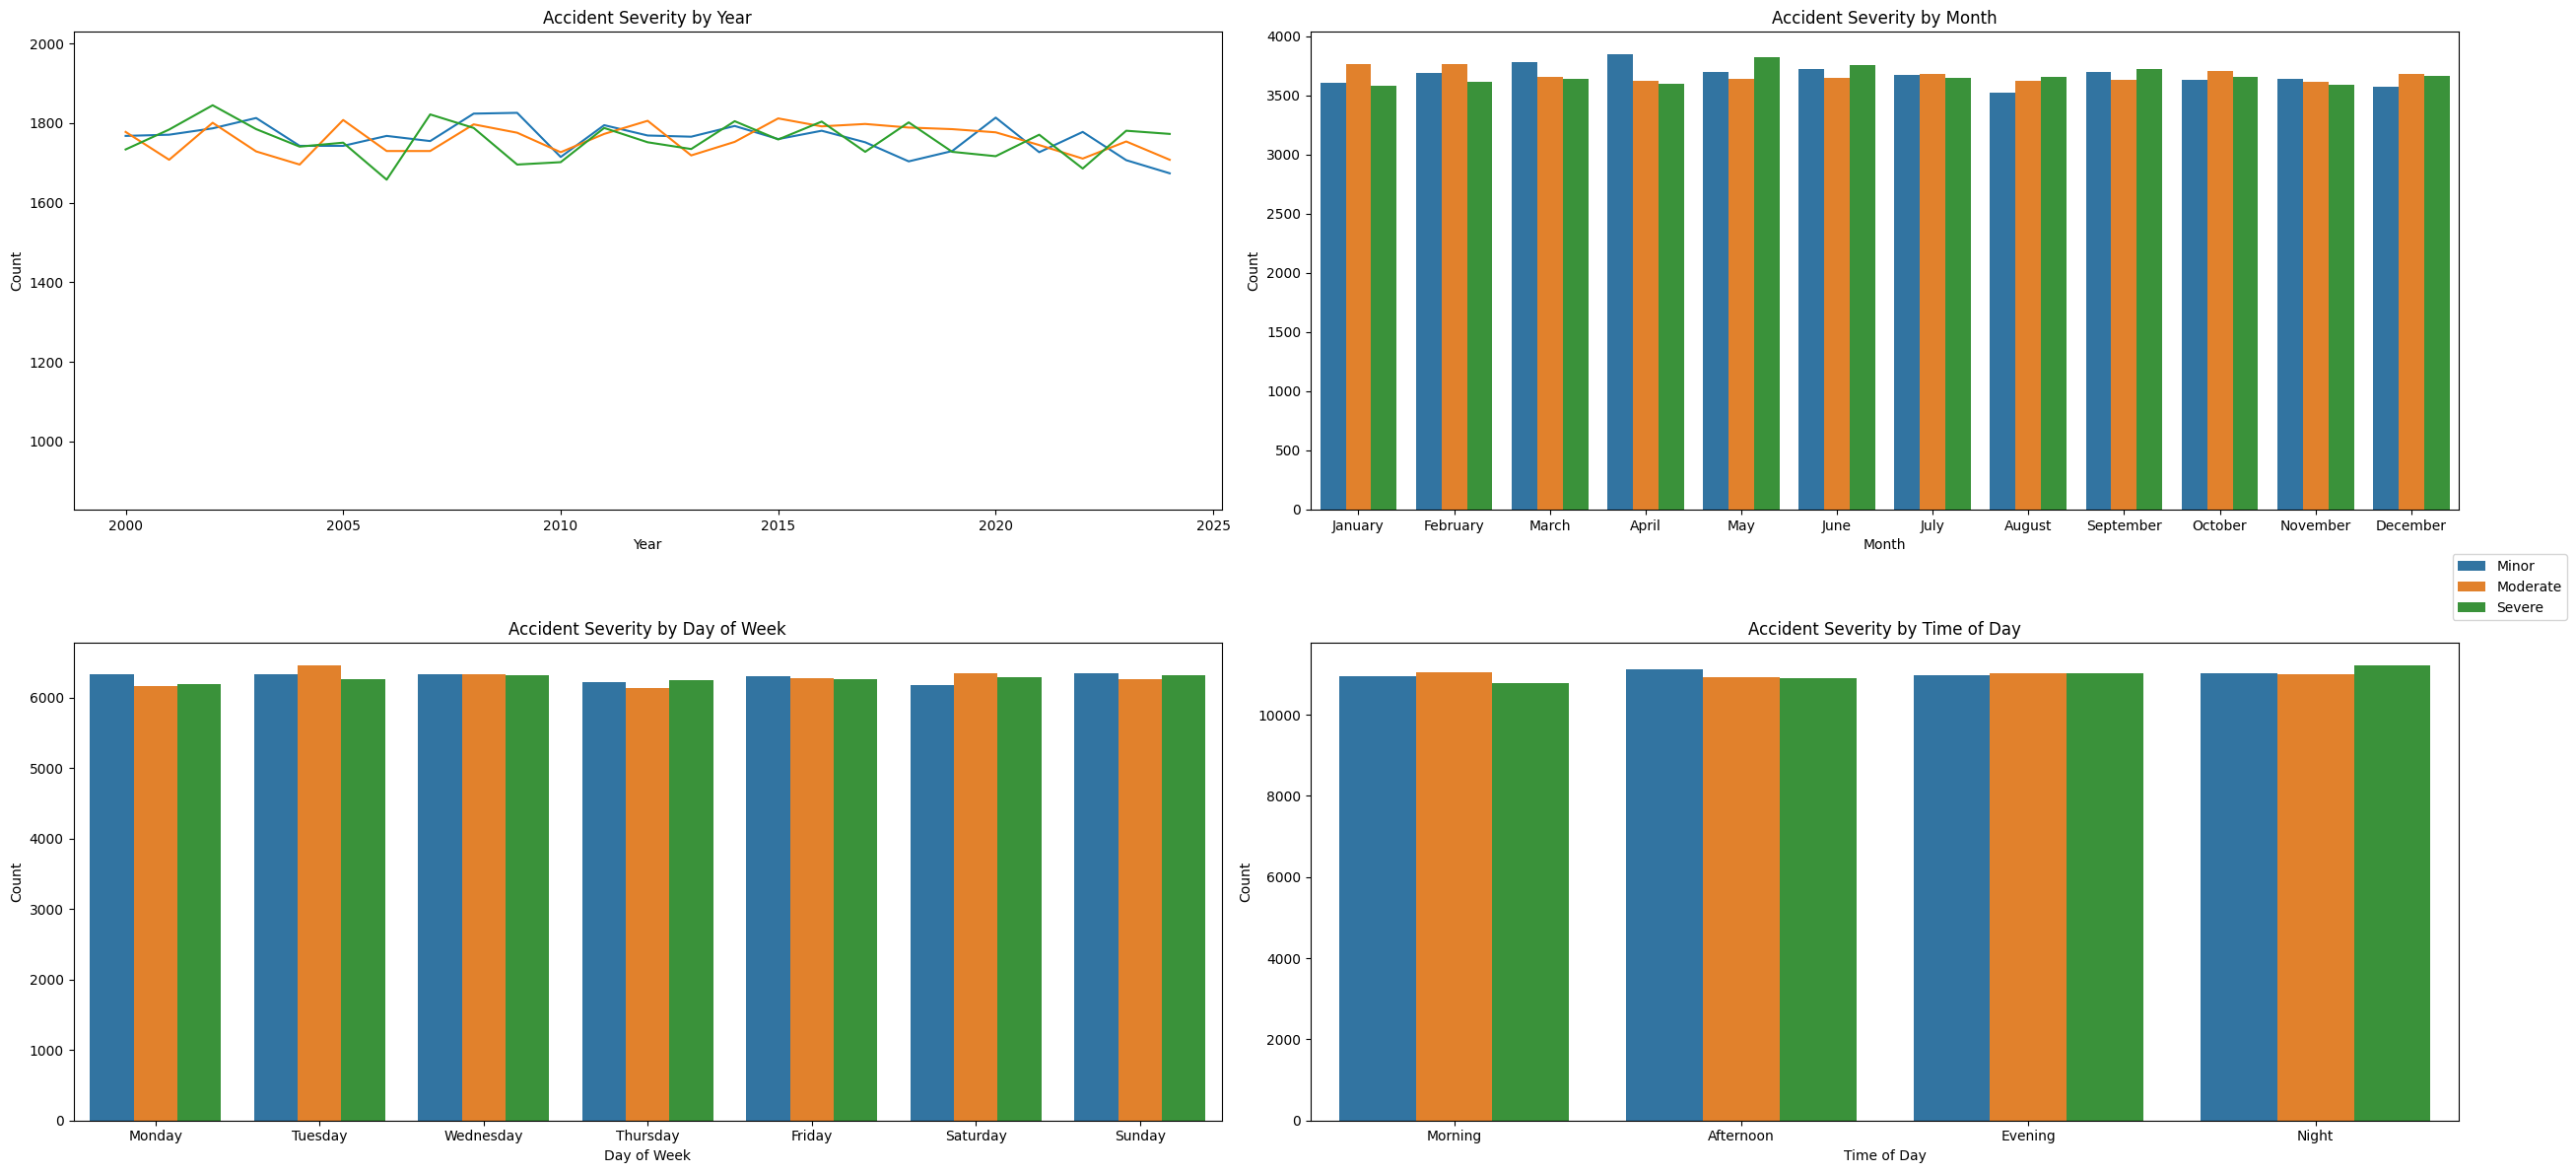

In [29]:
# Group data
accident_severity_byyear = data.groupby(['Year', 'Accident Severity']).size().reset_index(name='Count')
accident_severity_bymonth = data.groupby(['Month', 'Accident Severity']).size().reset_index(name='Count')
accident_severity_bydayofweek = data.groupby(['Day of Week', 'Accident Severity']).size().reset_index(name='Count')
accident_severity_bytimeofday = data.groupby(['Time of Day', 'Accident Severity']).size().reset_index(name='Count')

# Plot
plt.figure(figsize=(26, 12))

plt.subplot(2, 2, 1)
sns.lineplot(data=accident_severity_byyear, x='Year', y='Count', hue='Accident Severity', legend= False)
plt.title("Accident Severity by Year")
plt.ylim(accident_severity_byyear['Count'].min() * 0.5, accident_severity_byyear['Count'].max() * 1.1)


plt.subplot(2, 2, 2)
sns.barplot(data=accident_severity_bymonth, x='Month', y='Count', hue='Accident Severity', order=month_order, legend= False)
plt.title("Accident Severity by Month")

plt.subplot(2, 2, 3)
sns.barplot(data=accident_severity_bydayofweek, x='Day of Week', y='Count', hue='Accident Severity', order=day_order, legend= False)
plt.title("Accident Severity by Day of Week")

plt.subplot(2, 2, 4)
sns.barplot(data=accident_severity_bytimeofday, x='Time of Day', y='Count', hue='Accident Severity', order=time_order)
plt.title("Accident Severity by Time of Day")
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.2))

plt.tight_layout()
plt.show()

### **3.4. Severity Index**

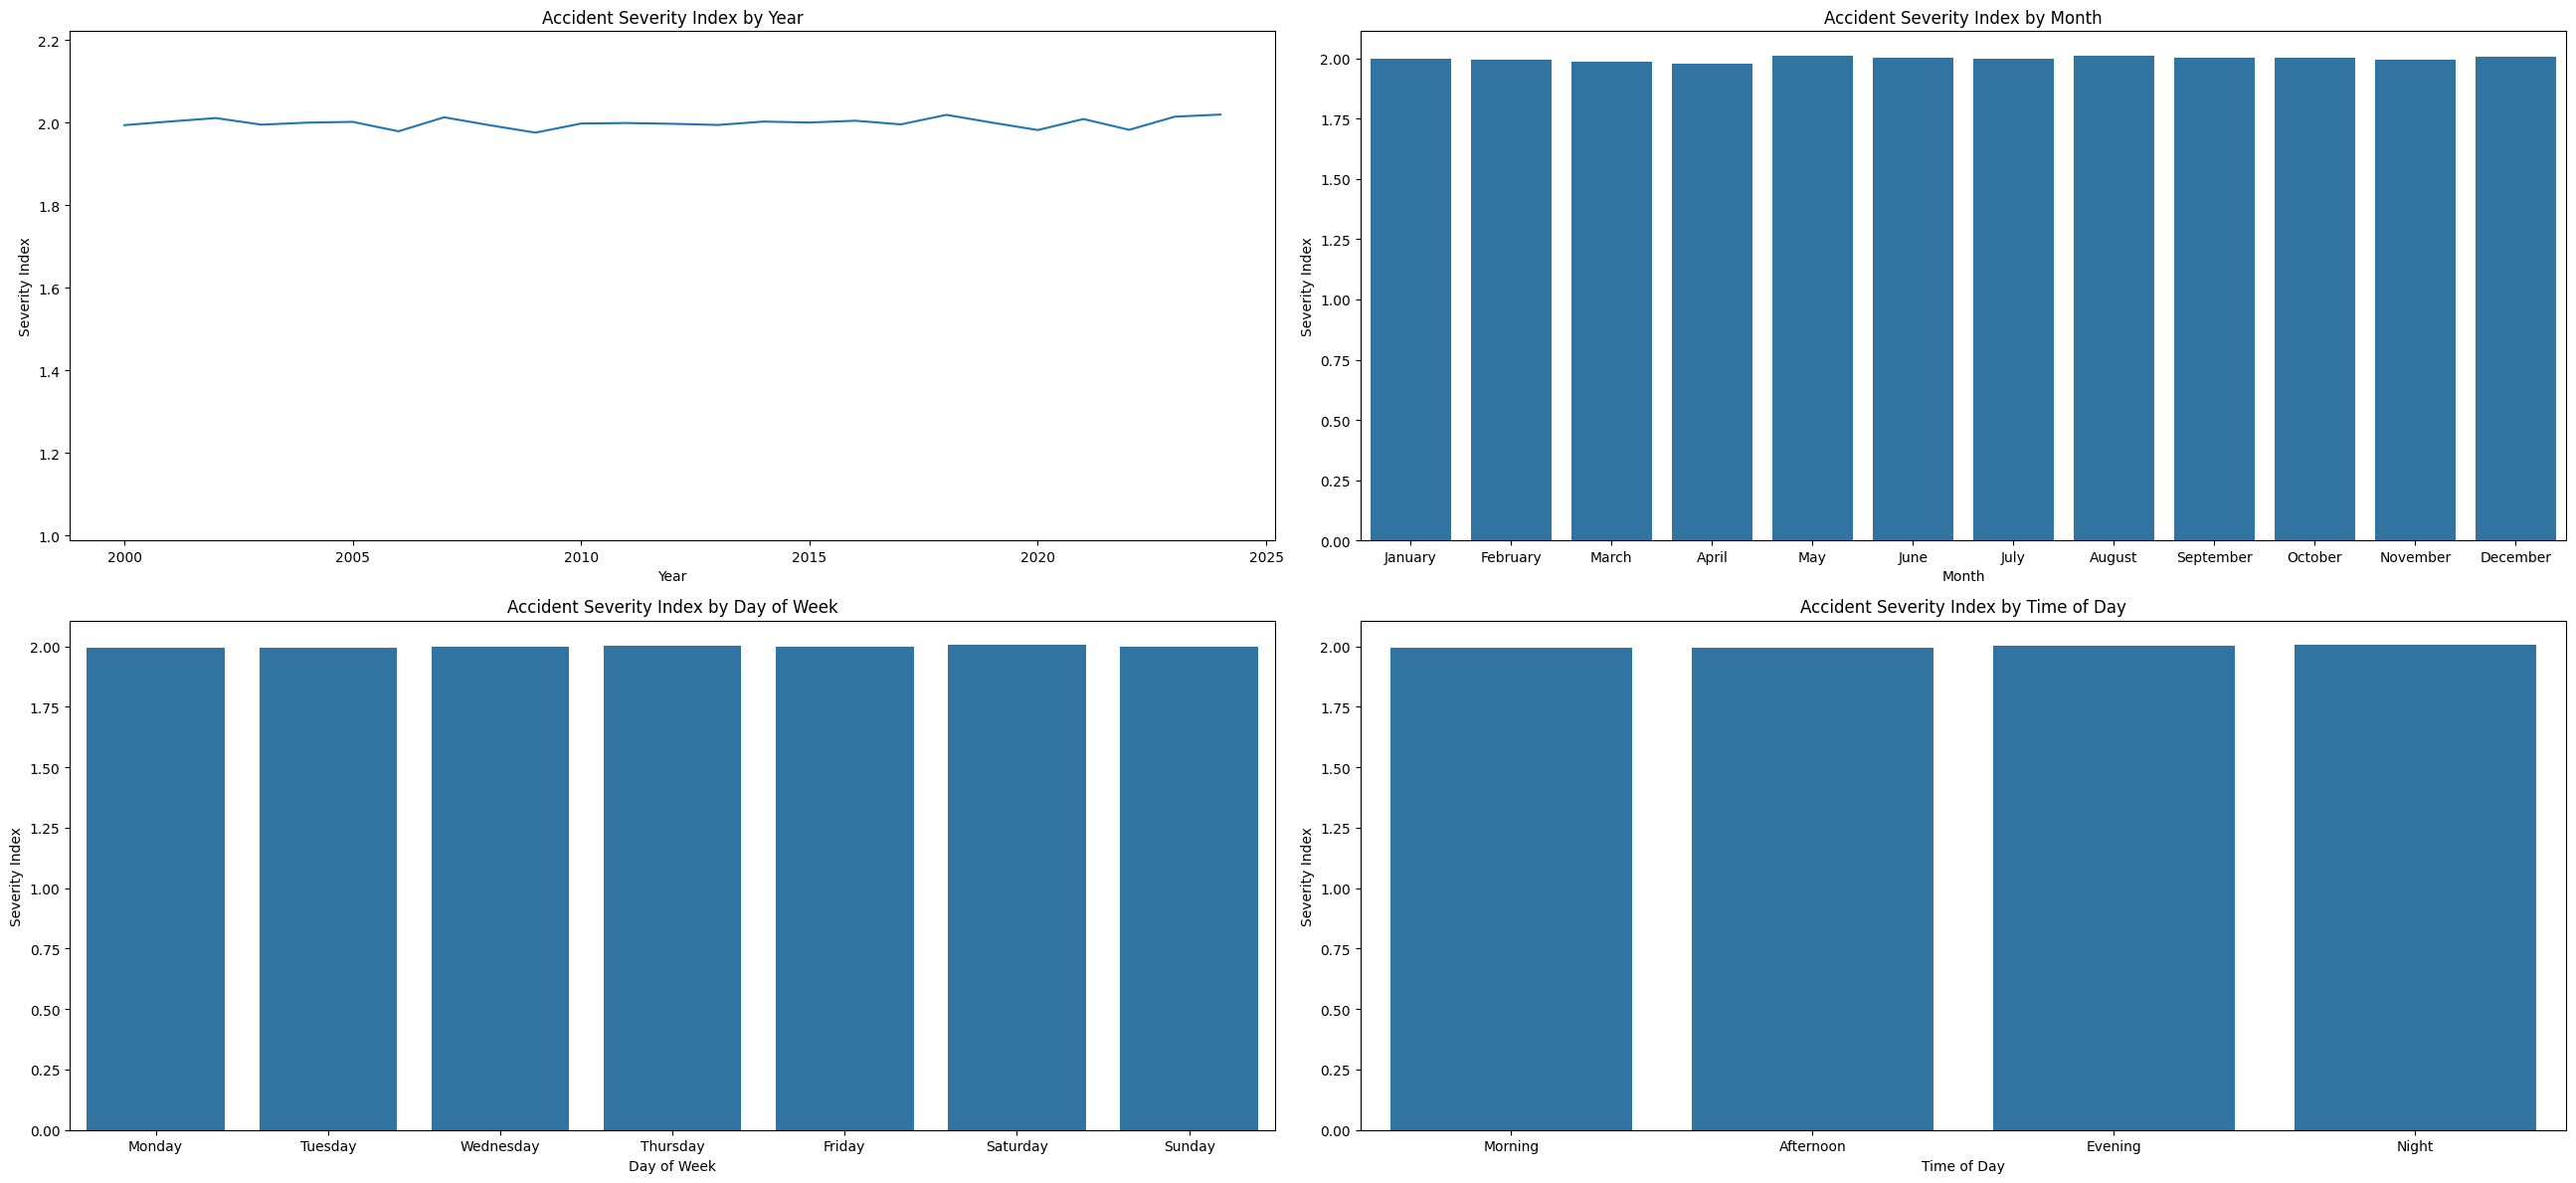

In [30]:
# Numerical Encoding of accident severity levels
severity_mapping = {"Minor": 1, "Moderate": 2, "Severe": 3}
data['Severity Score'] = data['Accident Severity'].map(severity_mapping)

# Calculate Mean (It is Weighted Average)
severity_index_by_year = data.groupby('Year')['Severity Score'].mean().reset_index(name='Severity Index')
severity_index_by_month = data.groupby('Month')['Severity Score'].mean().reset_index(name='Severity Index')
severity_index_by_dayofweek = data.groupby('Day of Week')['Severity Score'].mean().reset_index(name='Severity Index')
severity_index_by_timeofday = data.groupby('Time of Day')['Severity Score'].mean().reset_index(name='Severity Index')

# Plot:
plt.figure(figsize=(26, 12))

# 1. By Year
plt.subplot(2, 2, 1)
sns.lineplot(data=severity_index_by_year, x='Year', y='Severity Index')
plt.title("Accident Severity Index by Year")
plt.ylim(severity_index_by_year['Severity Index'].min() * 0.5, severity_index_by_year['Severity Index'].max() * 1.1)

# 2. By Month
plt.subplot(2, 2, 2)
sns.barplot(data=severity_index_by_month, x='Month', y='Severity Index', order=month_order)
plt.title("Accident Severity Index by Month")

# 3. By Day of the Week
plt.subplot(2, 2, 3)
sns.barplot(data=severity_index_by_dayofweek, x='Day of Week', y='Severity Index', order=day_order)
plt.title("Accident Severity Index by Day of Week")

# By Time of the Day
plt.subplot(2, 2, 4)
sns.barplot(data=severity_index_by_timeofday, x='Time of Day', y='Severity Index', order=time_order)
plt.title("Accident Severity Index by Time of Day")

plt.tight_layout()
plt.show()

### **3.6 Vehicles Involved in Accident by Time**

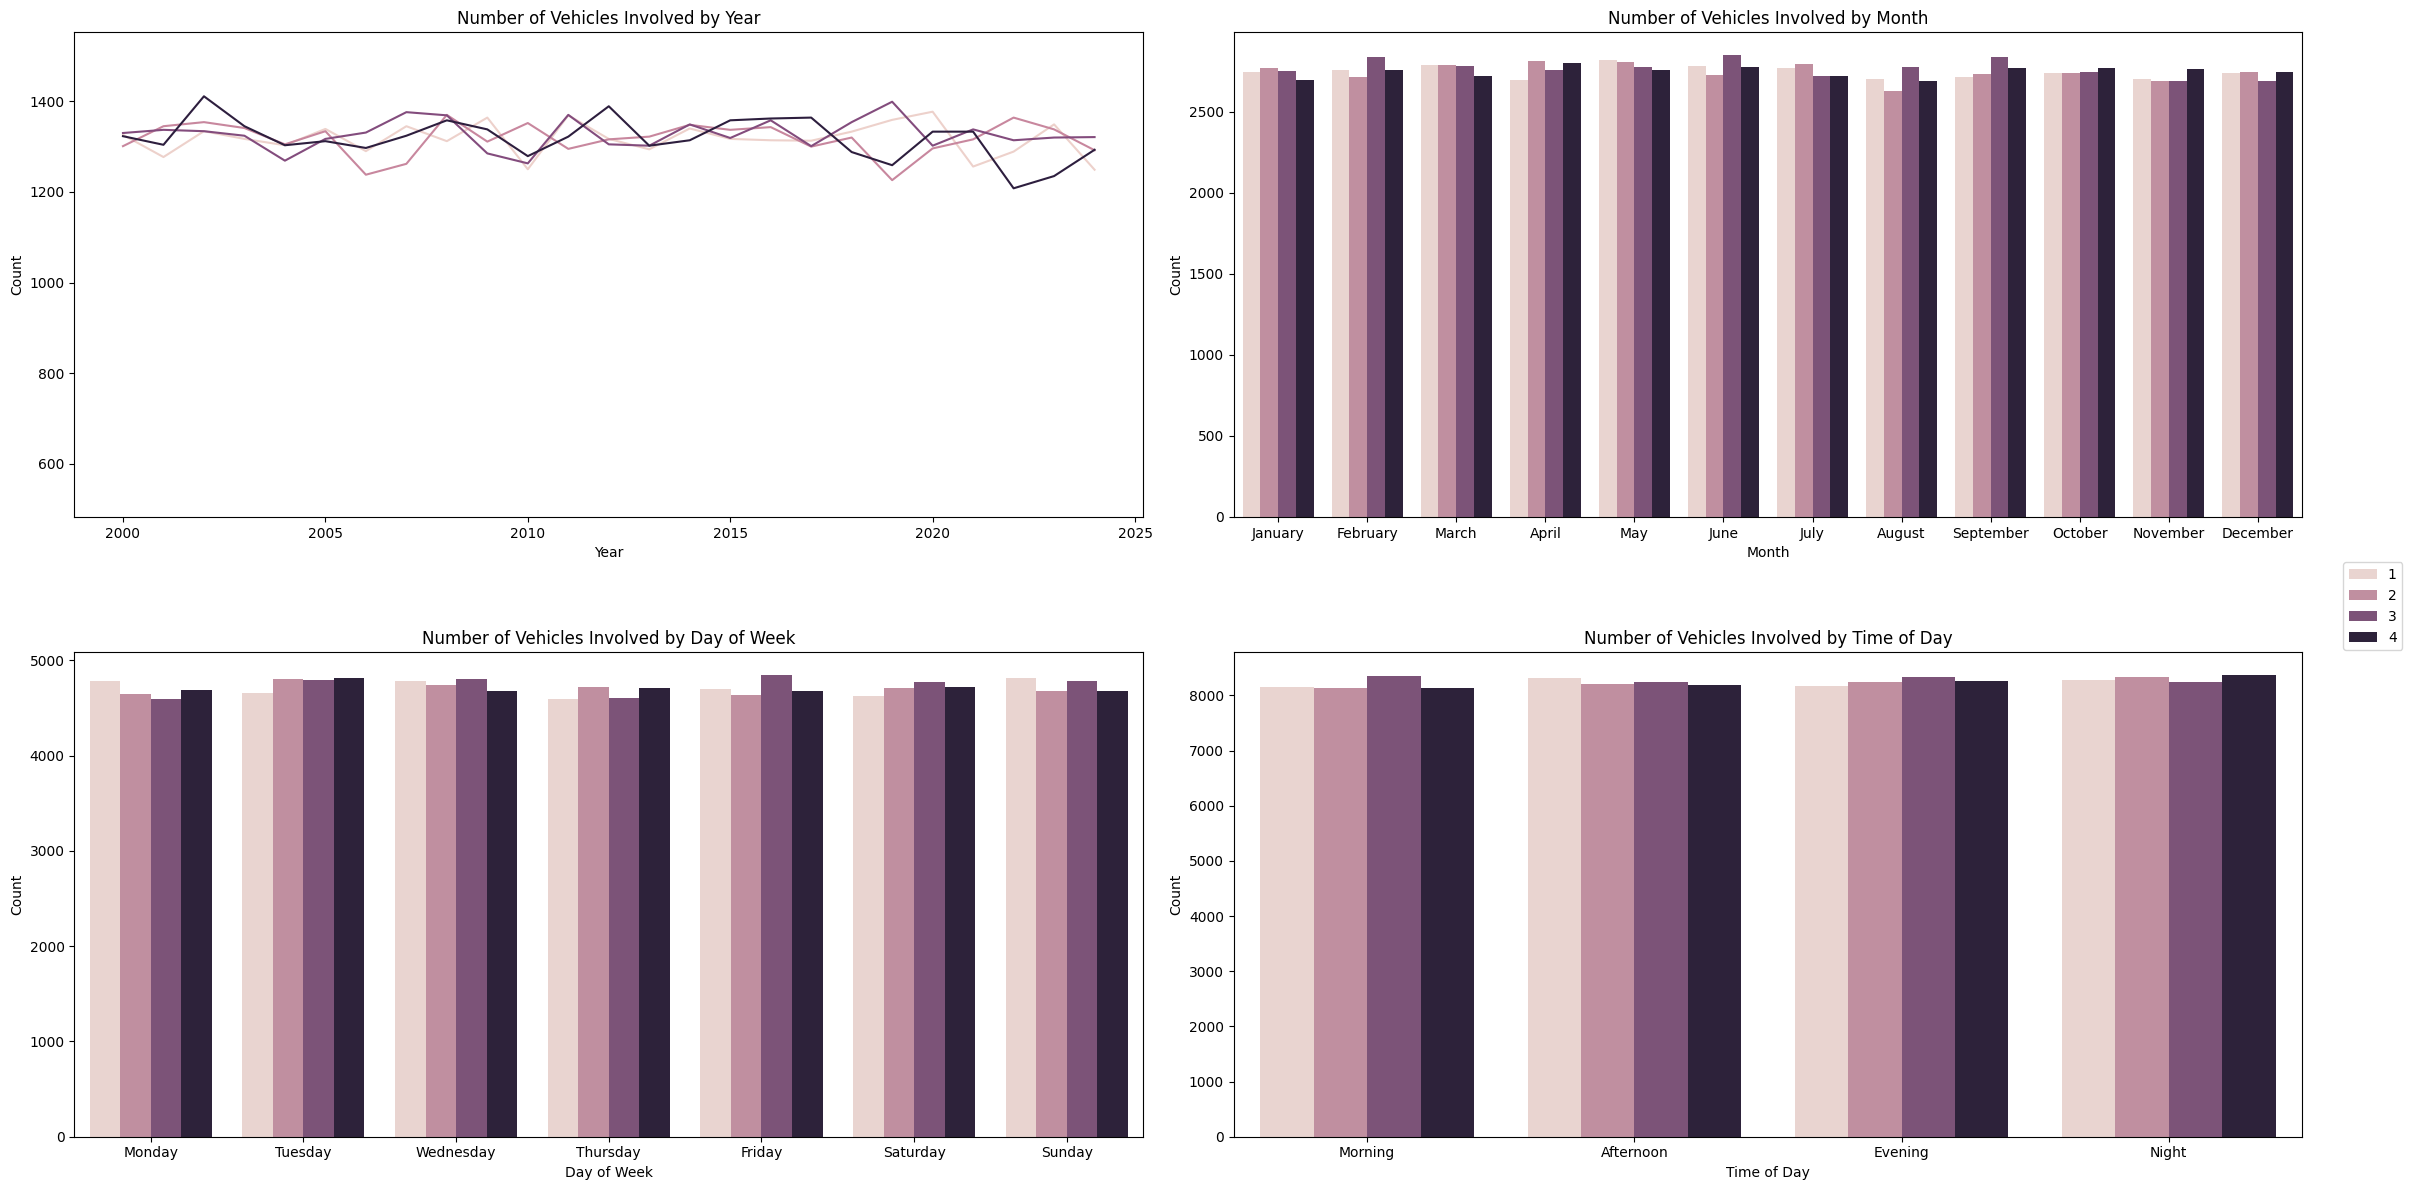

In [31]:
# Group data
vehicles_involved_byyear = data.groupby(['Year', 'Number of Vehicles Involved']).size().reset_index(name='Count')
vehicles_involved_bymonth = data.groupby(['Month', 'Number of Vehicles Involved']).size().reset_index(name='Count')
vehicles_involved_bydayofweek = data.groupby(['Day of Week', 'Number of Vehicles Involved']).size().reset_index(name='Count')
vehicles_involved_bytimeofday = data.groupby(['Time of Day', 'Number of Vehicles Involved']).size().reset_index(name='Count')

# For ordering
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
time_order = ["Morning", "Afternoon", "Evening", "Night"]

# Plot
plt.figure(figsize=(24, 12))

# 1. By Year
plt.subplot(2, 2, 1)
sns.lineplot(data=vehicles_involved_byyear, x='Year', y='Count', hue='Number of Vehicles Involved', legend= False)
plt.title("Number of Vehicles Involved by Year")
plt.ylim(vehicles_involved_byyear['Count'].min()* 0.4, vehicles_involved_byyear['Count'].max()*1.1)

# 2. By Month
plt.subplot(2, 2, 2)
sns.barplot(data=vehicles_involved_bymonth, x='Month', y='Count', hue='Number of Vehicles Involved', order=month_order, legend= False)
plt.title("Number of Vehicles Involved by Month")

# 3. By Day of the Week
plt.subplot(2, 2, 3)
sns.barplot(data=vehicles_involved_bydayofweek, x='Day of Week', y='Count', hue='Number of Vehicles Involved', order=day_order, legend= False)
plt.title("Number of Vehicles Involved by Day of Week")

# 4. By Time of the Day
plt.subplot(2, 2, 4)
sns.barplot(data=vehicles_involved_bytimeofday, x='Time of Day', y='Count', hue='Number of Vehicles Involved', order=time_order)
plt.title("Number of Vehicles Involved by Time of Day")
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.2))

plt.tight_layout()
plt.show()

### **3.5.1 Average Number of Vehicles involved in a accident over Time**

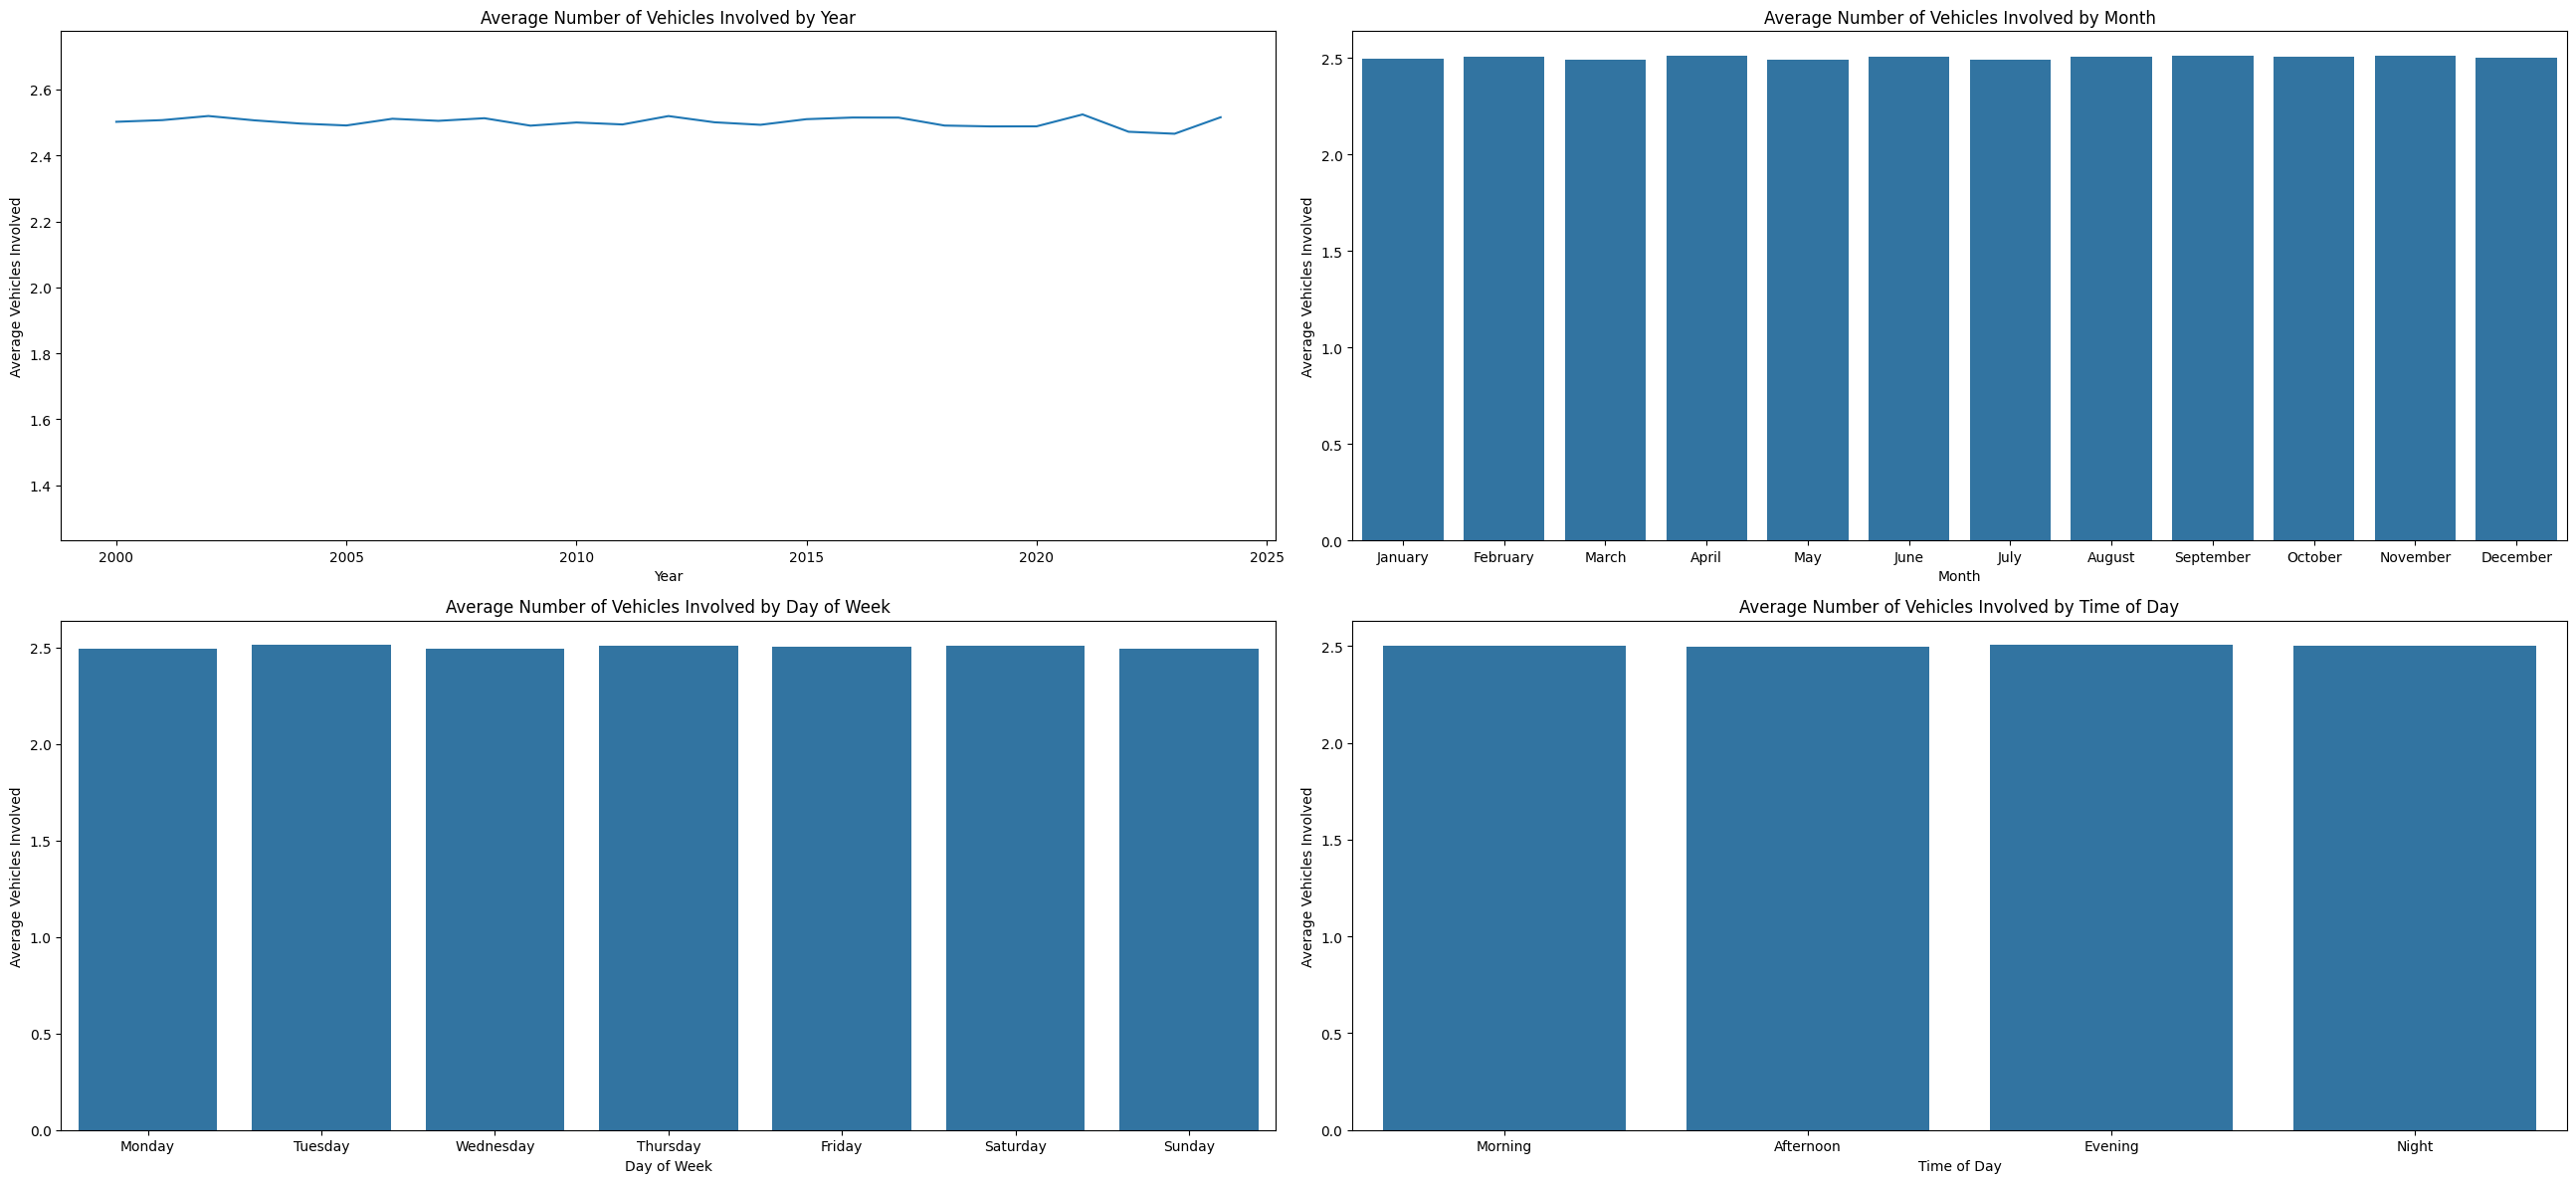

In [32]:
# Average Number of Vehicles involved in the accident by Year, Month, Day of Week and Time of Day

avg_vehicles_by_year = data.groupby('Year')['Number of Vehicles Involved'].mean().reset_index(name='Average Vehicles Involved')
avg_vehicles_by_month = data.groupby('Month')['Number of Vehicles Involved'].mean().reset_index(name='Average Vehicles Involved')
avg_vehicles_by_dayofweek = data.groupby('Day of Week')['Number of Vehicles Involved'].mean().reset_index(name='Average Vehicles Involved')
avg_vehicles_by_timeofday = data.groupby('Time of Day')['Number of Vehicles Involved'].mean().reset_index(name='Average Vehicles Involved')

# Define order for categorical variables
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
time_order = ["Morning", "Afternoon", "Evening", "Night"]

# Plot
plt.figure(figsize=(26, 12))

# 1. Year
plt.subplot(2, 2, 1)
sns.lineplot(data=avg_vehicles_by_year, x='Year', y='Average Vehicles Involved')
plt.title("Average Number of Vehicles Involved by Year")
plt.ylim(avg_vehicles_by_year['Average Vehicles Involved'].min() * 0.5, avg_vehicles_by_year['Average Vehicles Involved'].max() * 1.1)

# 2. Month
plt.subplot(2, 2, 2)
sns.barplot(data=avg_vehicles_by_month, x='Month', y='Average Vehicles Involved', order=month_order)
plt.title("Average Number of Vehicles Involved by Month")

# 3. Day of the Week
plt.subplot(2, 2, 3)
sns.barplot(data=avg_vehicles_by_dayofweek, x='Day of Week', y='Average Vehicles Involved', order=day_order)
plt.title("Average Number of Vehicles Involved by Day of Week")

# 4. Time of Day
plt.subplot(2, 2, 4)
sns.barplot(data=avg_vehicles_by_timeofday, x='Time of Day', y='Average Vehicles Involved', order=time_order)
plt.title("Average Number of Vehicles Involved by Time of Day")

plt.tight_layout()
plt.show()


### **3.6 Average Emergency Response Time Per Accident**

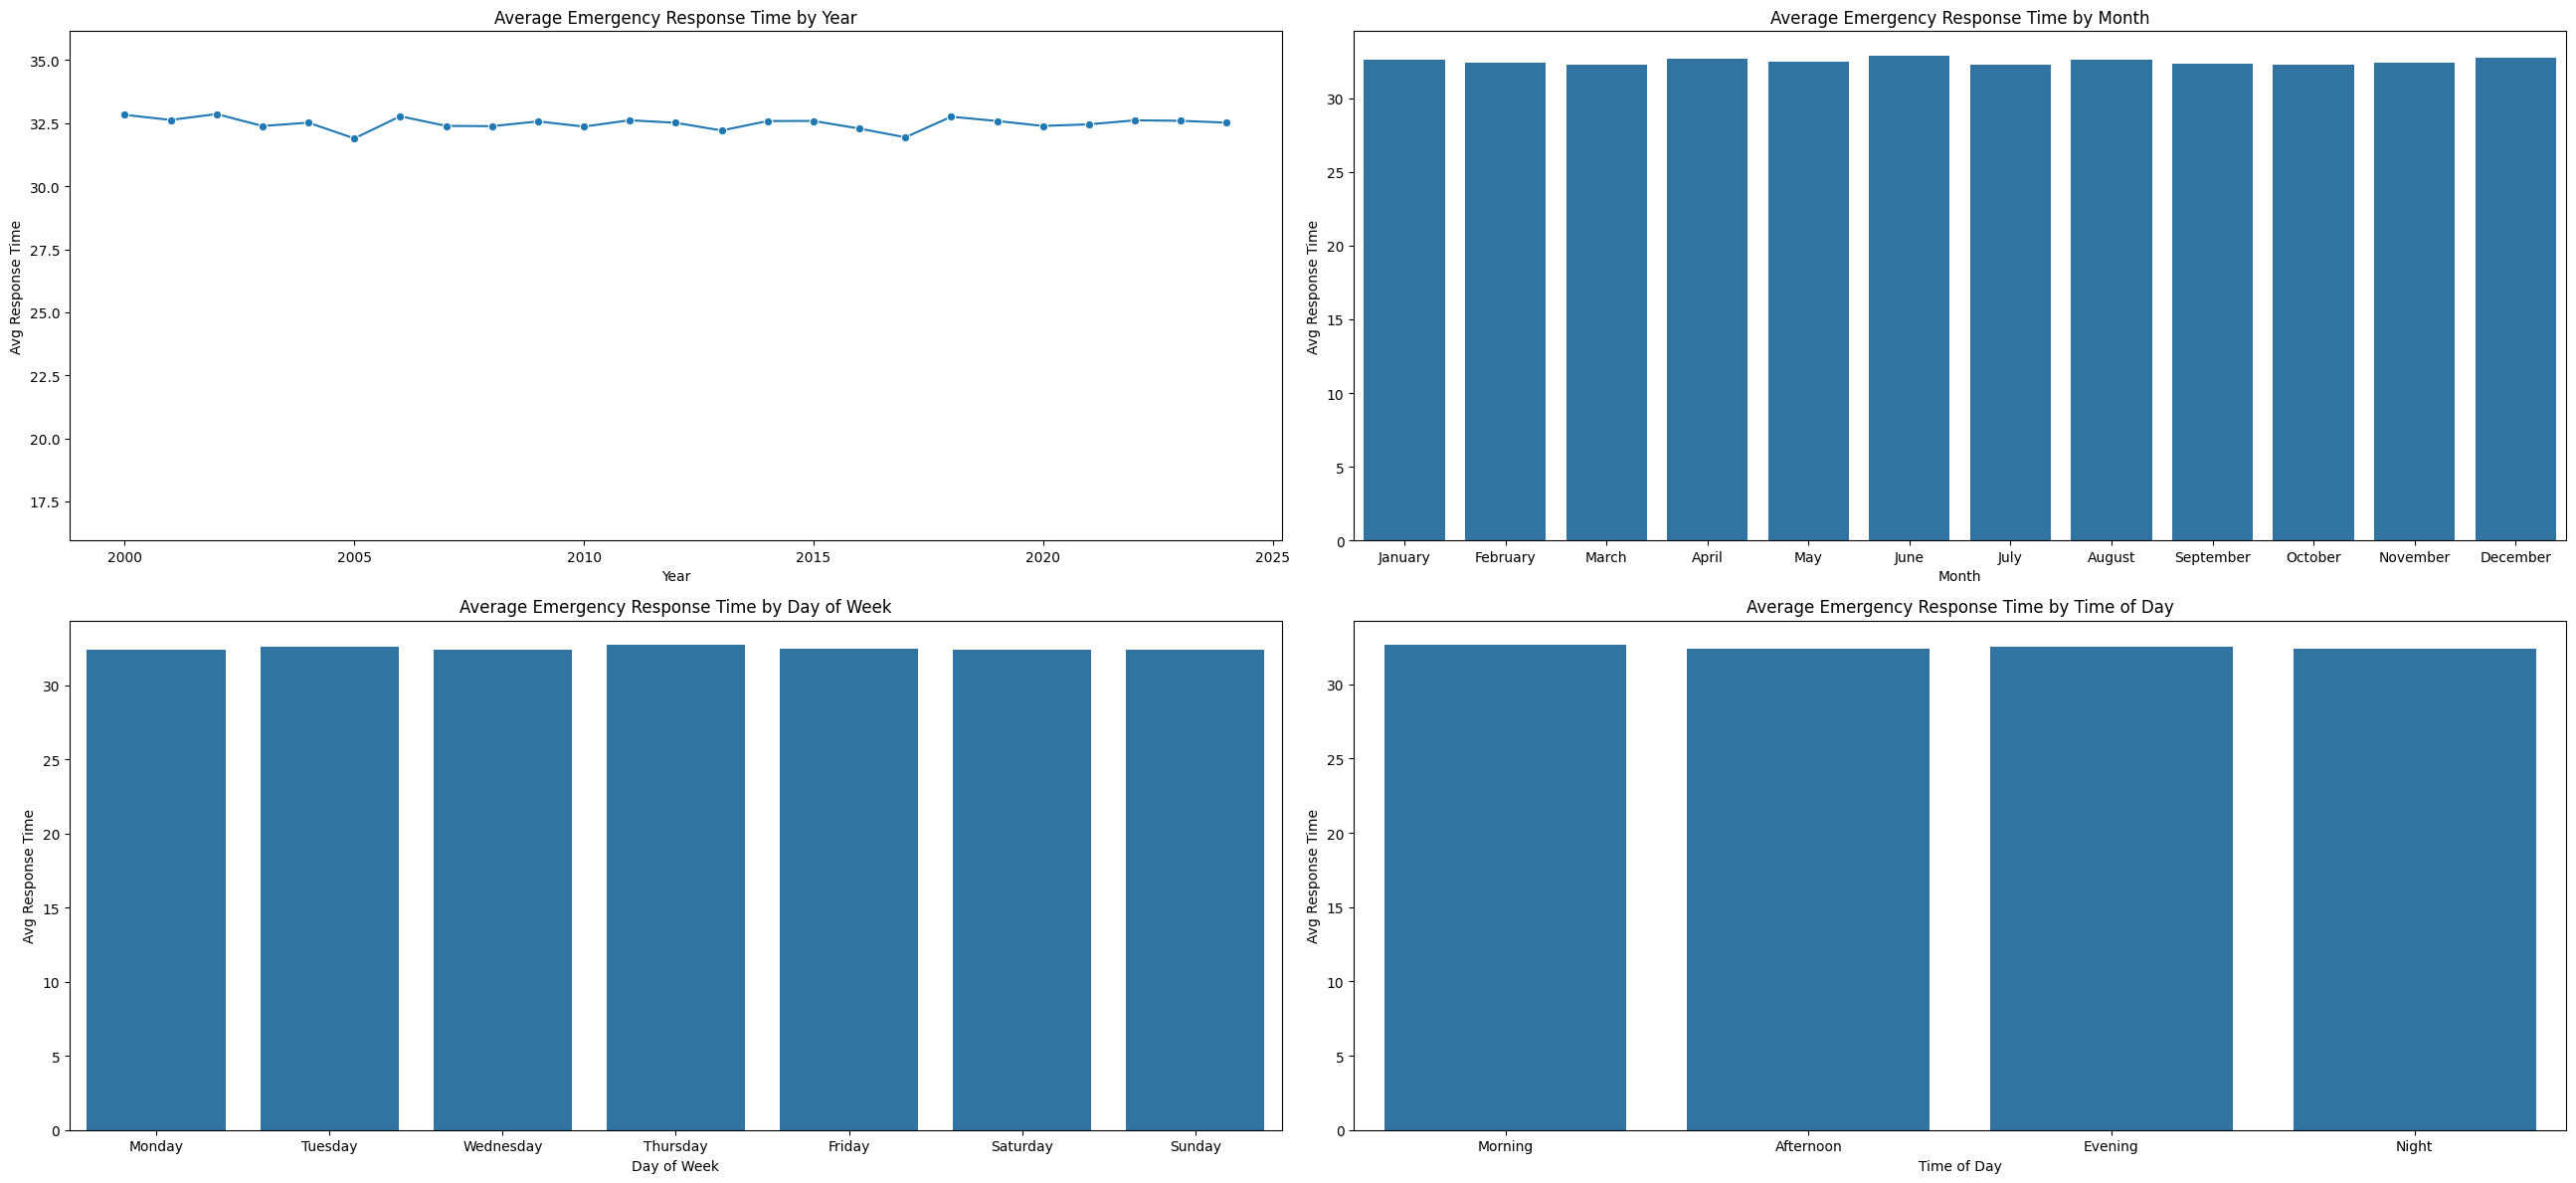

In [33]:
# Compute the average response time per time period
avg_response_by_year = data.groupby('Year')['Emergency Response Time'].mean().reset_index(name='Avg Response Time')
avg_response_by_month = data.groupby('Month')['Emergency Response Time'].mean().reset_index(name='Avg Response Time')
avg_response_by_dayofweek = data.groupby('Day of Week')['Emergency Response Time'].mean().reset_index(name='Avg Response Time')
avg_response_by_timeofday = data.groupby('Time of Day')['Emergency Response Time'].mean().reset_index(name='Avg Response Time')

# Define categorical order for better visualization
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
time_order = ["Morning", "Afternoon", "Evening", "Night"]

# Plot
plt.figure(figsize=(26, 12))

# 1. Year
plt.subplot(2, 2, 1)
sns.lineplot(data=avg_response_by_year, x='Year', y='Avg Response Time', marker='o')
plt.title("Average Emergency Response Time by Year")
plt.ylim(avg_response_by_year['Avg Response Time'].min()*0.5, avg_response_by_year['Avg Response Time'].max()*1.1)

# 2. Month
plt.subplot(2, 2, 2)
sns.barplot(data=avg_response_by_month, x='Month', y='Avg Response Time', order=month_order)
plt.title("Average Emergency Response Time by Month")

# 3. Day of the Week
plt.subplot(2, 2, 3)
sns.barplot(data=avg_response_by_dayofweek, x='Day of Week', y='Avg Response Time', order=day_order)
plt.title("Average Emergency Response Time by Day of Week")

# 4. Time of Day
plt.subplot(2, 2, 4)
sns.barplot(data=avg_response_by_timeofday, x='Time of Day', y='Avg Response Time', order=time_order)
plt.title("Average Emergency Response Time by Time of Day")

plt.tight_layout()
plt.show()

## **4. Geographic Analysis**
- `Country`, and `Urban/Rural` are Geospatial variables
- Lets us consider `Accident Severity` and Impact Metrics against the Geographic features. 

### **4.1 Accident Severity by Country**

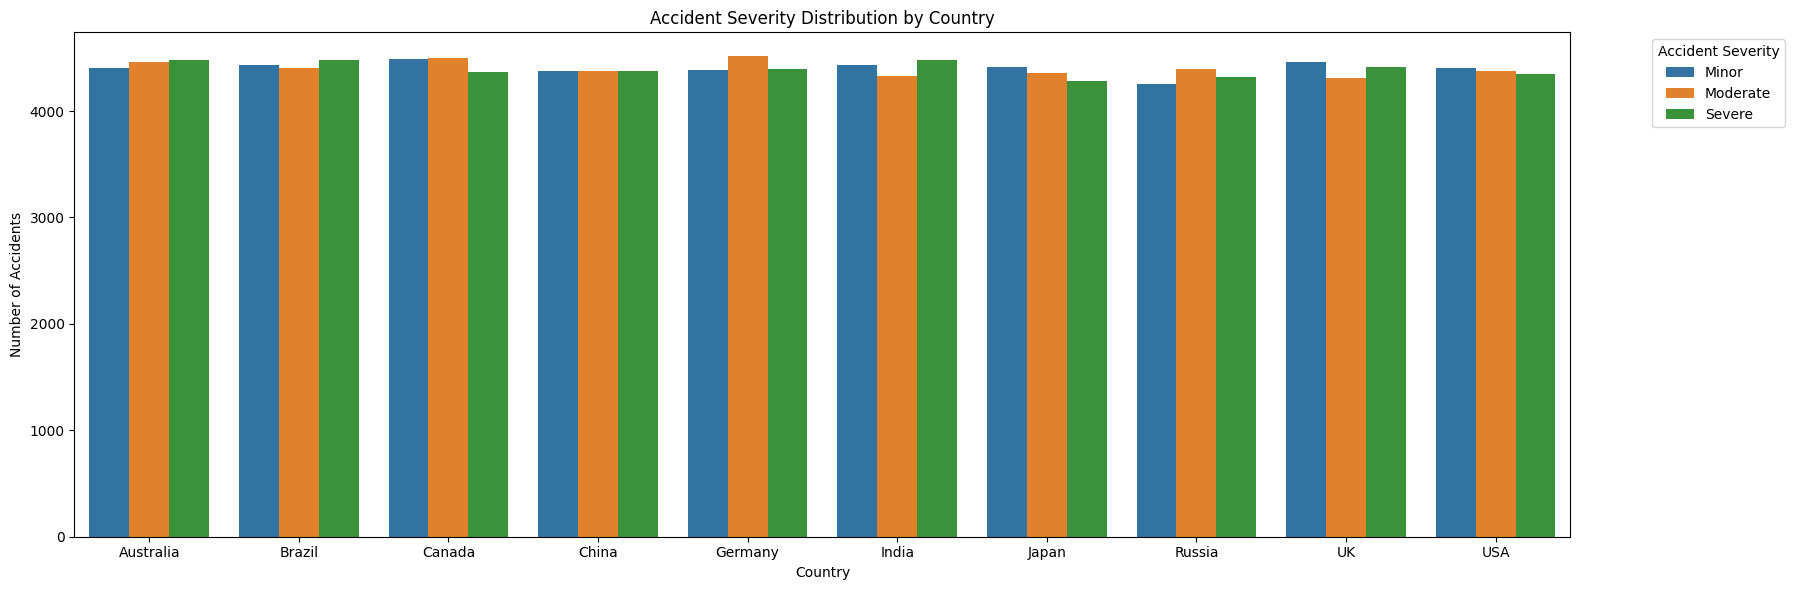

In [34]:
impact_cols = ['Number of Injuries', 'Number of Fatalities', 'Medical Cost', 'Economic Loss']
severity_by_country= data.groupby(['Country', 'Accident Severity']).size().unstack(fill_value= 0).reset_index().melt(id_vars= 'Country',
                                                                                                                     var_name= 'Accident Severity',
                                                                                                                     value_name= 'Value')
# Plot
plt.figure(figsize=(18, 6))
sns.barplot(data= severity_by_country, x= 'Country', y= 'Value', hue= 'Accident Severity')
plt.title("Accident Severity Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Accidents")

plt.legend(title="Accident Severity", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### **4.2 Accident Severity by Urban/Rural area**

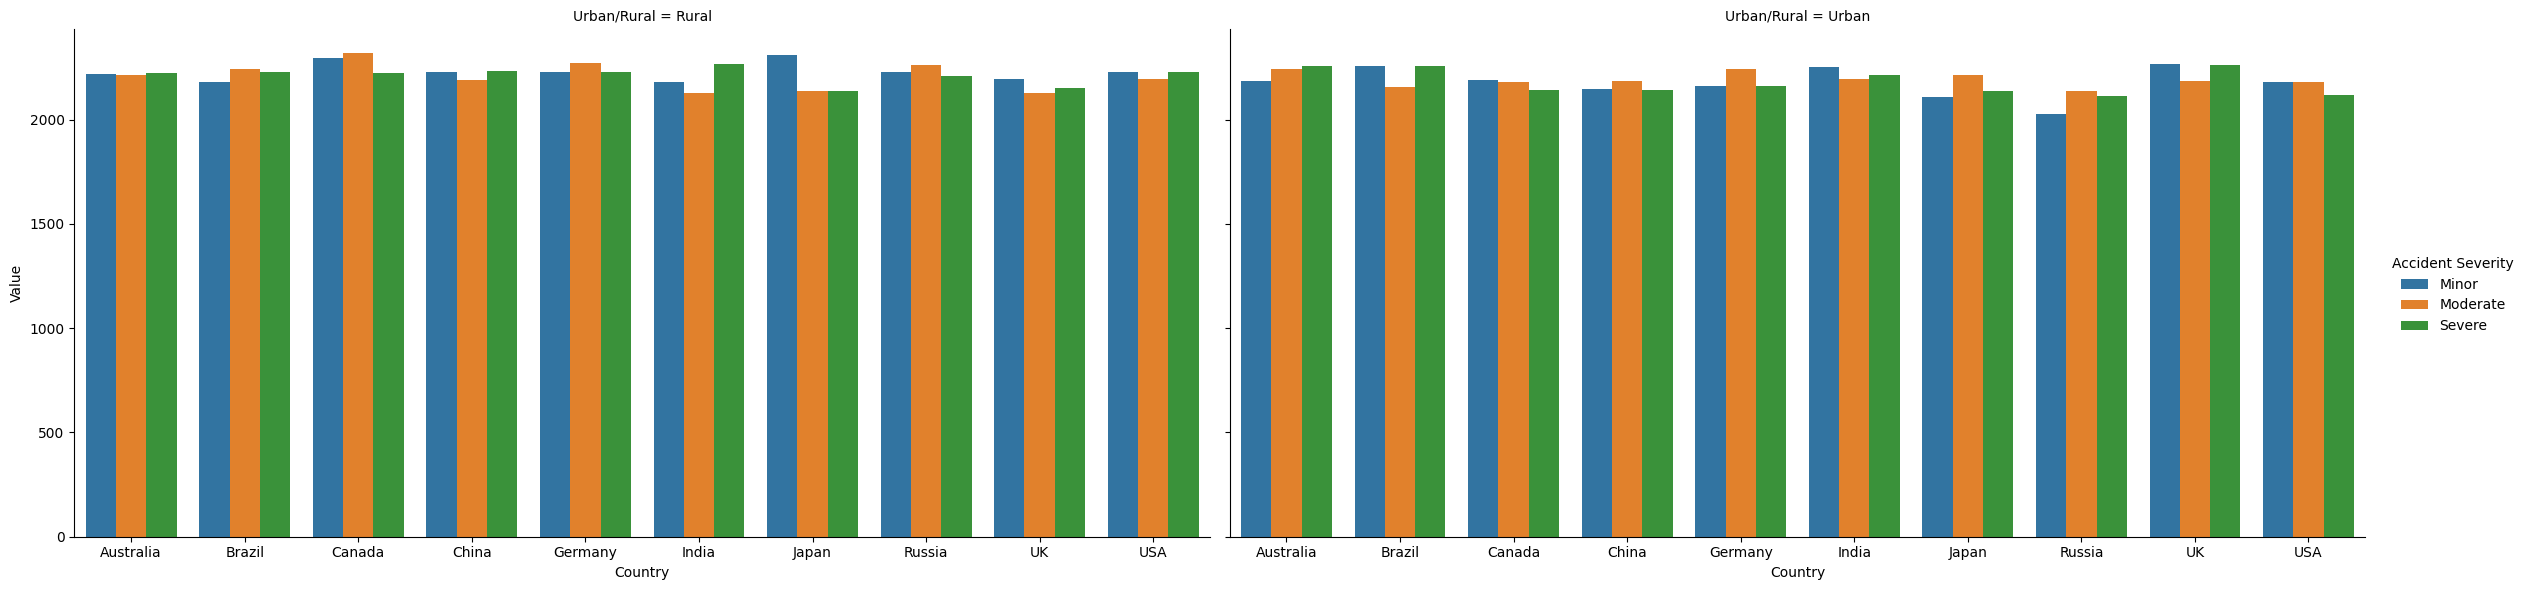

In [35]:
# Distribution of Accident Severity by Country and Urabn/Rural area
severity_by_geospat= data.groupby(['Country', 'Urban/Rural', 'Accident Severity']).size().unstack(fill_value= 0).reset_index()

severity_by_geospat_melted = severity_by_geospat.melt(id_vars=['Country', 'Urban/Rural'],
                                                       var_name='Accident Severity',
                                                       value_name='Value')

# Plot
sns.catplot(data= severity_by_geospat_melted, x= 'Country', y= 'Value', hue= 'Accident Severity', kind= 'bar', col= 'Urban/Rural', height=6, aspect=2)

plt.show()

### **4.3 Impact Metrics by Country**

In [36]:
impact_matric_by_geospat = data.groupby(['Country']).agg(
    injured=("Number of Injuries", "sum"),
    fatalities=("Number of Fatalities", "sum"),
    medical_cost=("Medical Cost", "sum"),
    economic_loss=("Economic Loss", "sum")).reset_index()

# Convert large values to Millions for better context
impact_matric_by_geospat['Medical Cost (Millions)'] = impact_matric_by_geospat['medical_cost'] / 1_000_000
impact_matric_by_geospat['Economic Loss (Millions)'] = impact_matric_by_geospat['economic_loss'] / 1_000_000

impact_matric_by_geospat.head()

,Country,injured,fatalities,medical_cost,economic_loss,Medical Cost (Millions),Economic Loss (Millions)
0,Australia,126912,26837,3.353049e+08,6.667312e+08,335.304880,666.731191
1,Brazil,127753,26589,3.347893e+08,6.756055e+08,334.789293,675.605472
2,Canada,126733,26566,3.381464e+08,6.782144e+08,338.146449,678.214435
3,China,124277,26051,3.303432e+08,6.655719e+08,330.343178,665.571862
4,Germany,126930,26444,3.334442e+08,6.702259e+08,333.444234,670.225937


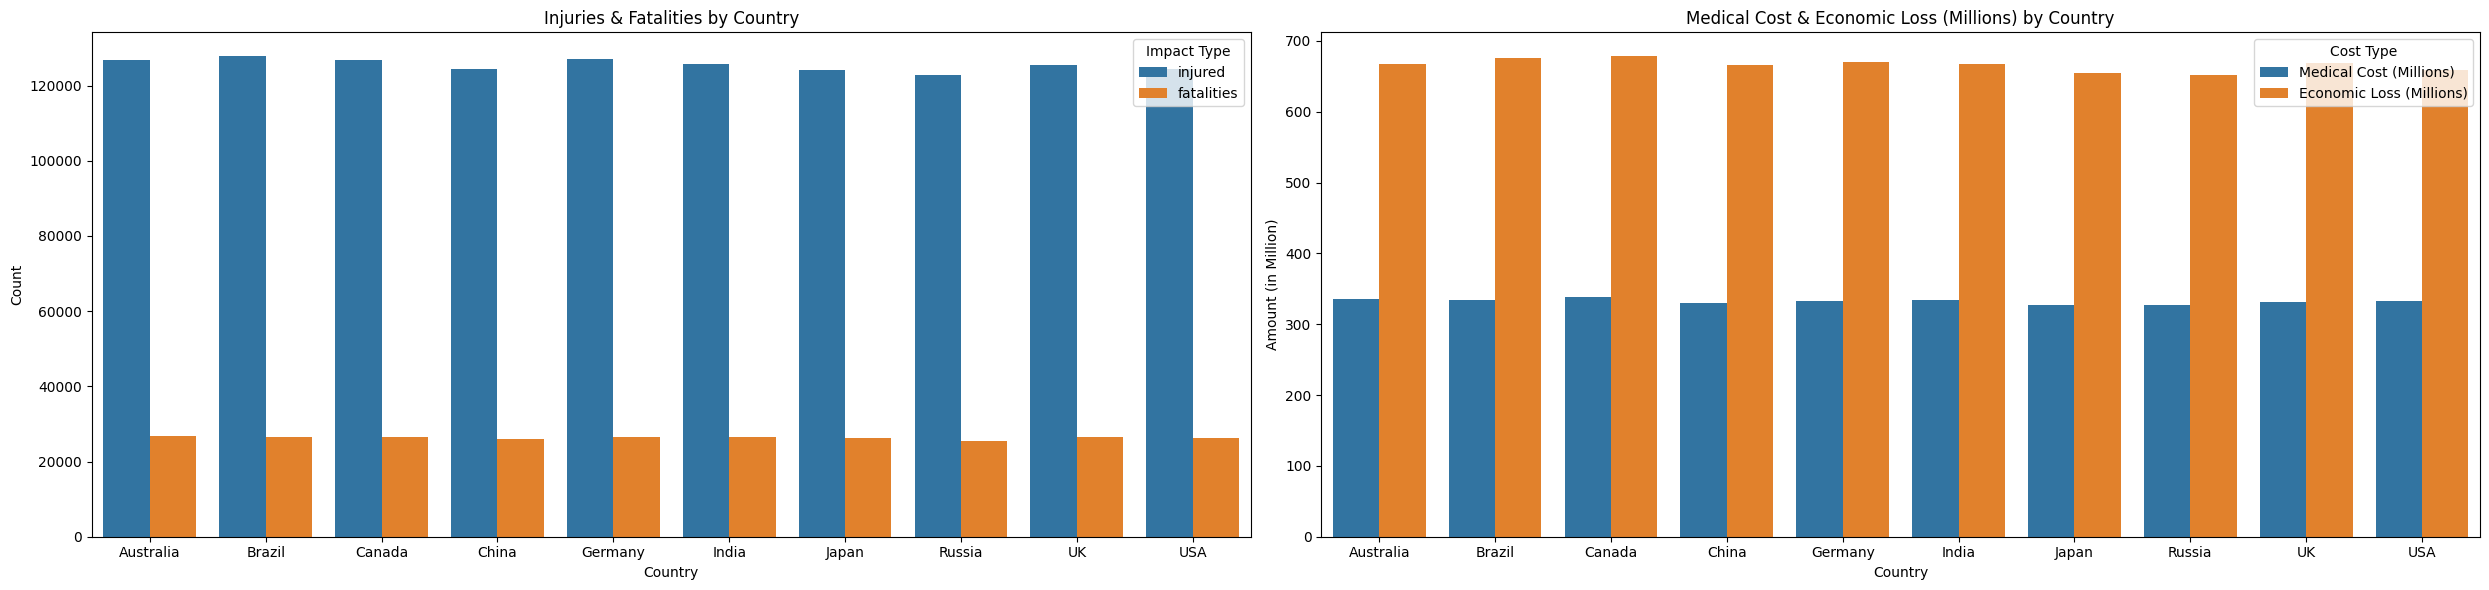

In [37]:
# Melt and Divide data into two
impact_matric_by_geospat1 = impact_matric_by_geospat.melt(
    id_vars=['Country'], 
    value_vars=['injured', 'fatalities'], 
    var_name='Impact Type', value_name='Count')

impact_matric_by_geospat2 = impact_matric_by_geospat.melt(
    id_vars=['Country'], 
    value_vars=['Medical Cost (Millions)', 'Economic Loss (Millions)'],
    var_name='Cost Type', value_name='Amount')

# Plots
plt.figure(figsize=(25, 6))

# Plot: Injuries and Fatalities
plt.subplot(1, 2, 1)
sns.barplot(data=impact_matric_by_geospat1, x='Country', y='Count', hue='Impact Type')
plt.title("Injuries & Fatalities by Country")
plt.legend(title="Impact Type")

# Plot: Medical Cost & Economic Loss
plt.subplot(1, 2, 2)
sns.barplot(data=impact_matric_by_geospat2, x='Country', y='Amount', hue='Cost Type')
plt.title("Medical Cost & Economic Loss (Millions) by Country")
plt.ylabel("Amount (in Million)")
plt.legend(title="Cost Type")

plt.tight_layout()
plt.show()

### **4.3 Average Number of Vehicles Involved in a Accident by Country & Urban/Rural area**

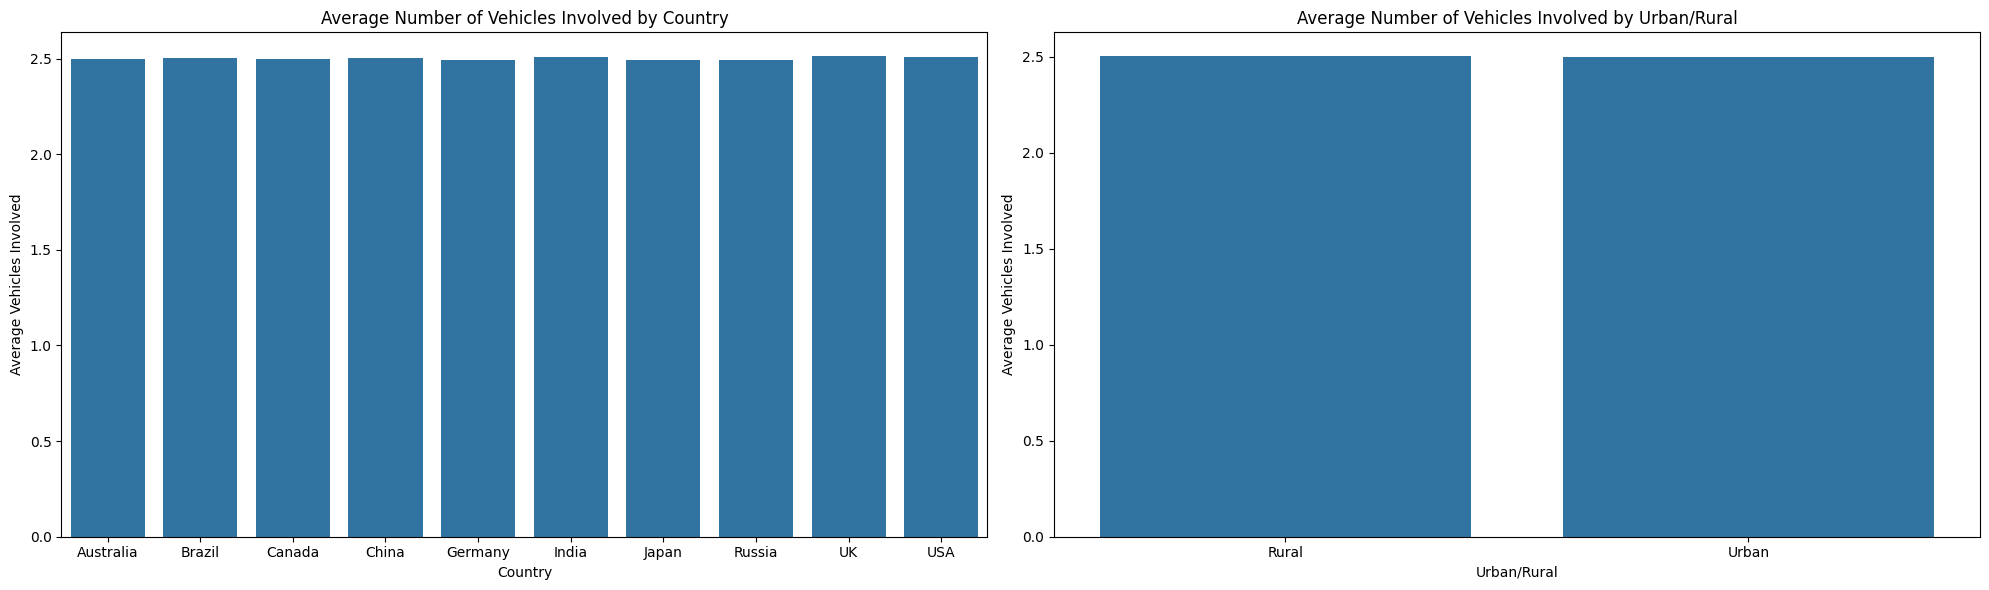

In [38]:
# Group data
avg_vehicles_by_country = data.groupby('Country')['Number of Vehicles Involved'].mean().reset_index(name='Average Vehicles Involved')
avg_vehicles_by_urbanrural = data.groupby('Urban/Rural')['Number of Vehicles Involved'].mean().reset_index(name='Average Vehicles Involved')

# Plots
plt.figure(figsize=(20, 6))

# 1. Average Number of Vehicles Involved by Country
plt.subplot(1, 2, 1)
sns.barplot(data=avg_vehicles_by_country, x='Country', y='Average Vehicles Involved')
plt.title("Average Number of Vehicles Involved by Country")

# 2. Average Number of Vehicles Involved by Urban/Rural
plt.subplot(1, 2, 2)
sns.barplot(data=avg_vehicles_by_urbanrural, x='Urban/Rural', y='Average Vehicles Involved')
plt.title("Average Number of Vehicles Involved by Urban/Rural")

plt.tight_layout()
plt.show()

### **4.4 Average Emergency Response Time by Country & Urban/Rural area**

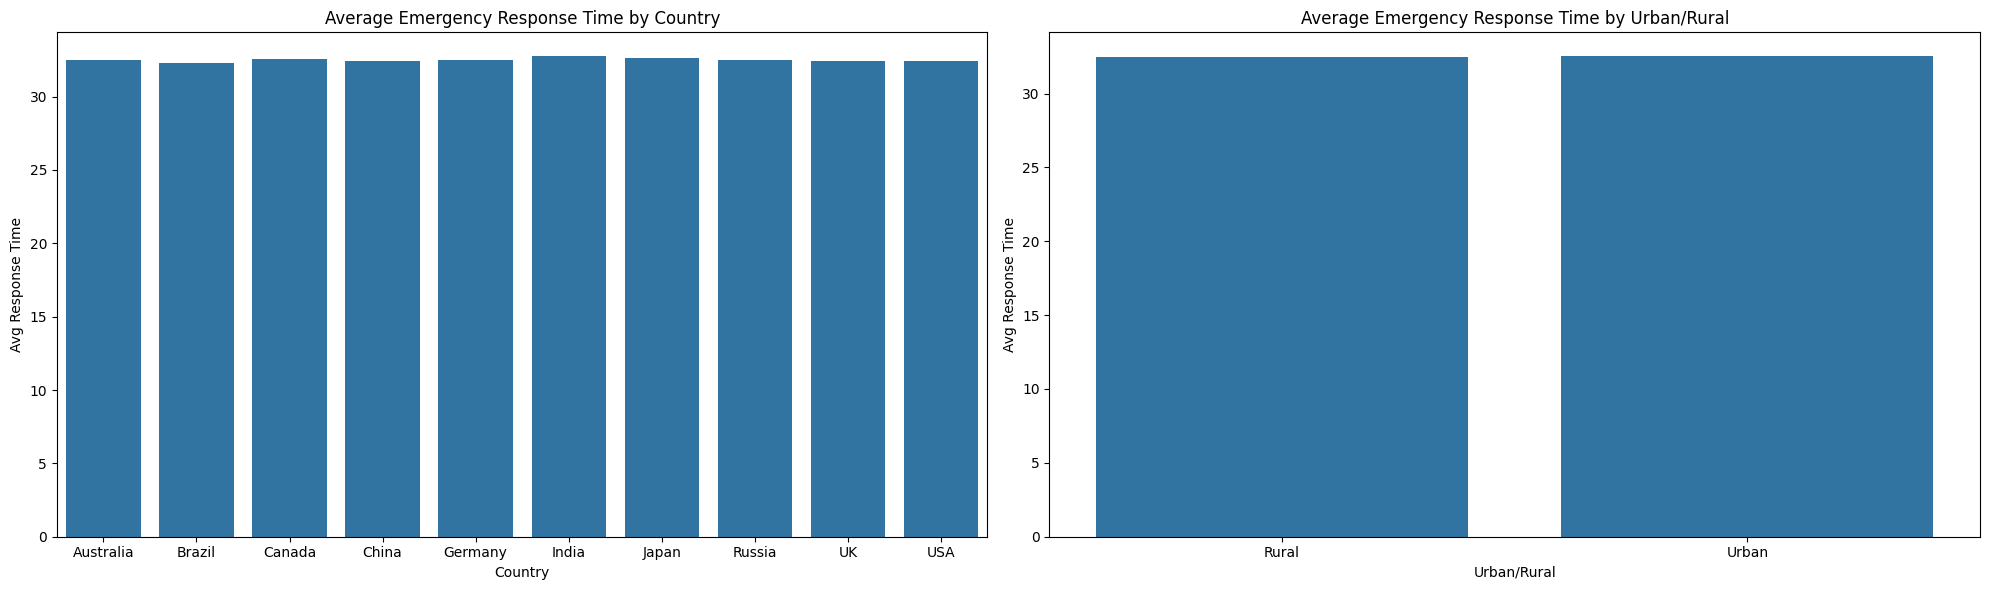

In [39]:
# Group Data
avg_response_by_country = data.groupby('Country')['Emergency Response Time'].mean().reset_index(name='Avg Response Time')
avg_response_by_urbanrural = data.groupby('Urban/Rural')['Emergency Response Time'].mean().reset_index(name='Avg Response Time')

# Plots
plt.figure(figsize=(20, 6))

# 1. Average Emergency Response Time by Country
plt.subplot(1, 2, 1)
sns.barplot(data=avg_response_by_country, x='Country', y='Avg Response Time')
plt.title("Average Emergency Response Time by Country")

# 2. Average Emergency Response Time by Urban/Rural
plt.subplot(1, 2, 2)
sns.barplot(data=avg_response_by_urbanrural, x='Urban/Rural', y='Avg Response Time')
plt.title("Average Emergency Response Time by Urban/Rural")

plt.tight_layout()
plt.show()

## **5. Driver and Vehicle Factors**

#### **5.1 Driver Age Group and Impact Metrics**

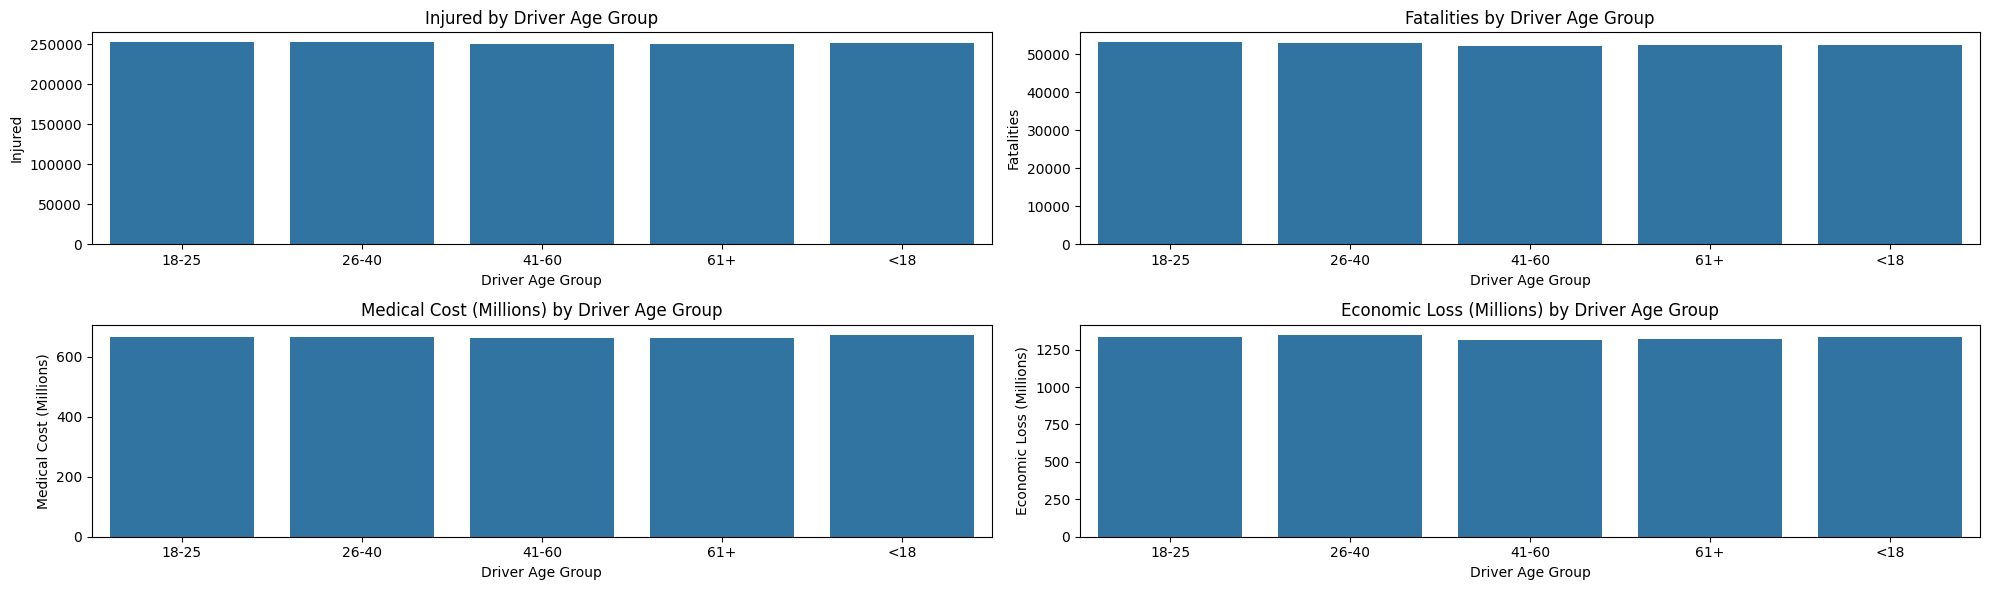

In [40]:
# Group the data

impact_Metrics_by_driveragegroup = data.groupby(['Driver Age Group']).agg(
    injured=("Number of Injuries", "sum"),
    fatalities=("Number of Fatalities", "sum"),
    medical_cost=("Medical Cost", "sum"),
    economic_loss=("Economic Loss", "sum")).reset_index()

# Convert cost values to millions
impact_Metrics_by_driveragegroup['Medical Cost (Millions)'] = impact_Metrics_by_driveragegroup['medical_cost'] / 1_000_000
impact_Metrics_by_driveragegroup['Economic Loss (Millions)'] = impact_Metrics_by_driveragegroup['economic_loss'] / 1_000_000

# Columns to plot:
plot_columns= ["injured", "fatalities", "Medical Cost (Millions)", "Economic Loss (Millions)"]

# Plot
nrows, ncols= 2,2
plt.figure(figsize=(nrows* 10, ncols*3))

for i, j in enumerate(plot_columns):
    plt.subplot(nrows, ncols, i+1)
    sns.barplot(data=impact_Metrics_by_driveragegroup, x='Driver Age Group', y=j)
    
    plt.title(f"{j.replace("_", " ").title()} by Driver Age Group")
    plt.xlabel("Driver Age Group")
    plt.ylabel(f"{j.replace("_", " ").title()}")

plt.tight_layout()
plt.show()

#### **5.2 Driver Gender and Impact Metrics**

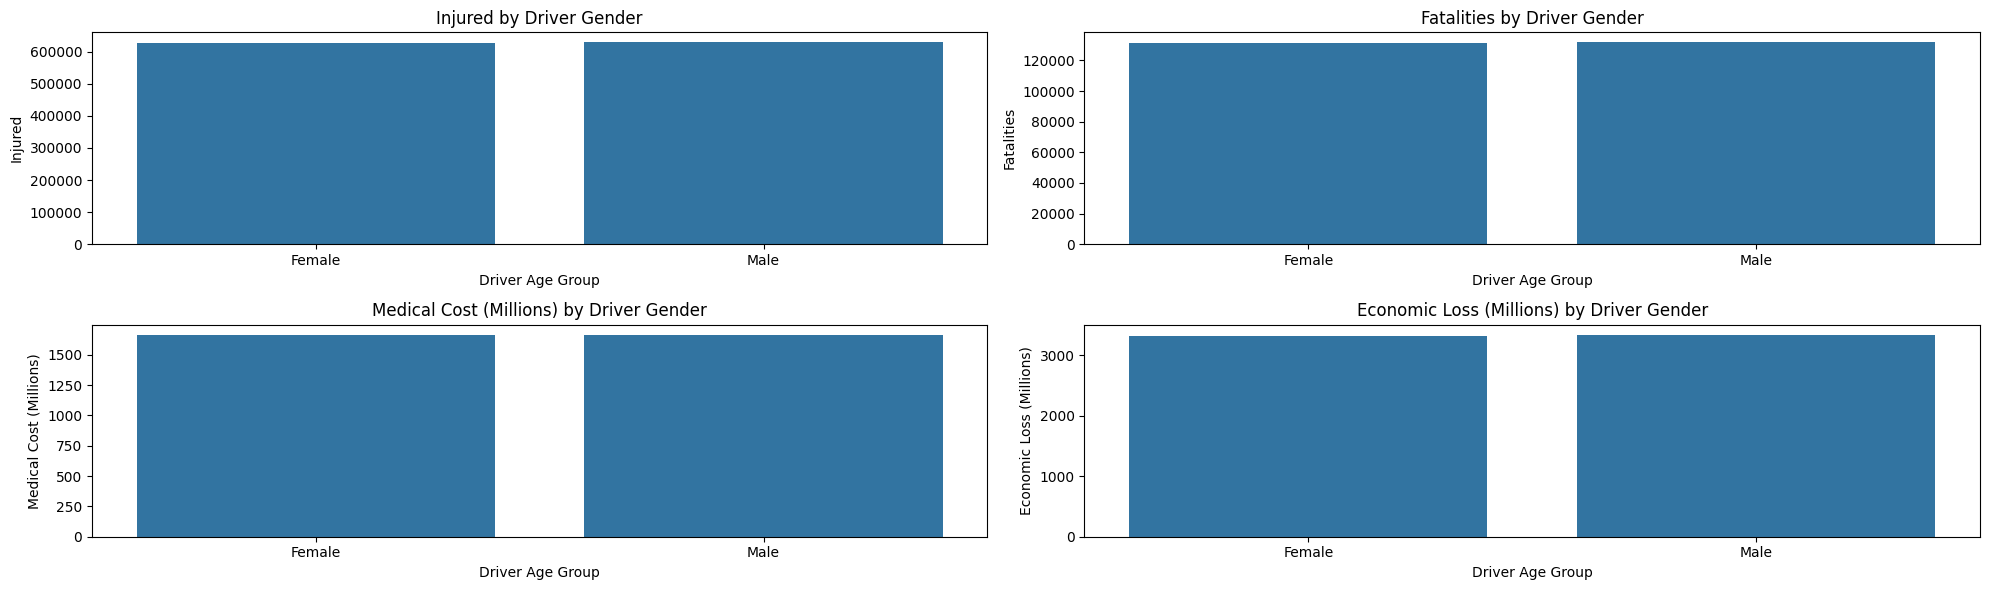

In [41]:
# Group the data

impact_Metrics_by_drivergender = data.groupby(['Driver Gender']).agg(
    injured=("Number of Injuries", "sum"),
    fatalities=("Number of Fatalities", "sum"),
    medical_cost=("Medical Cost", "sum"),
    economic_loss=("Economic Loss", "sum")).reset_index()

# Convert cost values to millions
impact_Metrics_by_drivergender['Medical Cost (Millions)'] = impact_Metrics_by_drivergender['medical_cost'] / 1_000_000
impact_Metrics_by_drivergender['Economic Loss (Millions)'] = impact_Metrics_by_drivergender['economic_loss'] / 1_000_000

# Columns to plot:
plot_columns= ["injured", "fatalities", "Medical Cost (Millions)", "Economic Loss (Millions)"]

# Plot
nrows, ncols= 2,2
plt.figure(figsize=(nrows* 10, ncols*3))

for i, j in enumerate(plot_columns):
    plt.subplot(nrows, ncols, i+1)
    sns.barplot(data=impact_Metrics_by_drivergender, x='Driver Gender', y=j)
    
    plt.title(f"{j.replace("_", " ").title()} by Driver Gender")
    plt.xlabel("Driver Age Group")
    plt.ylabel(f"{j.replace("_", " ").title()}")

plt.tight_layout()
plt.show()

#### **5.3 Driver Fatigue and Impact Metrics**

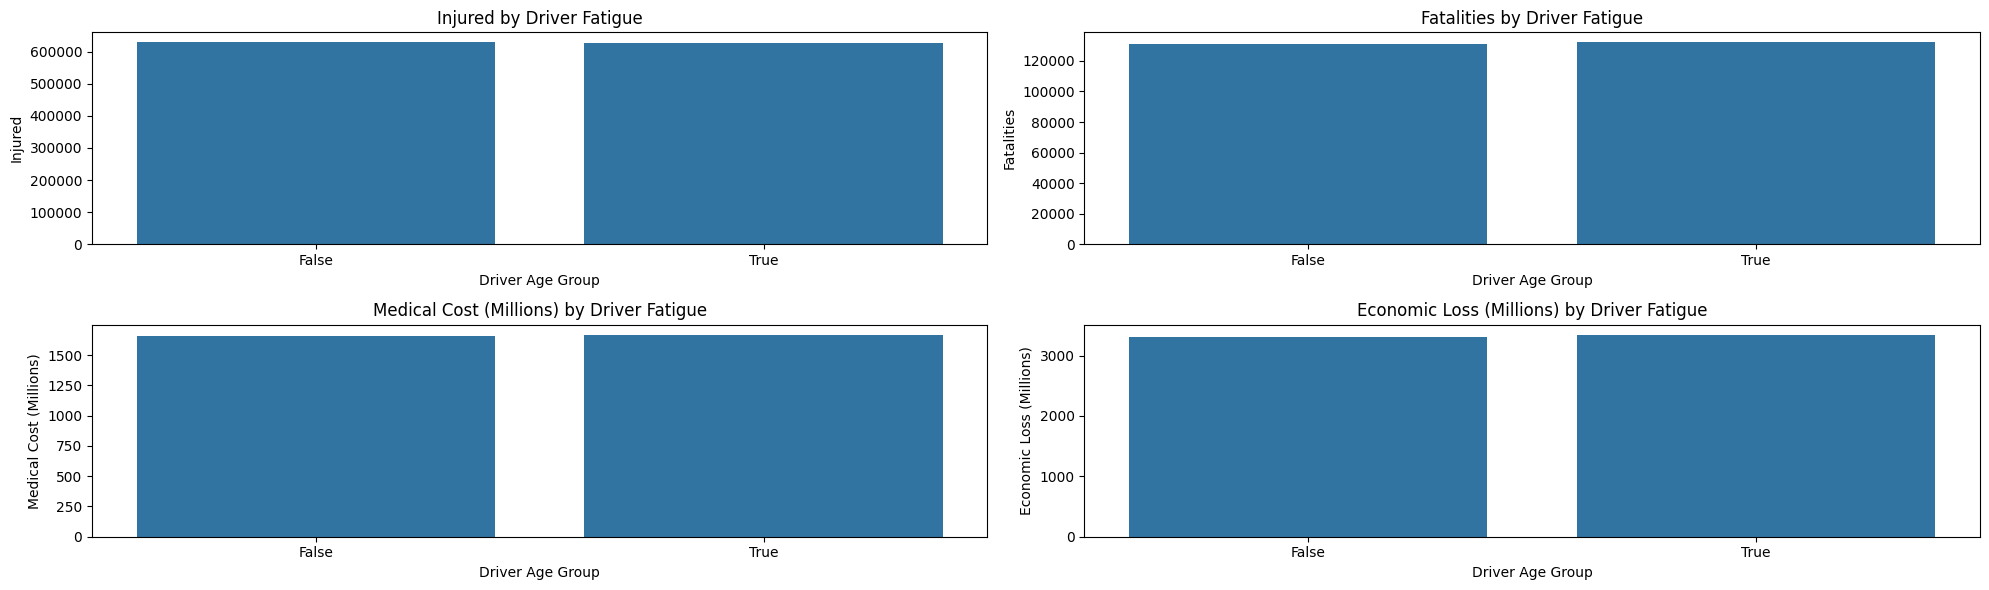

In [42]:
# Group the data

impact_Metrics_by_driverfatigue = data.groupby(['Driver Fatigue']).agg(
    injured=("Number of Injuries", "sum"),
    fatalities=("Number of Fatalities", "sum"),
    medical_cost=("Medical Cost", "sum"),
    economic_loss=("Economic Loss", "sum")).reset_index()

# Convert cost values to millions
impact_Metrics_by_driverfatigue['Medical Cost (Millions)'] = impact_Metrics_by_driverfatigue['medical_cost'] / 1_000_000
impact_Metrics_by_driverfatigue['Economic Loss (Millions)'] = impact_Metrics_by_driverfatigue['economic_loss'] / 1_000_000

# Columns to plot:
plot_columns= ["injured", "fatalities", "Medical Cost (Millions)", "Economic Loss (Millions)"]

# Plot
nrows, ncols= 2,2
plt.figure(figsize=(nrows* 10, ncols*3))

for i, j in enumerate(plot_columns):
    plt.subplot(nrows, ncols, i+1)
    sns.barplot(data=impact_Metrics_by_driverfatigue, x='Driver Fatigue', y=j)
    
    plt.title(f"{j.replace("_", " ").title()} by Driver Fatigue")
    plt.xlabel("Driver Age Group")
    plt.ylabel(f"{j.replace("_", " ").title()}")

plt.tight_layout()
plt.show()

#### **5.4 Driver Alcohol Levels and Impact Metrics**

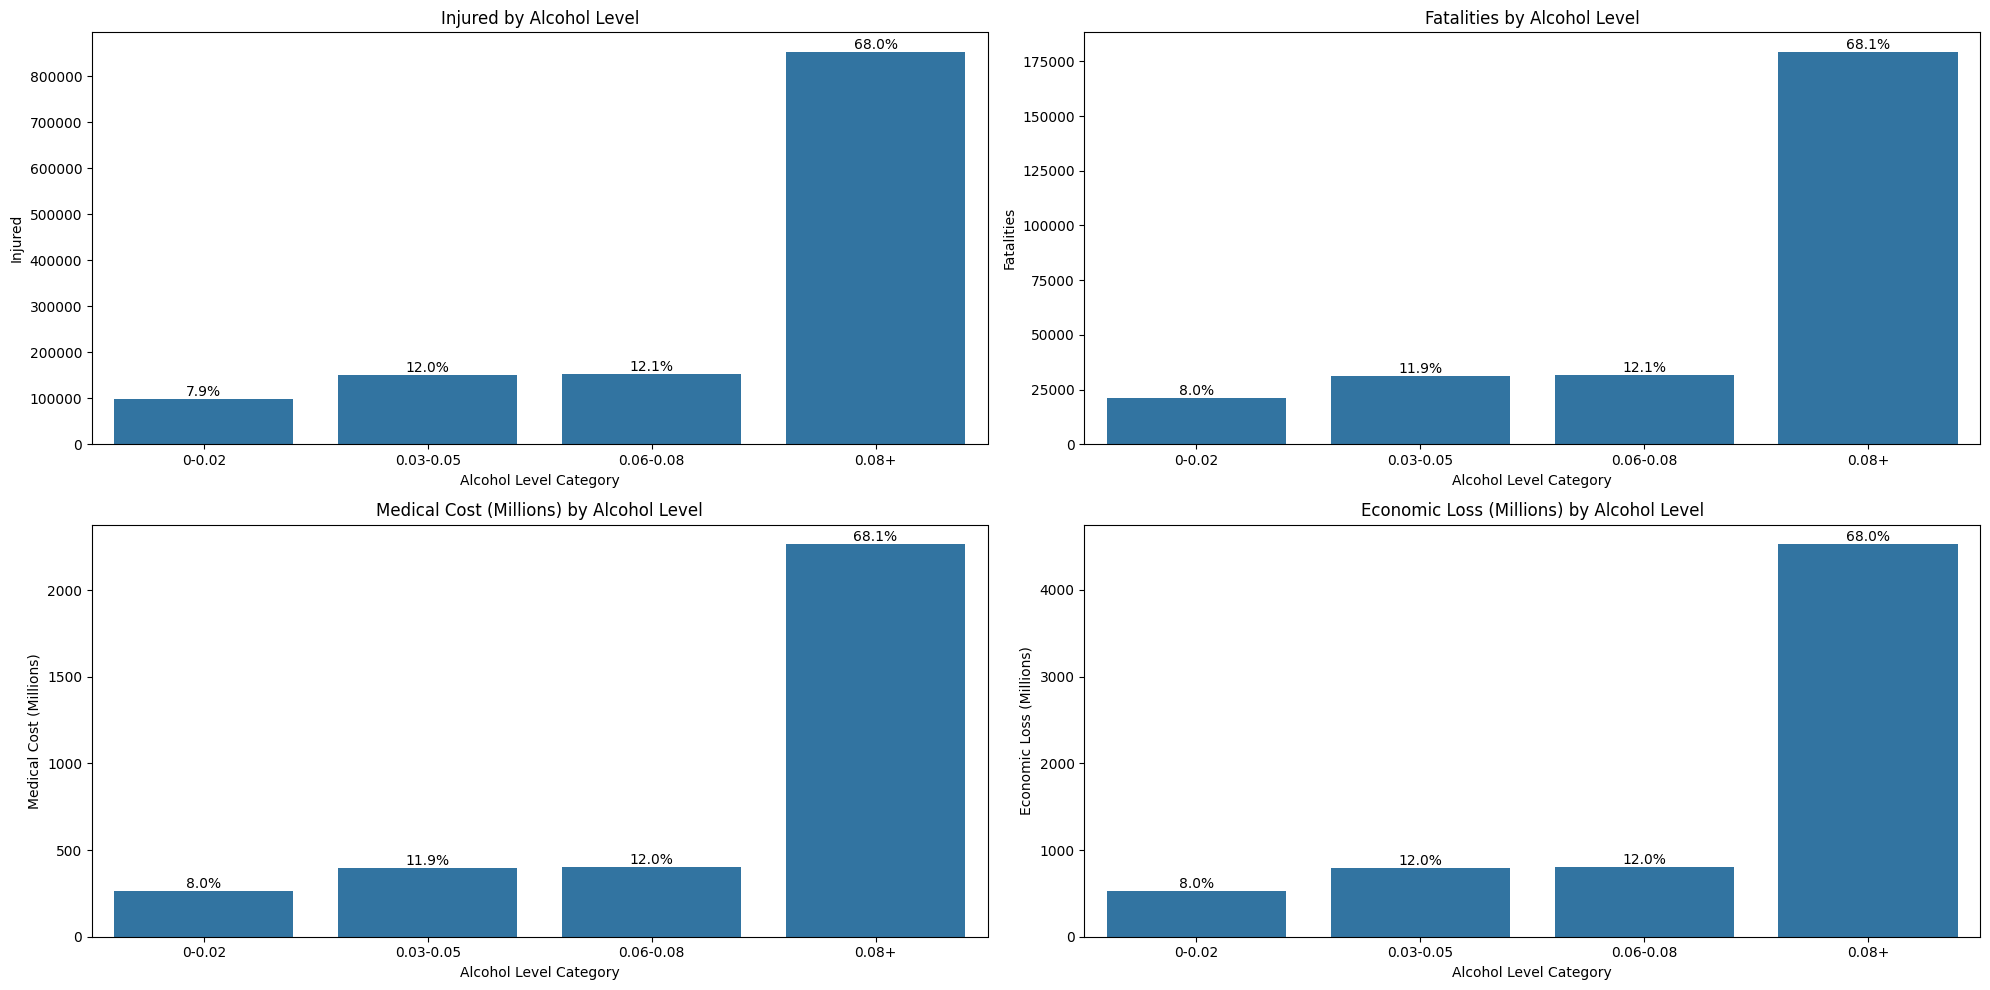

In [43]:
# Binning Alcohol Levels as per standards
bins = [-1, 0.02, 0.05, 0.08, np.inf] 
labels = ["0-0.02", "0.03-0.05", "0.06-0.08", "0.08+"]

# New column
data['Alcohol Level Category'] = pd.cut(data['Driver Alcohol Level'], bins=bins, labels=labels)

impact_Metrics_by_alcohollevel = data.groupby(['Alcohol Level Category'], observed=False).agg(
    injured=("Number of Injuries", "sum"),
    fatalities=("Number of Fatalities", "sum"),
    medical_cost=("Medical Cost", "sum"),
    economic_loss=("Economic Loss", "sum")).reset_index()

# Convert cost values to millions
impact_Metrics_by_alcohollevel['Medical Cost (Millions)'] = impact_Metrics_by_alcohollevel['medical_cost'] / 1_000_000
impact_Metrics_by_alcohollevel['Economic Loss (Millions)'] = impact_Metrics_by_alcohollevel['economic_loss'] / 1_000_000

# Plot
plot_columns = ["injured", "fatalities", "Medical Cost (Millions)", "Economic Loss (Millions)"]
nrows, ncols = 2, 2
plt.figure(figsize=(ncols * 10, nrows * 5))

for i, j in enumerate(plot_columns):
    plt.subplot(nrows, ncols, i+1)
    a= sns.barplot(data=impact_Metrics_by_alcohollevel, x='Alcohol Level Category', y=j)
    
    plt.title(f"{j.title()} by Alcohol Level")
    plt.xlabel("Alcohol Level Category")
    plt.ylabel(j.title())
    
    total = impact_Metrics_by_alcohollevel[j].sum()

    for i in a.patches:
        height = i.get_height()
        percentage = (height / total) * 100 if total > 0 else 0  # Avoid division by zero
        a.annotate(f'{percentage:.1f}%',  
                    (i.get_x() + i.get_width() / 2., height),  
                    ha='center', va='bottom',  
                    fontsize=10, color='black')
plt.tight_layout()
plt.show()

#### **5.5 Vehicle Condition and Impact Metrics**

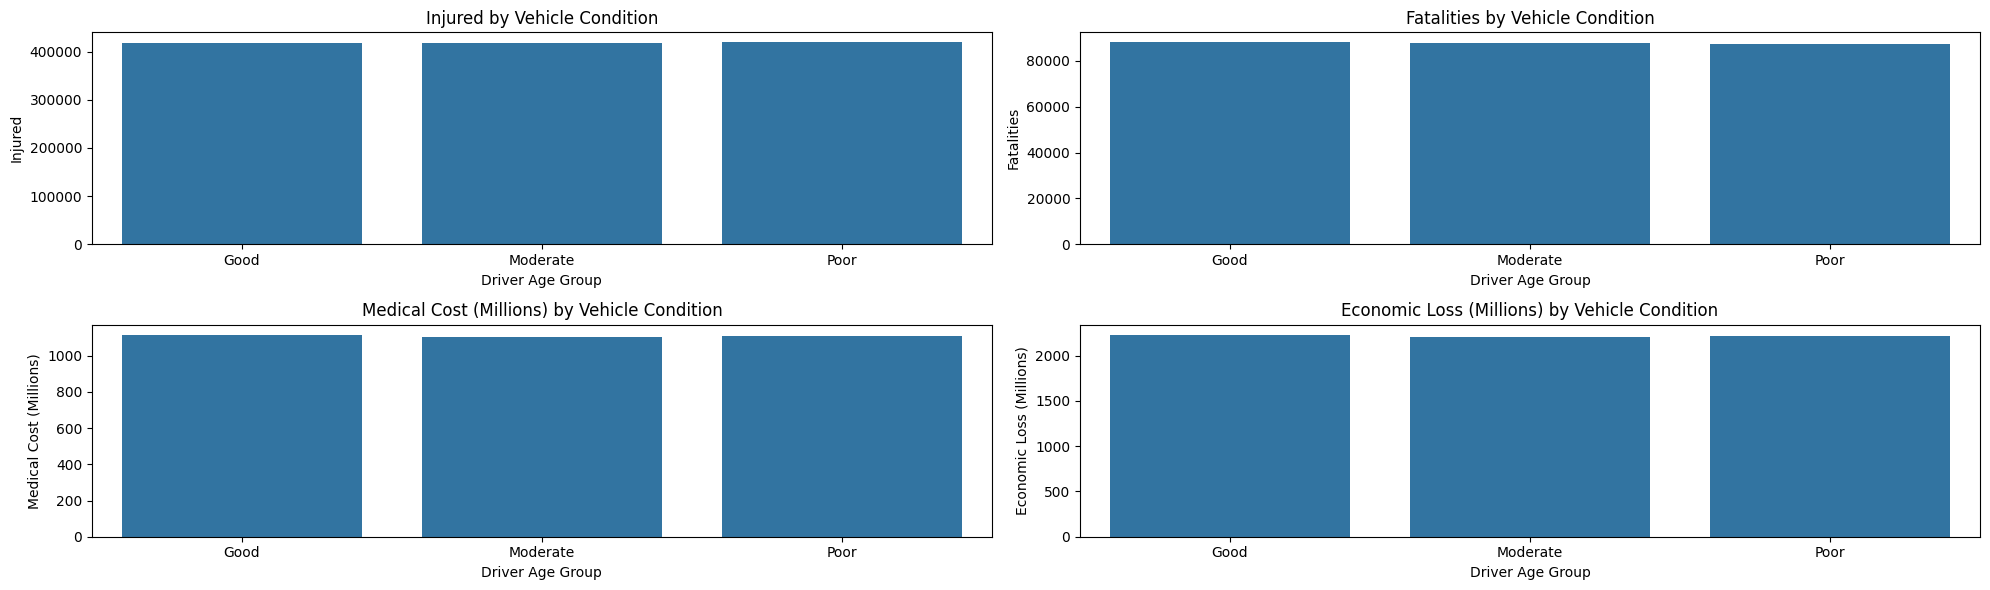

In [44]:
# Group the data
impact_Metrics_by_vehiclecondition = data.groupby(['Vehicle Condition']).agg(
    injured=("Number of Injuries", "sum"),
    fatalities=("Number of Fatalities", "sum"),
    medical_cost=("Medical Cost", "sum"),
    economic_loss=("Economic Loss", "sum")).reset_index()

# Convert cost values to millions
impact_Metrics_by_vehiclecondition['Medical Cost (Millions)'] = impact_Metrics_by_vehiclecondition['medical_cost'] / 1_000_000
impact_Metrics_by_vehiclecondition['Economic Loss (Millions)'] = impact_Metrics_by_vehiclecondition['economic_loss'] / 1_000_000

# Columns to plot:
plot_columns= ["injured", "fatalities", "Medical Cost (Millions)", "Economic Loss (Millions)"]

# Plot
nrows, ncols= 2,2
plt.figure(figsize=(nrows* 10, ncols*3))

for i, j in enumerate(plot_columns):
    plt.subplot(nrows, ncols, i+1)
    sns.barplot(data=impact_Metrics_by_vehiclecondition, x='Vehicle Condition', y=j)
    
    plt.title(f"{j.replace("_", " ").title()} by Vehicle Condition")
    plt.xlabel("Driver Age Group")
    plt.ylabel(f"{j.replace("_", " ").title()}")

plt.tight_layout()
plt.show()

### **5.6 Accident Severity and Vehicles Involved by Alcohol Level Category**

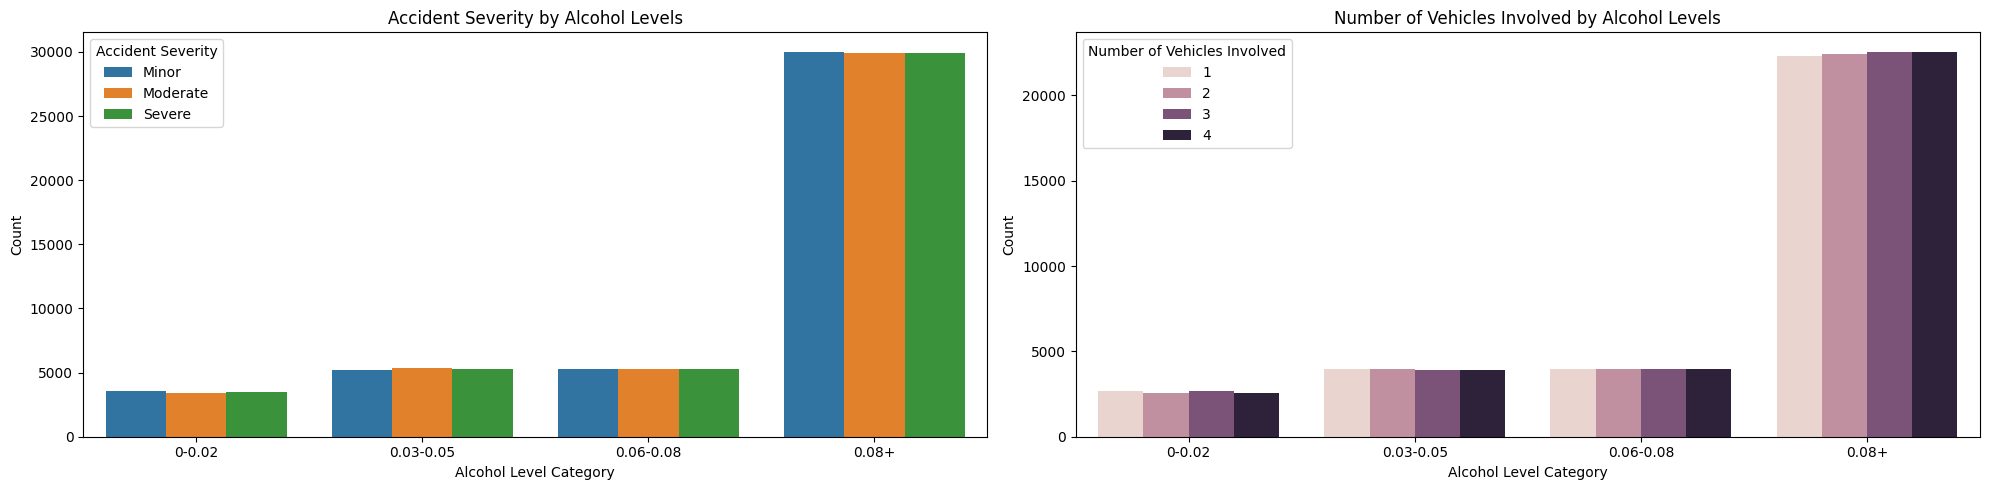

In [45]:
# Group data
accident_severity_by_alcoholcategory= data.groupby(['Alcohol Level Category', 'Accident Severity']).size().reset_index(name= 'Count')
vehicles_involved_by_alcoholcategory= data.groupby(['Alcohol Level Category', 'Number of Vehicles Involved']).size().reset_index(name= 'Count')

#Plots
plt.figure(figsize=(20, 5))

# 1. Accident Severity 
plt.subplot(1, 2, 1)
sns.barplot(data=accident_severity_by_alcoholcategory, x="Alcohol Level Category", y='Count', hue= 'Accident Severity')
plt.title("Accident Severity by Alcohol Levels")

# 2. Number of Vehicles Involved
plt.subplot(1, 2, 2)
sns.barplot(data=vehicles_involved_by_alcoholcategory, x="Alcohol Level Category", y='Count', hue= 'Number of Vehicles Involved')
plt.title("Number of Vehicles Involved by Alcohol Levels")

plt.tight_layout()
plt.show()

## **6. Environmental and Road Conditions**

In [46]:
road_condition_factors= ['Road Type', 'Traffic Volume', 'Road Condition']
environment_factors= ['Weather Conditions', 'Visibility Level']

#### **6.1 Impact Metrics by Road Type**

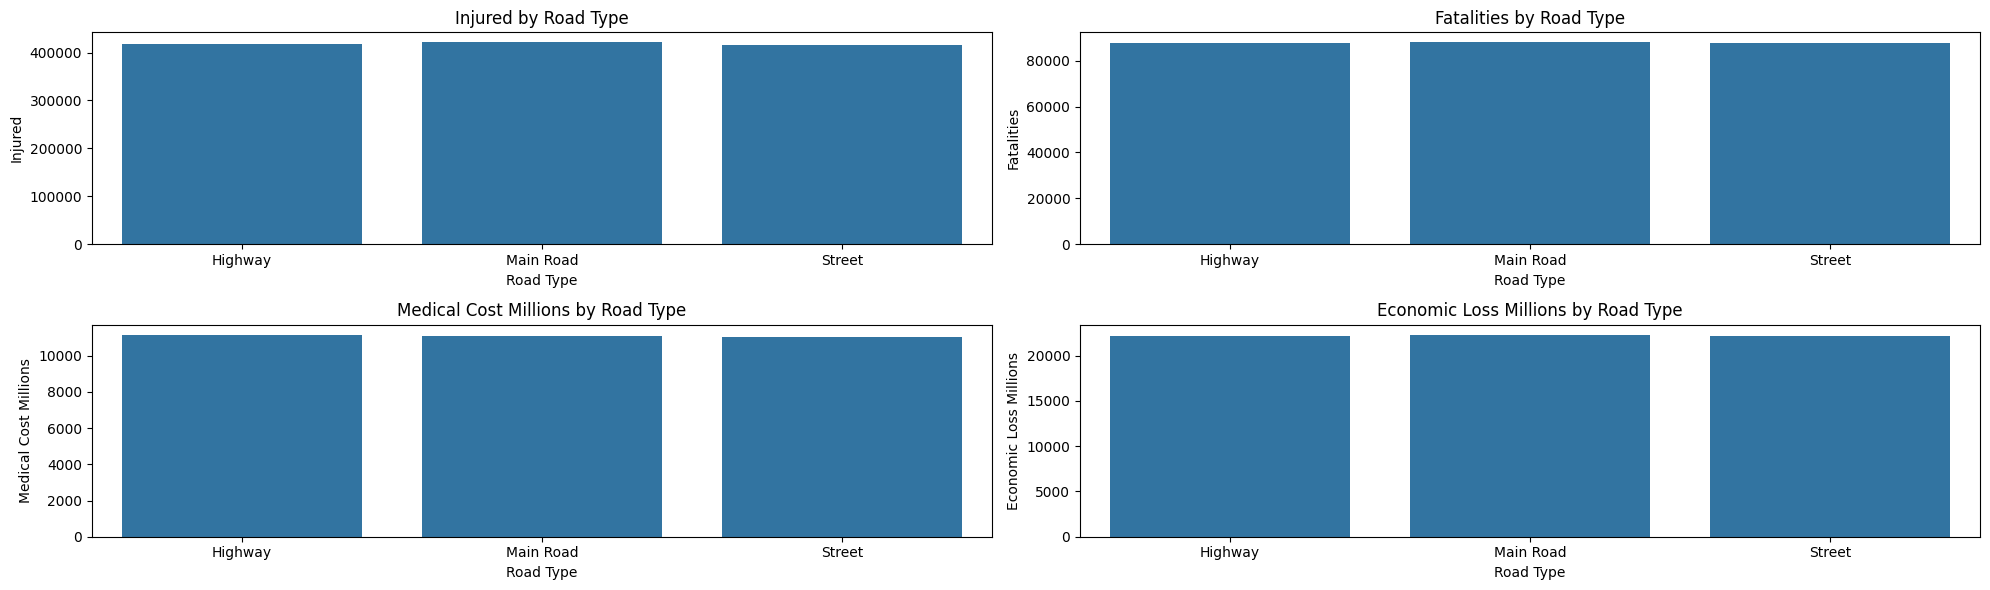

In [47]:
impact_Metrics_by_roadtype= data.groupby('Road Type').agg(
    Injured= ("Number of Injuries", 'sum'),
    Fatalities= ("Number of Fatalities", 'sum'),
    Medical_Cost= ("Medical Cost", 'sum'),
    Economic_Loss= ("Economic Loss", 'sum')).reset_index()

# Convert large values into millions
impact_Metrics_by_roadtype['Medical_Cost_Millions']= impact_Metrics_by_roadtype["Medical_Cost"] / 1_00_000
impact_Metrics_by_roadtype['Economic_Loss_Millions']= impact_Metrics_by_roadtype["Economic_Loss"] / 1_00_000


# Columns to plot:
plot_columns= ["Injured", "Fatalities", "Medical_Cost_Millions", "Economic_Loss_Millions"]

# Plot
nrows, ncols= 2,2
plt.figure(figsize=(nrows* 10, ncols*3))

for i, j in enumerate(plot_columns):
    plt.subplot(nrows, ncols, i+1)
    sns.barplot(data=impact_Metrics_by_roadtype, x='Road Type', y=j)
    
    plt.title(f"{j.replace("_", " ").title()} by Road Type")
    plt.xlabel("Road Type")
    plt.ylabel(f"{j.replace("_", " ").title()}")

plt.tight_layout()
plt.show()

#### **6.2 Impact Metrics by Road Condition**

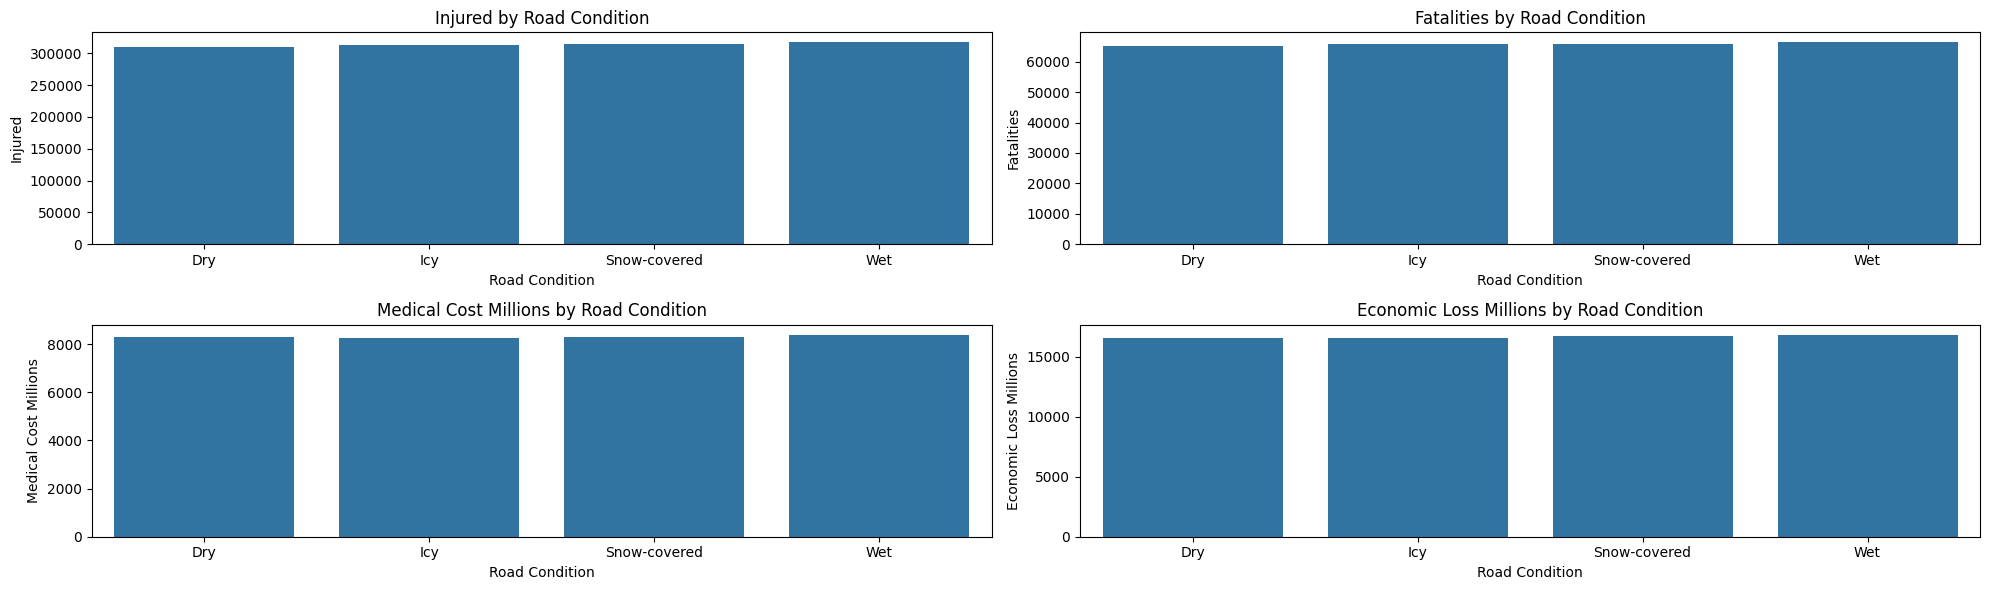

In [48]:
impact_Metrics_by_roadcondition= data.groupby('Road Condition').agg(
    Injured= ("Number of Injuries", 'sum'),
    Fatalities= ("Number of Fatalities", 'sum'),
    Medical_Cost= ("Medical Cost", 'sum'),
    Economic_Loss= ("Economic Loss", 'sum')).reset_index()

# Convert large values into millions
impact_Metrics_by_roadcondition['Medical_Cost_Millions']= impact_Metrics_by_roadcondition["Medical_Cost"] / 1_00_000
impact_Metrics_by_roadcondition['Economic_Loss_Millions']= impact_Metrics_by_roadcondition["Economic_Loss"] / 1_00_000


# Columns to plot:
plot_columns= ["Injured", "Fatalities", "Medical_Cost_Millions", "Economic_Loss_Millions"]

# Plot
nrows, ncols= 2,2
plt.figure(figsize=(nrows* 10, ncols*3))

for i, j in enumerate(plot_columns):
    plt.subplot(nrows, ncols, i+1)
    sns.barplot(data=impact_Metrics_by_roadcondition, x='Road Condition', y=j)
    
    plt.title(f"{j.replace("_", " ").title()} by Road Condition")
    plt.xlabel("Road Condition")
    plt.ylabel(f"{j.replace("_", " ").title()}")

plt.tight_layout()
plt.show()

#### **6.3 Impact Metrics by Weather Condition**

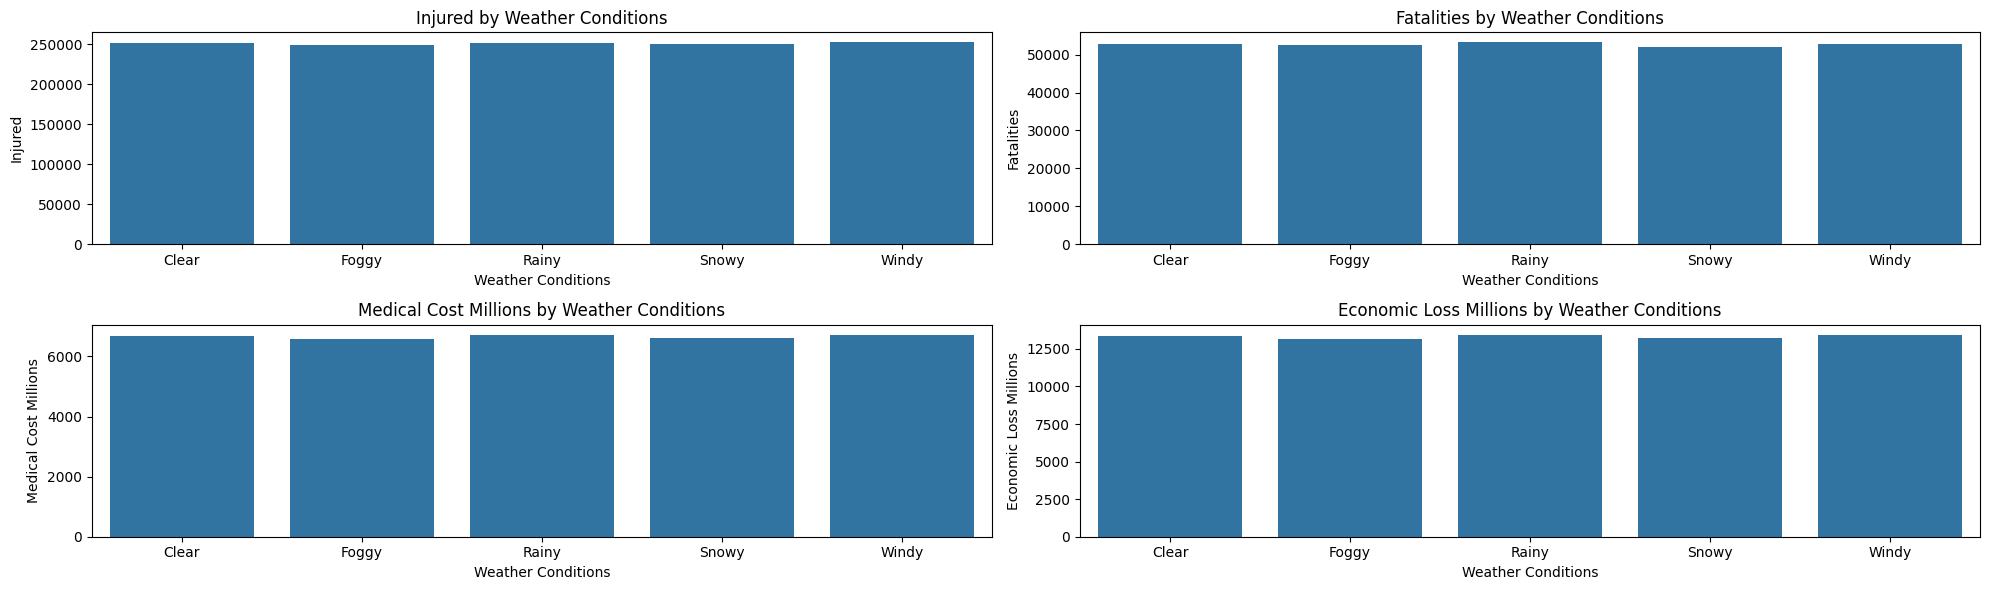

In [49]:
impact_Metrics_by_weathercondition= data.groupby('Weather Conditions').agg(
    Injured= ("Number of Injuries", 'sum'),
    Fatalities= ("Number of Fatalities", 'sum'),
    Medical_Cost= ("Medical Cost", 'sum'),
    Economic_Loss= ("Economic Loss", 'sum')).reset_index()

# Convert large values into millions
impact_Metrics_by_weathercondition['Medical_Cost_Millions']= impact_Metrics_by_weathercondition["Medical_Cost"] / 1_00_000
impact_Metrics_by_weathercondition['Economic_Loss_Millions']= impact_Metrics_by_weathercondition["Economic_Loss"] / 1_00_000


# Columns to plot:
plot_columns= ["Injured", "Fatalities", "Medical_Cost_Millions", "Economic_Loss_Millions"]

# Plot
nrows, ncols= 2,2
plt.figure(figsize=(nrows* 10, ncols*3))

for i, j in enumerate(plot_columns):
    plt.subplot(nrows, ncols, i+1)
    sns.barplot(data=impact_Metrics_by_weathercondition, x='Weather Conditions', y=j)
    
    plt.title(f"{j.replace("_", " ").title()} by Weather Conditions")
    plt.xlabel("Weather Conditions")
    plt.ylabel(f"{j.replace("_", " ").title()}")

plt.tight_layout()
plt.show()

#### **6.4 Impact Metrics by Visibility**

In [50]:
# Create bins
bins = [0, 100, 200, 300, 400, 500]  
labels = ["Severely Low", "Low", "Moderate", "Good", "Excellent"]

# Create Visibility Category column
data['Visibility Category'] = pd.cut(data['Visibility Level'], bins=bins, labels=labels, right=False)

In [51]:
# Group data
impact_Metrics_by_visibility= data.groupby('Visibility Category').agg(
    Injured= ("Number of Injuries", 'sum'),
    Fatalities= ("Number of Fatalities", 'sum'),
    Medical_Cost= ("Medical Cost", 'sum'),
    Economic_Loss= ("Economic Loss", 'sum')).reset_index()

# Convert large values into millions
impact_Metrics_by_visibility['Medical_Cost_Millions']= impact_Metrics_by_visibility["Medical_Cost"] / 1_00_000
impact_Metrics_by_visibility['Economic_Loss_Millions']= impact_Metrics_by_visibility["Economic_Loss"] / 1_00_000

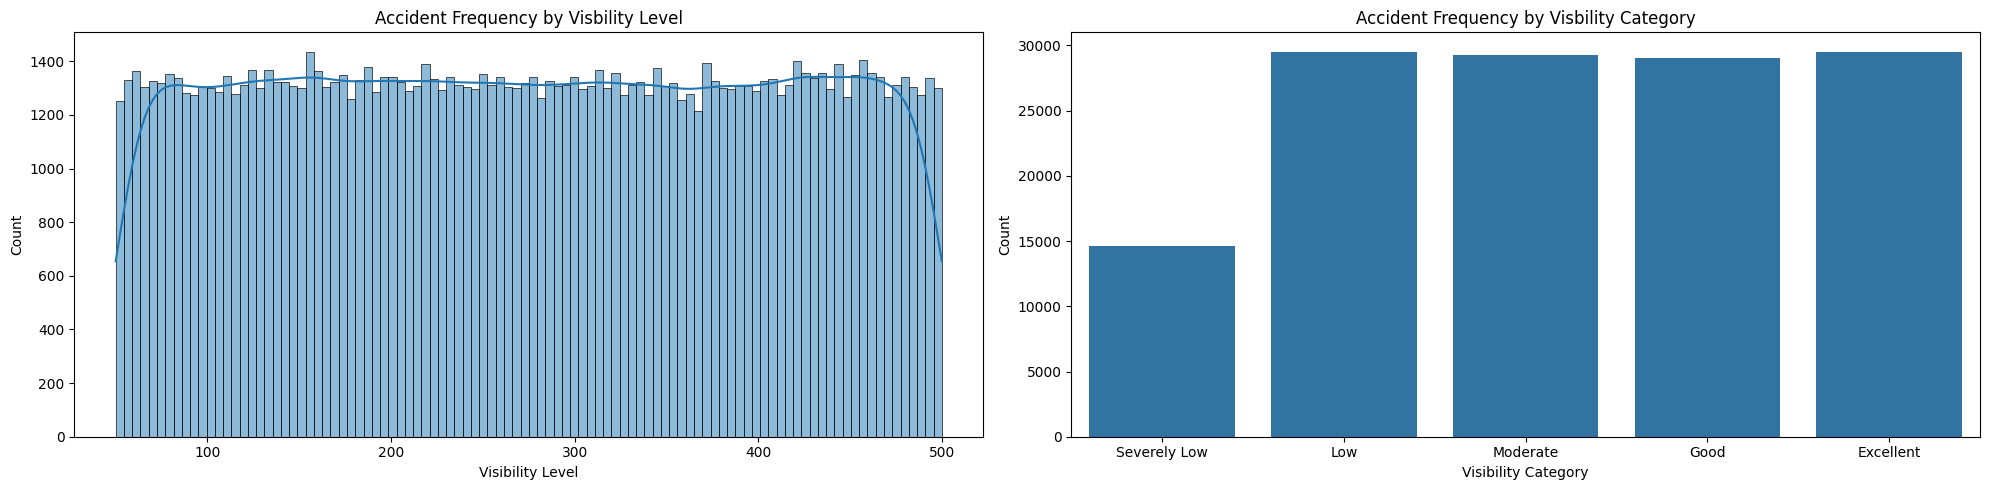

In [52]:
# Accidents Frequency distribution by Visibility Level

plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=data, x= 'Visibility Level', bins= 100, kde=True)
plt.title("Accident Frequency by Visbility Level")

plt.subplot(1, 2, 2)
visibility_categories= data['Visibility Category'].value_counts().reset_index(name= 'Count')
visibility_order = ["Severely Low", "Low", "Moderate", "Good", "Excellent"]
sns.barplot(x= visibility_categories['Visibility Category'], y= visibility_categories['Count'], order= visibility_order)
plt.title("Accident Frequency by Visbility Category")

plt.tight_layout()
plt.show()

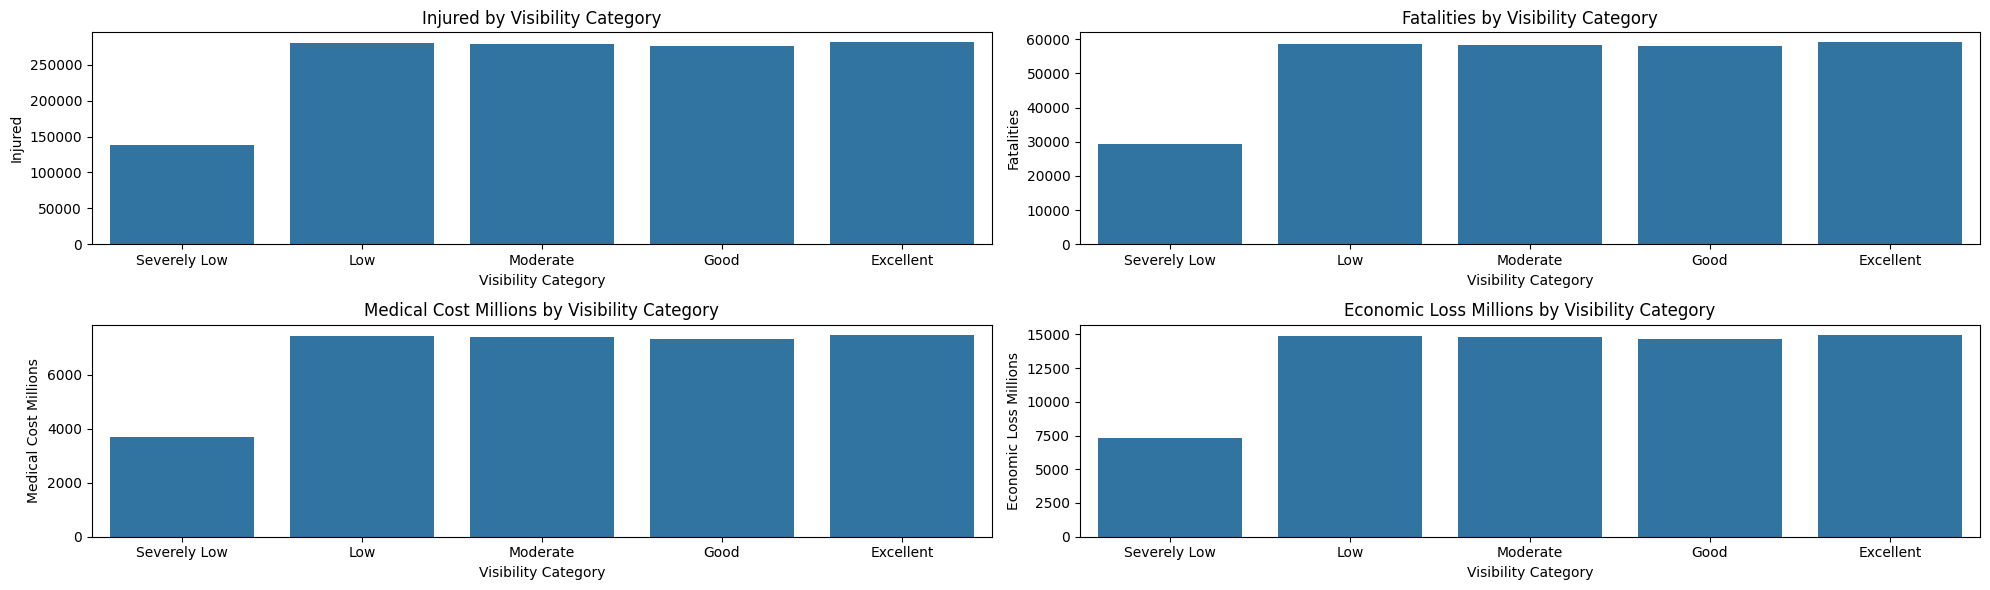

In [53]:
# Columns to plot:
plot_columns= ["Injured", "Fatalities", "Medical_Cost_Millions", "Economic_Loss_Millions"]

# Plot
nrows, ncols= 2,2
plt.figure(figsize=(nrows* 10, ncols*3))

for i, j in enumerate(plot_columns):
    plt.subplot(nrows, ncols, i+1)
    sns.barplot(data=impact_Metrics_by_visibility, x='Visibility Category', y=j)
    
    plt.title(f"{j.replace("_", " ").title()} by Visibility Category")
    plt.xlabel("Visibility Category")
    plt.ylabel(f"{j.replace("_", " ").title()}")

plt.tight_layout()
plt.show()

#### **6.5 Impact Metrics by Traffic Volume**

In [54]:
# CReate bins
bins = [100, 2000, 4000, 6000, 8000, 10000]
labels = ["Very Low", "Low", "Moderate", "High", "Very High"]

# Create Categories
data['Traffic Volume Category'] = pd.cut(data['Traffic Volume'], bins=bins, labels=labels, right=False)

# Group data by Traffic Volume Category
impact_metrics_by_traffic = data.groupby('Traffic Volume Category').agg(
    Injured=("Number of Injuries", 'sum'),
    Fatalities=("Number of Fatalities", 'sum'),
    Medical_Cost=("Medical Cost", 'sum'),
    Economic_Loss=("Economic Loss", 'sum')).reset_index()

# Convert large values into millions
impact_metrics_by_traffic['Medical_Cost_Millions'] = impact_metrics_by_traffic["Medical_Cost"] / 1_00_000
impact_metrics_by_traffic['Economic_Loss_Millions'] = impact_metrics_by_traffic["Economic_Loss"] / 1_00_000

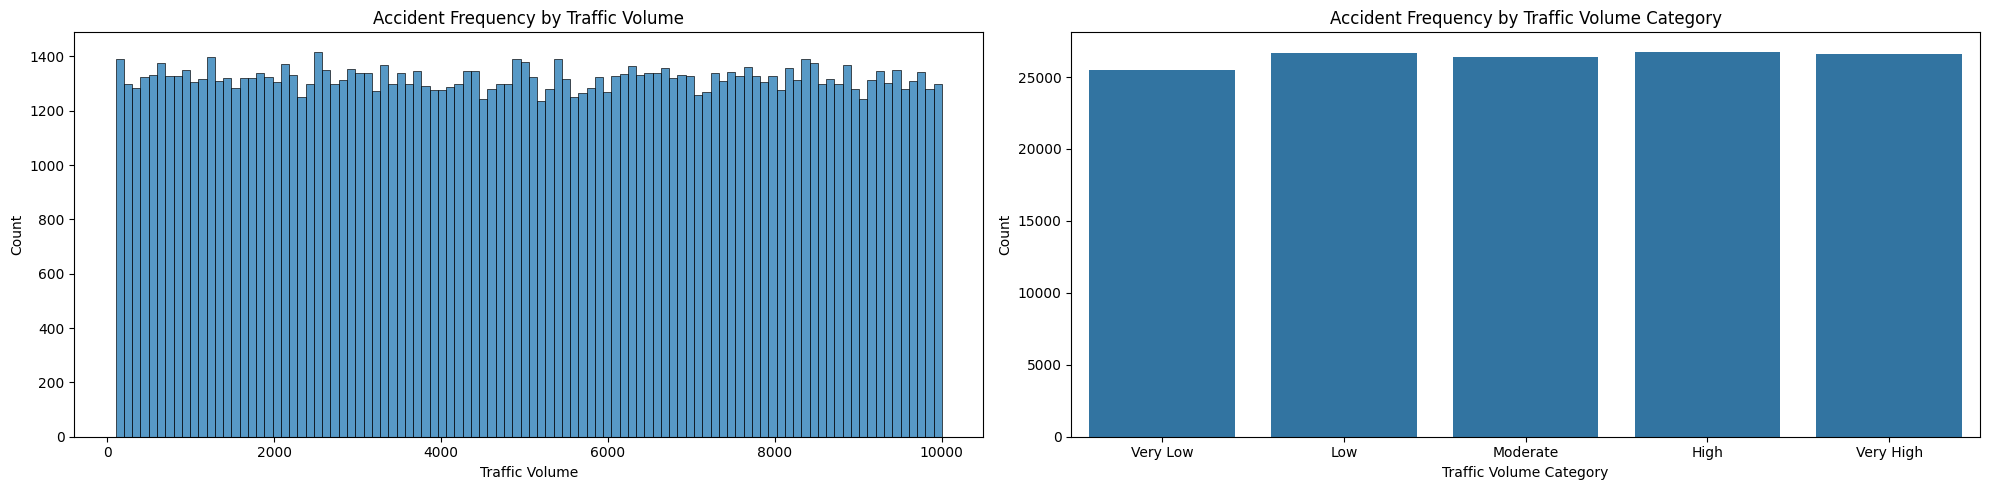

In [55]:
# Accident Frequency Distribution by Traffic Volume

plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=data, x='Traffic Volume', bins=100)
plt.title("Accident Frequency by Traffic Volume")

plt.subplot(1, 2, 2)
traffic_categories = data['Traffic Volume Category'].value_counts().reset_index(name='Count')
traffic_order = ["Very Low", "Low", "Moderate", "High", "Very High"]
sns.barplot(x=traffic_categories['Traffic Volume Category'], y=traffic_categories['Count'], order=traffic_order)
plt.title("Accident Frequency by Traffic Volume Category")

plt.tight_layout()
plt.show()

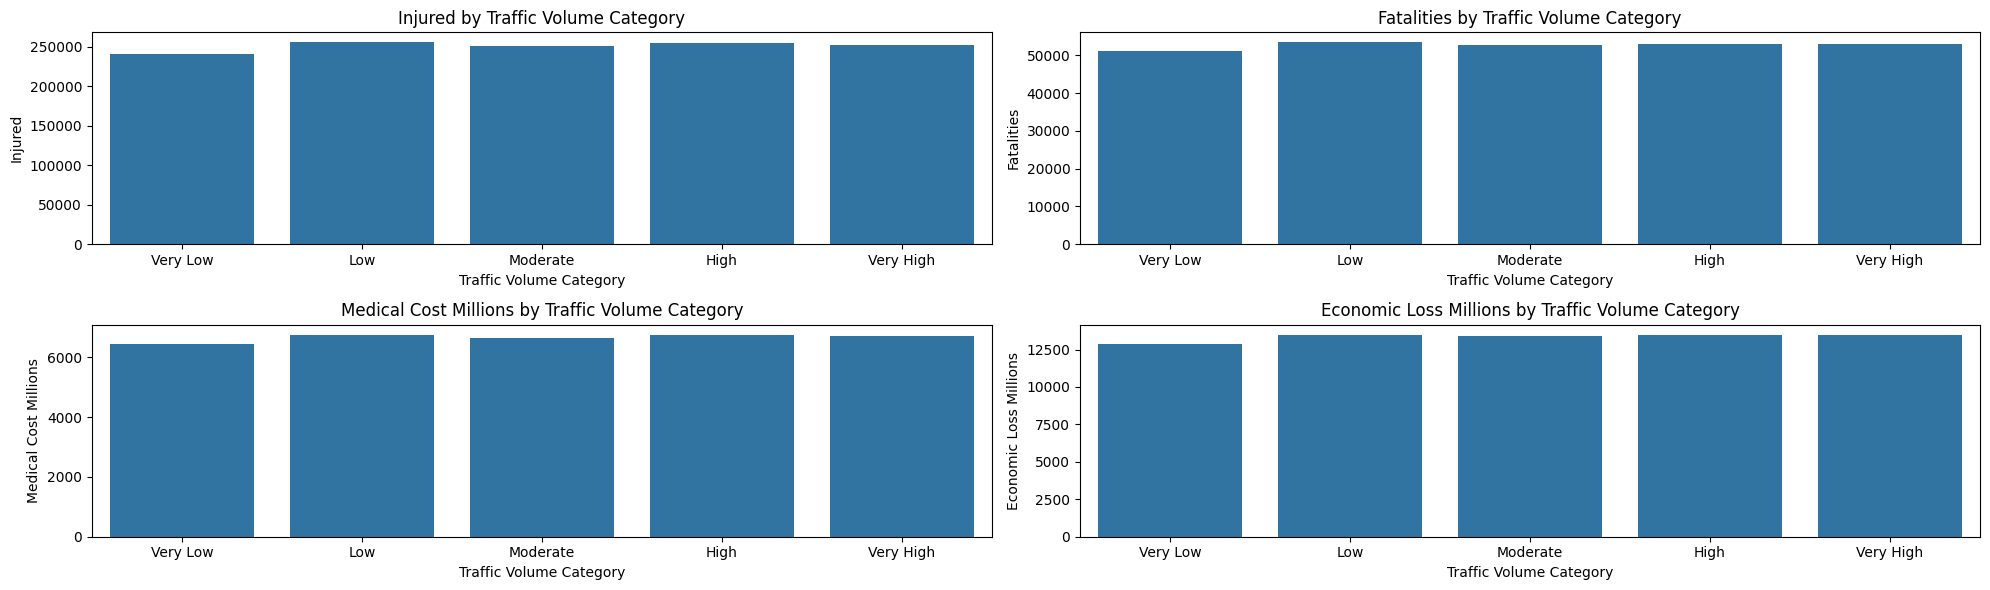

In [56]:
# Columns to plot
plot_columns = ["Injured", "Fatalities", "Medical_Cost_Millions", "Economic_Loss_Millions"]

# Plot
nrows, ncols = 2, 2
plt.figure(figsize=(nrows * 10, ncols * 3))

for i, j in enumerate(plot_columns):
    plt.subplot(nrows, ncols, i + 1)
    sns.barplot(data=impact_metrics_by_traffic, x='Traffic Volume Category', y=j)
    plt.title(f"{j.replace('_', ' ').title()} by Traffic Volume Category")
    plt.xlabel("Traffic Volume Category")
    plt.ylabel(f"{j.replace('_', ' ').title()}")

plt.tight_layout()
plt.show()

#### **6.6 Accident Severity by Environmental and Road Factors**

In [57]:
accident_severity_by_roadtype = data.groupby(['Accident Severity', 'Road Type']).size().reset_index(name= 'Count')
accident_severity_by_roadcondition = data.groupby(['Accident Severity', 'Road Condition']).size().reset_index(name= 'Count')
accident_severity_by_weather = data.groupby(['Accident Severity', 'Weather Conditions']).size().reset_index(name= 'Count')
accident_severity_by_traffic_cat = data.groupby(['Accident Severity', 'Traffic Volume Category']).size().reset_index(name= 'Count')
accident_severity_by_visibility = data.groupby(['Accident Severity', 'Visibility Category']).size().reset_index(name= 'Count')

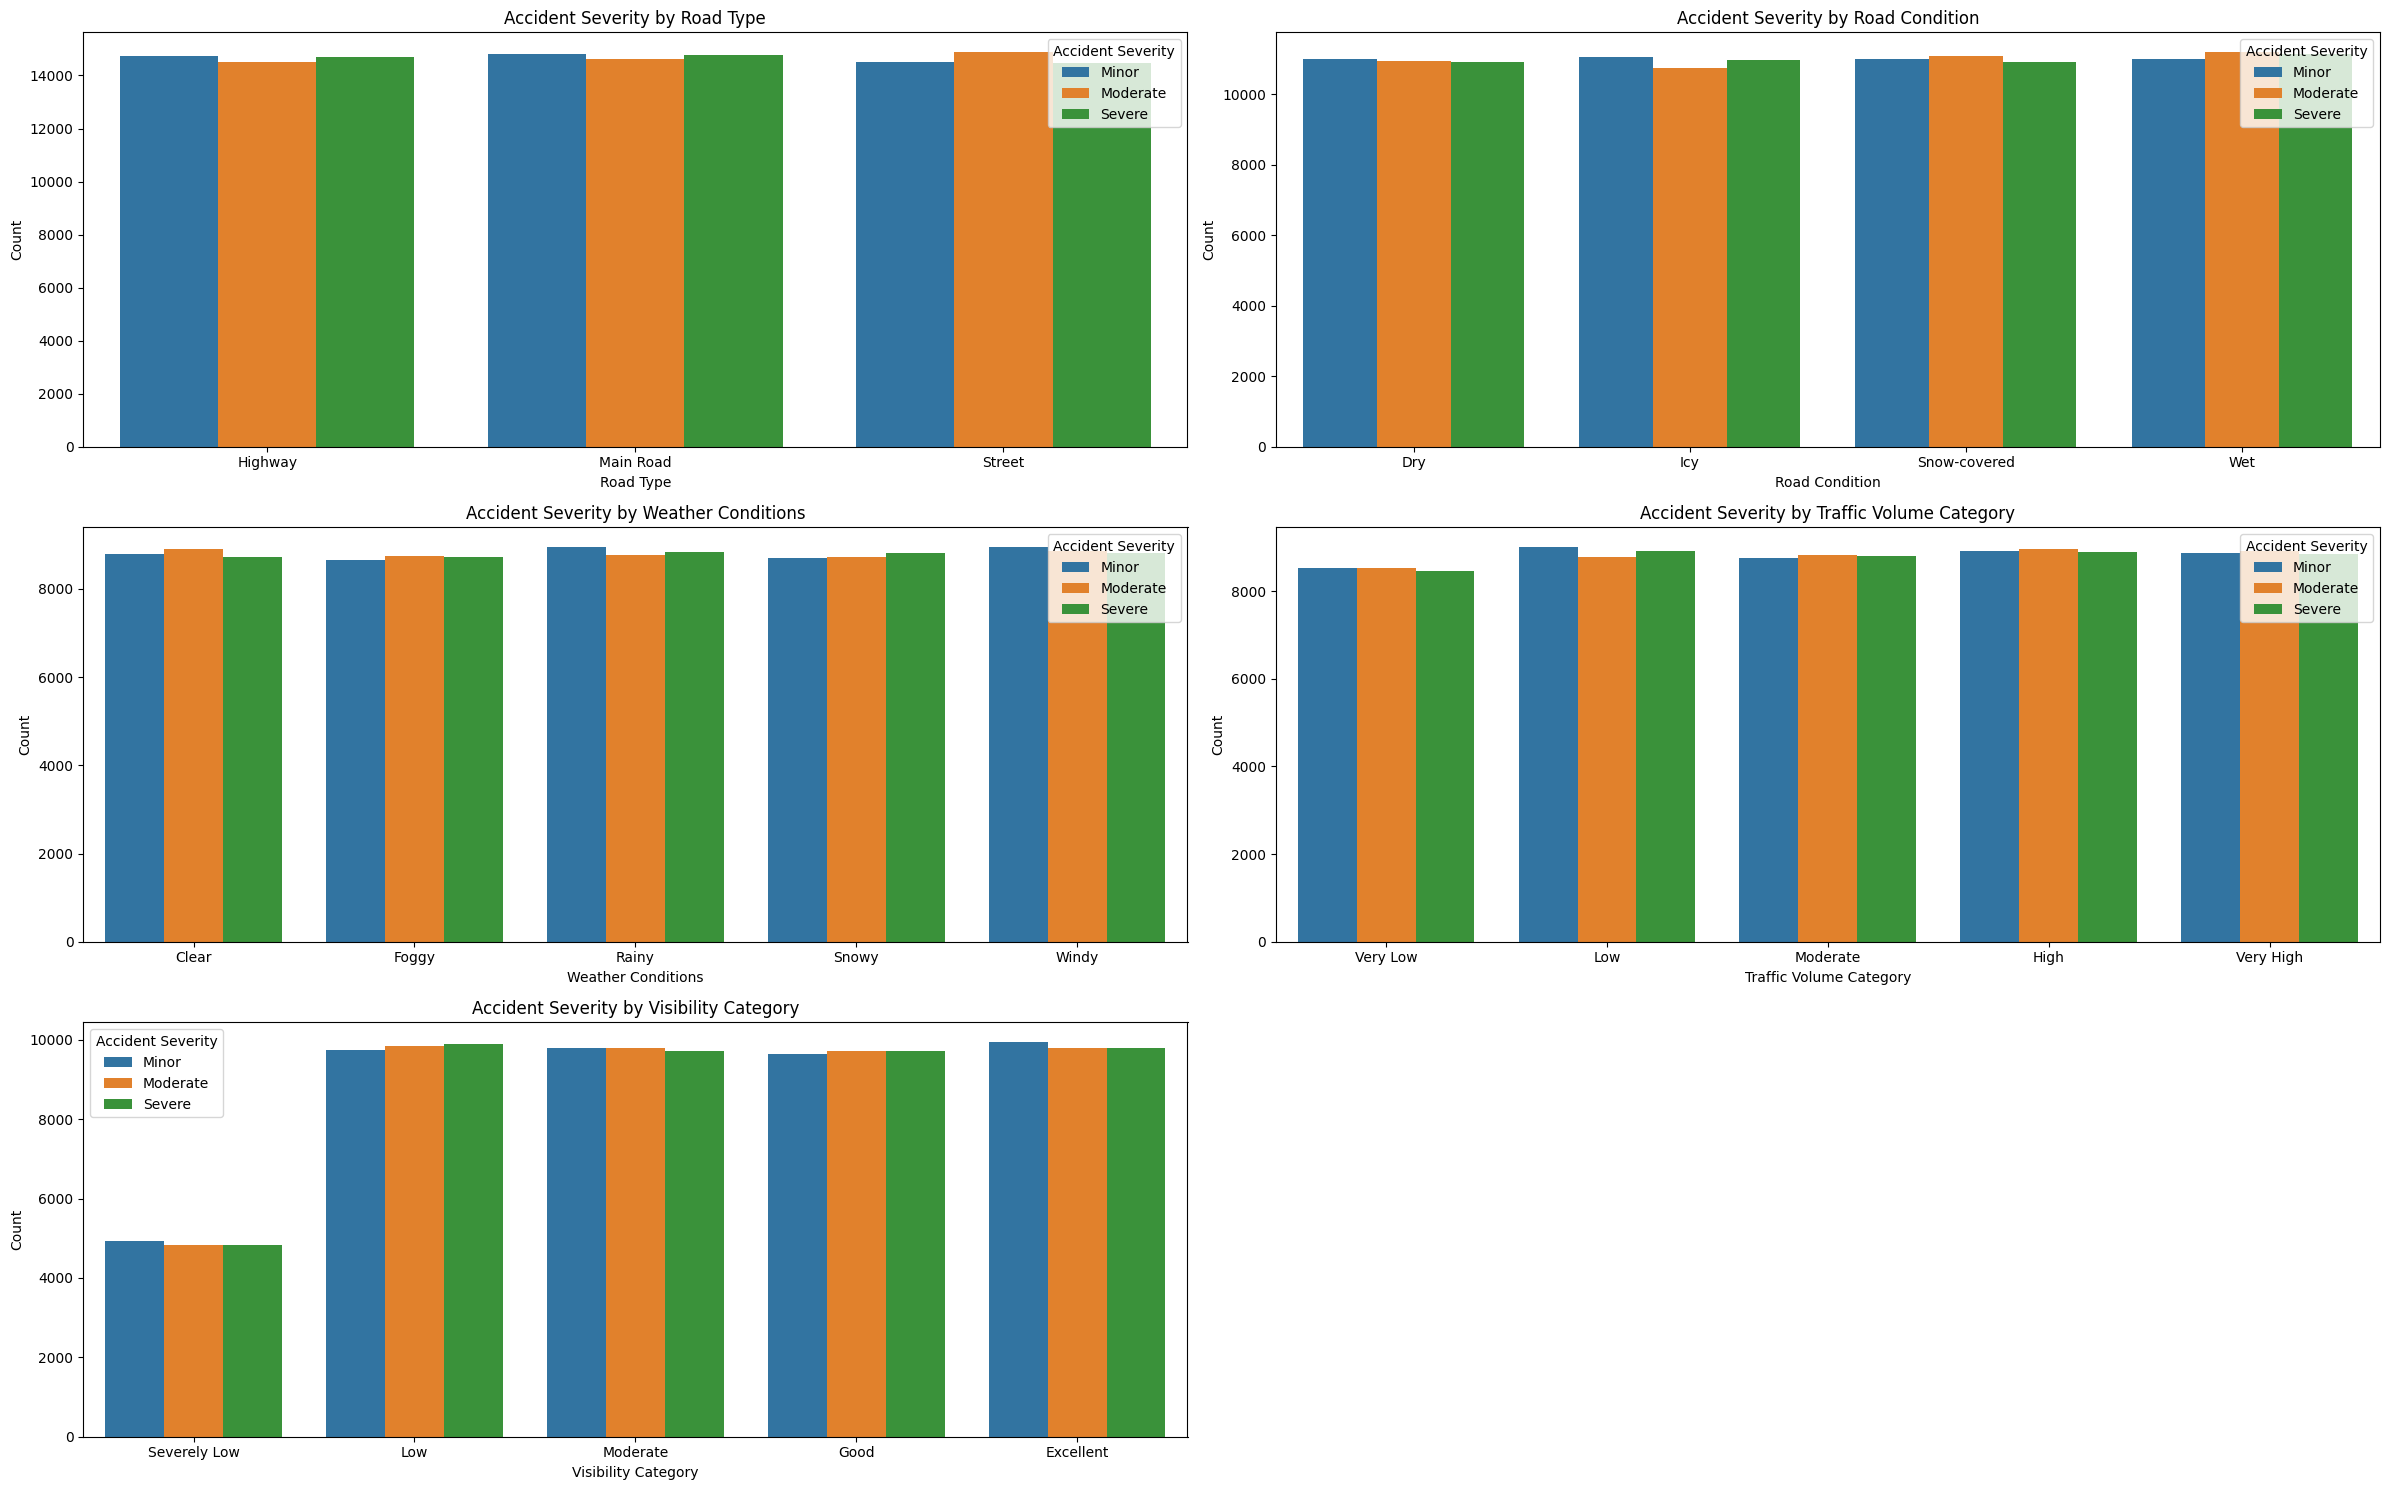

In [58]:
# For a change: Create function to avoid repeatative task
def plot_accident_severity(df, xcolumn):
    sns.barplot(data= df, x= xcolumn, y= 'Count', hue= 'Accident Severity')
    plt.title(f"Accident Severity by {xcolumn.title()}")
    plt.xlabel(xcolumn.title())
    plt.ylabel('Count')
    plt.legend(title= 'Accident Severity')

# Plots
plt.figure(figsize= (24, 15))

# 1. Accident Severity Vs Road Type 
plt.subplot(3, 2, 1)
plot_accident_severity(accident_severity_by_roadtype, 'Road Type')

# 2. Accident Severity Vs Road Condition
plt.subplot(3, 2, 2)
plot_accident_severity(accident_severity_by_roadcondition, 'Road Condition')

# 3. Accident Severity Vs Weather Conditions
plt.subplot(3, 2, 3)
plot_accident_severity(accident_severity_by_weather, 'Weather Conditions')

# 4. Accident Severity Vs Traffic Volume Category
plt.subplot(3, 2, 4)
plot_accident_severity(accident_severity_by_traffic_cat, 'Traffic Volume Category')

# 5. Accident Severity Vs Visibility Category
plt.subplot(3, 2, 5)
plot_accident_severity(accident_severity_by_visibility, 'Visibility Category')

plt.tight_layout()
plt.show()

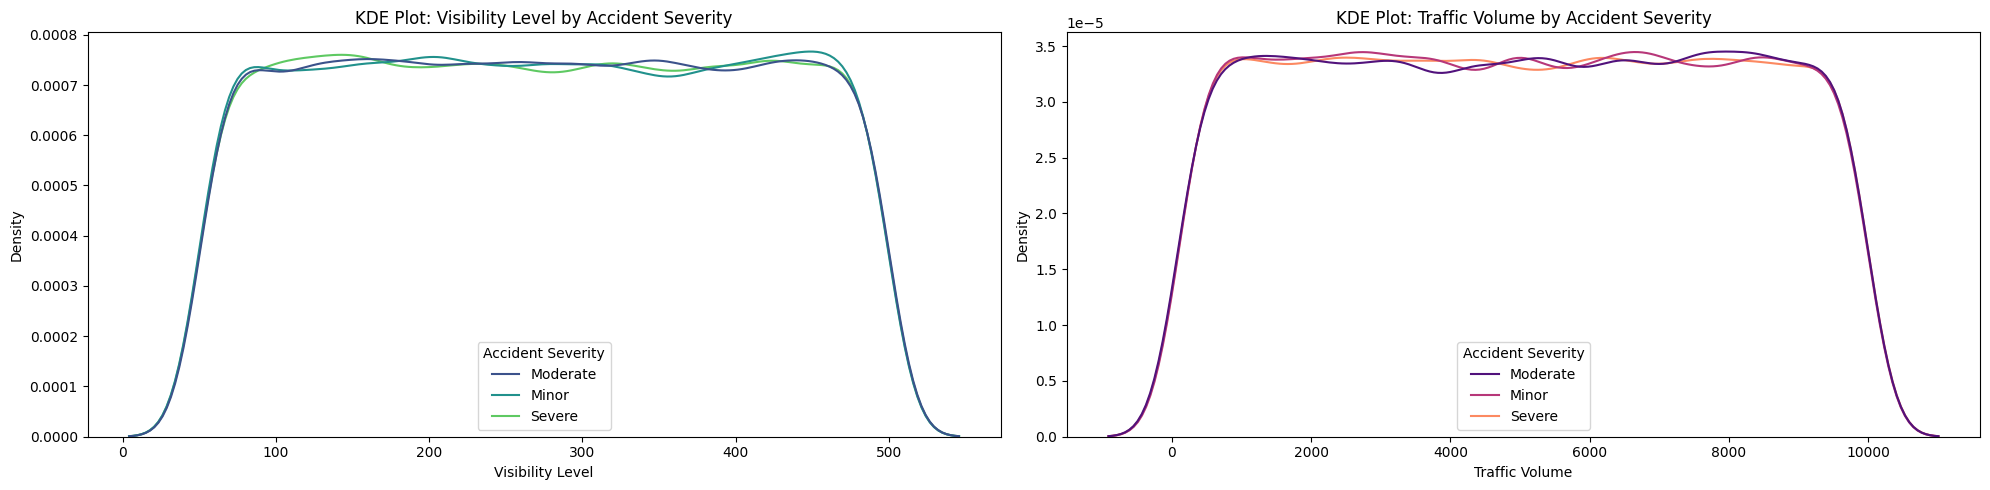

In [59]:
# KDE Plots for Continuous Variables

plt.figure(figsize=(20, 5))

# 1. Visibility Level
plt.subplot(1, 2, 1)
sns.kdeplot(data=data, x="Visibility Level", hue="Accident Severity", fill=False, palette="viridis")
plt.title("KDE Plot: Visibility Level by Accident Severity")
plt.xlabel("Visibility Level")
plt.ylabel("Density")

# 2. Traffic Volume
plt.subplot(1, 2, 2)
sns.kdeplot(data=data, x="Traffic Volume", hue="Accident Severity", fill=False, palette="magma")
plt.title("KDE Plot: Traffic Volume by Accident Severity")
plt.xlabel("Traffic Volume")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

#### **6.7 Number of Vehicles Involved by Environmental and Road Factors**

In [60]:
# Grouping data
num_vehicles_by_roadtype = data.groupby(['Number of Vehicles Involved', 'Road Type']).size().reset_index(name='Count')
num_vehicles_by_roadcondition = data.groupby(['Number of Vehicles Involved', 'Road Condition']).size().reset_index(name='Count')
num_vehicles_by_weather = data.groupby(['Number of Vehicles Involved', 'Weather Conditions']).size().reset_index(name='Count')
num_vehicles_by_traffic_cat = data.groupby(['Number of Vehicles Involved', 'Traffic Volume Category']).size().reset_index(name='Count')
num_vehicles_by_visibility = data.groupby(['Number of Vehicles Involved', 'Visibility Category']).size().reset_index(name='Count')

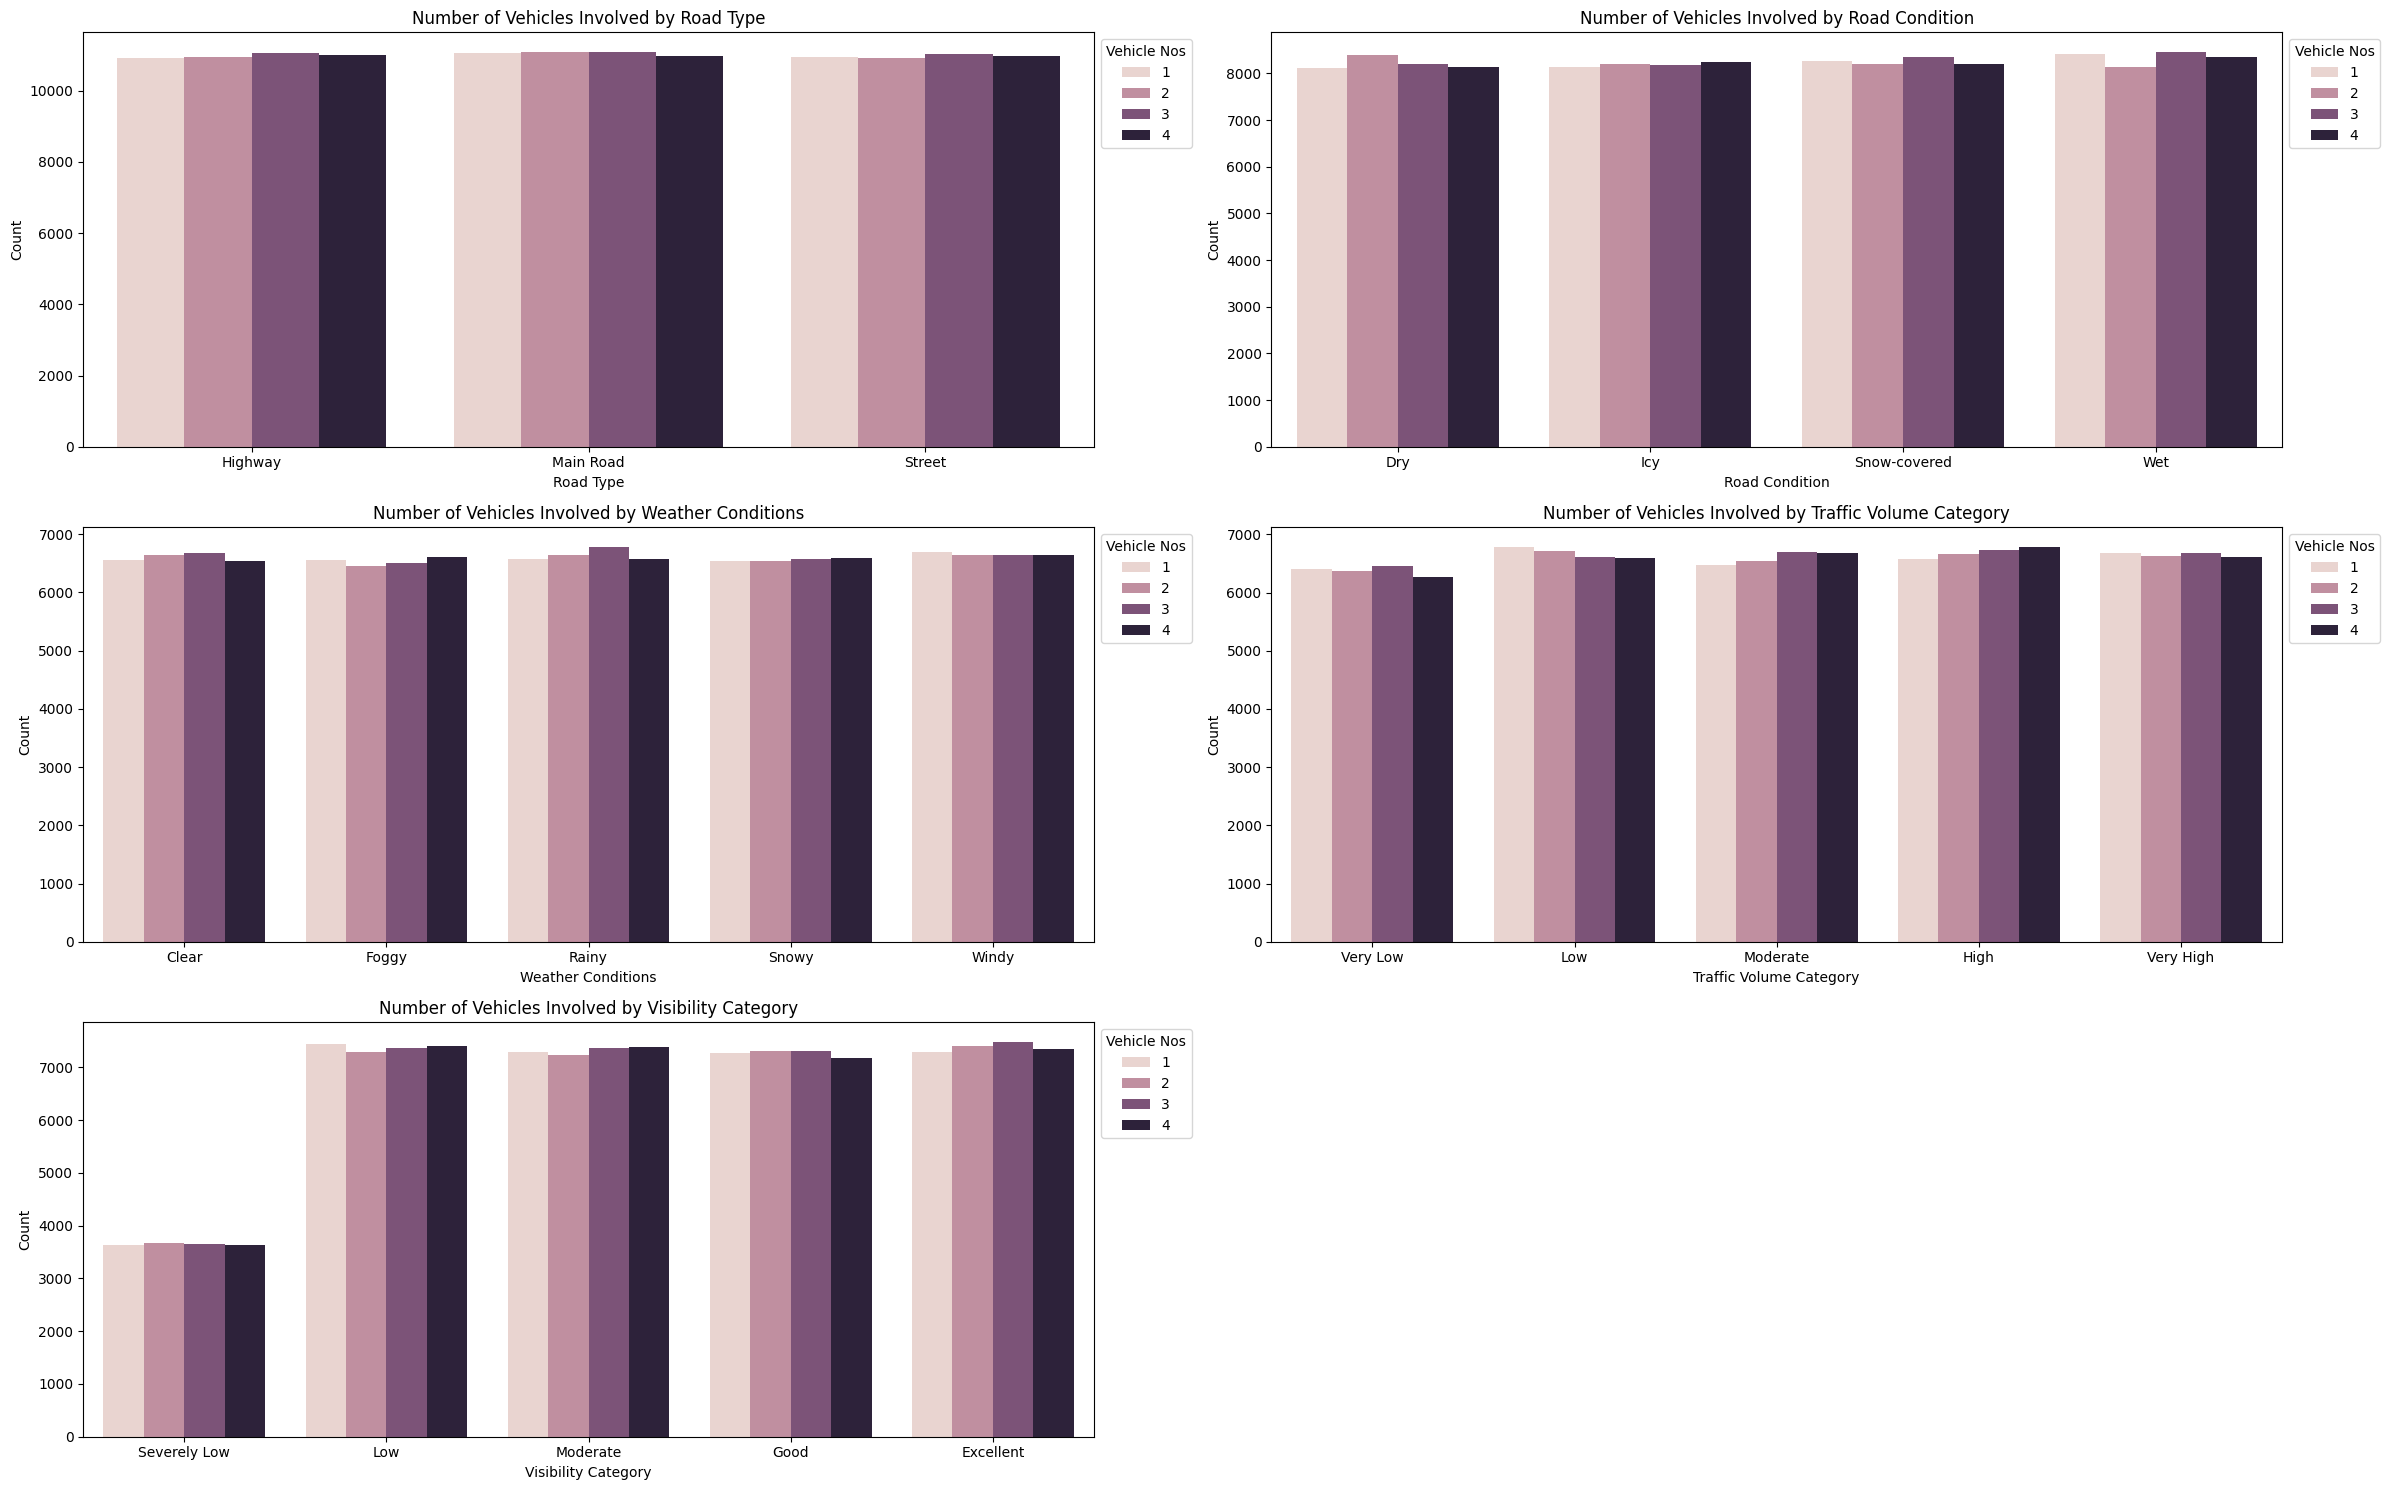

In [61]:
# Function
def plot_num_vehicles(df, xcolumn):
    sns.barplot(data=df, x=xcolumn, y='Count', hue='Number of Vehicles Involved')
    plt.title(f"Number of Vehicles Involved by {xcolumn.title()}")
    plt.xlabel(xcolumn.title())
    plt.ylabel('Count')
    plt.legend(title="Vehicle Nos", loc="upper left", bbox_to_anchor=(1, 1))

# Bar plots
plt.figure(figsize=(24, 15))

# 1. Number of Vehicles Involved Vs Road Type 
plt.subplot(3, 2, 1)
plot_num_vehicles(num_vehicles_by_roadtype, 'Road Type')

# 2. Number of Vehicles Involved Vs Road Condition
plt.subplot(3, 2, 2)
plot_num_vehicles(num_vehicles_by_roadcondition, 'Road Condition')

# 3. Number of Vehicles Involved Vs Weather Conditions
plt.subplot(3, 2, 3)
plot_num_vehicles(num_vehicles_by_weather, 'Weather Conditions')

# 4. Number of Vehicles Involved Vs Traffic Volume Category
plt.subplot(3, 2, 4)
plot_num_vehicles(num_vehicles_by_traffic_cat, 'Traffic Volume Category')

# 5. Number of Vehicles Involved Vs Visibility Category
plt.subplot(3, 2, 5)
plot_num_vehicles(num_vehicles_by_visibility, 'Visibility Category')

plt.tight_layout()
plt.show()

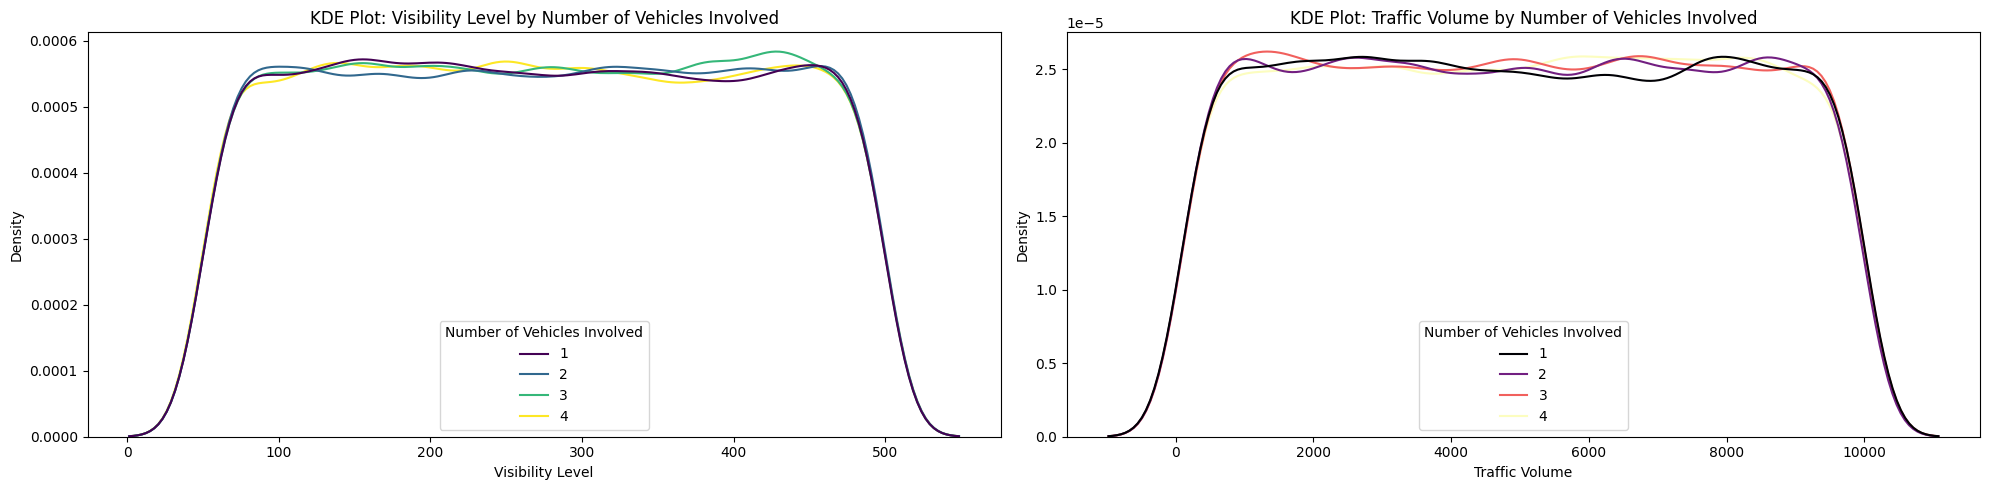

In [62]:
# KDE Plots for Continuous Variables

plt.figure(figsize=(20, 5))

# 1. Visibility Level
plt.subplot(1, 2, 1)
sns.kdeplot(data=data, x="Visibility Level", hue="Number of Vehicles Involved", fill=False, palette="viridis")
plt.title("KDE Plot: Visibility Level by Number of Vehicles Involved")
plt.xlabel("Visibility Level")
plt.ylabel("Density")

# 2. Traffic Volume
plt.subplot(1, 2, 2)
sns.kdeplot(data=data, x="Traffic Volume", hue="Number of Vehicles Involved", fill=False, palette="magma")
plt.title("KDE Plot: Traffic Volume by Number of Vehicles Involved")
plt.xlabel("Traffic Volume")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

## **7. Severity and Impact Analysis**

#### **7.1 Accident Severity and Accident Cause**

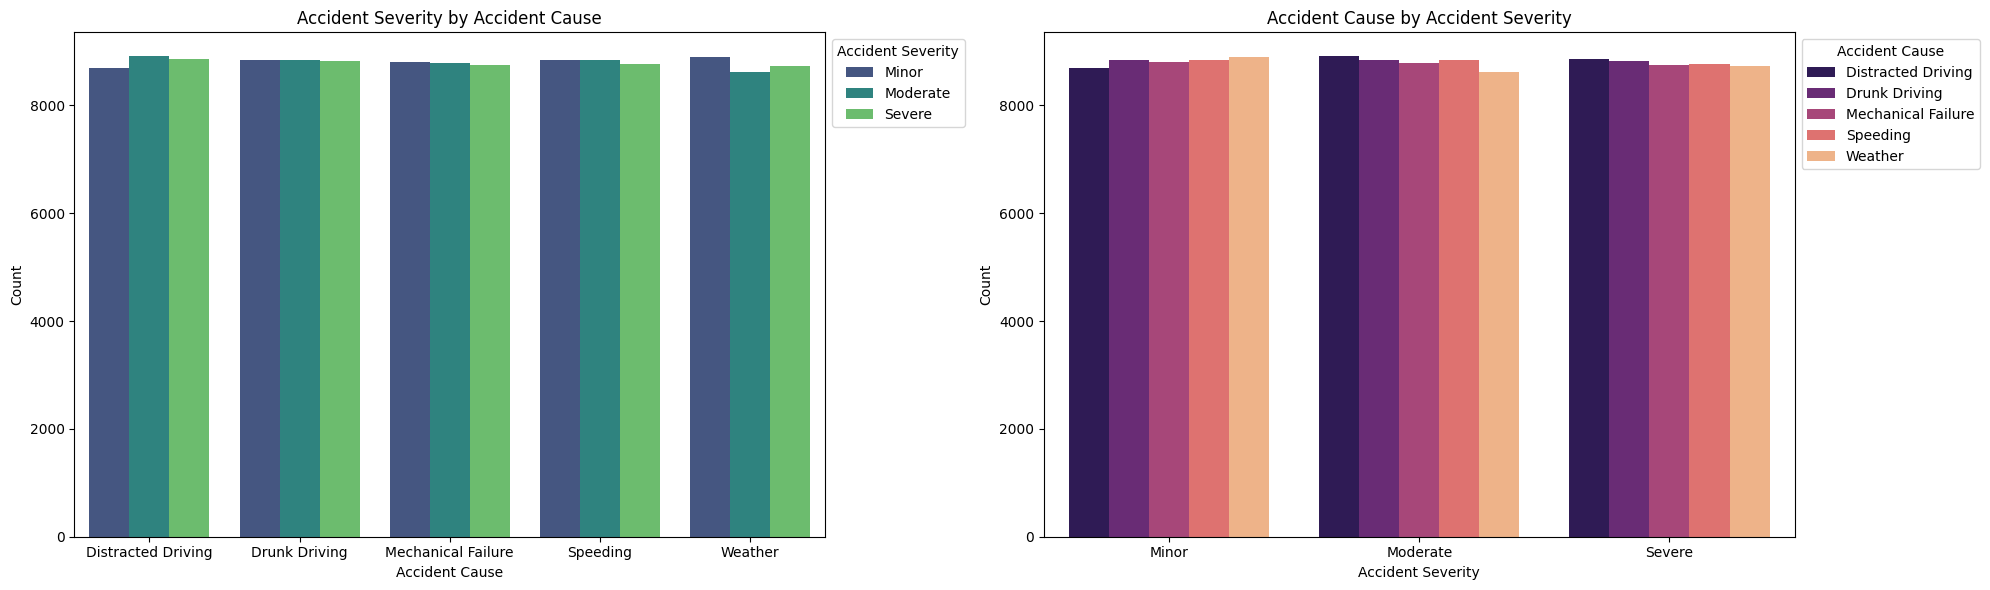

In [63]:
# Grouping data 
accident_severity_by_accidentcause = data.groupby(['Accident Cause', 'Accident Severity']).size().reset_index(name='Count')

# Plot
plt.figure(figsize=(20, 6))

# 1. Accident Cause vs Count
plt.subplot(1, 2, 1)
sns.barplot(data=accident_severity_by_accidentcause, x='Accident Cause', y='Count', hue='Accident Severity', palette="viridis")
plt.title("Accident Severity by Accident Cause")
plt.xlabel("Accident Cause")
plt.ylabel("Count")
plt.legend(title="Accident Severity", loc="upper left", bbox_to_anchor=(1, 1))

# 2. Accident Severity vs Count 
plt.subplot(1, 2, 2)
sns.barplot(data=accident_severity_by_accidentcause, x='Accident Severity', y='Count', hue='Accident Cause', palette="magma")
plt.title("Accident Cause by Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Count")
plt.legend(title="Accident Cause", loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

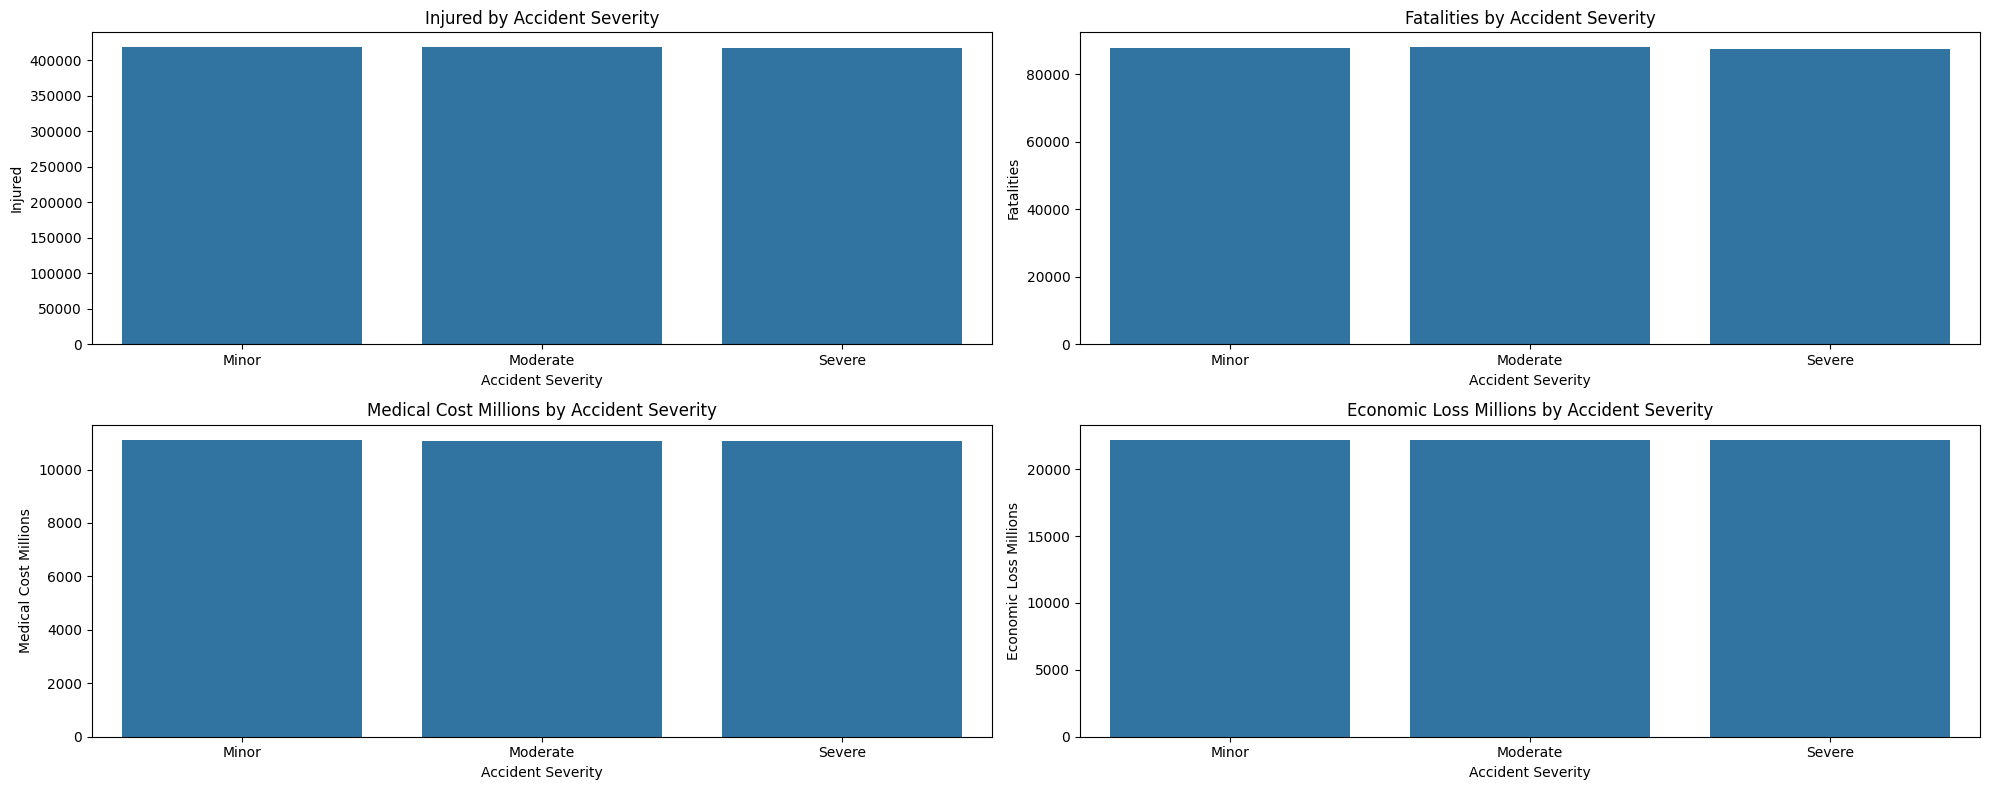

In [64]:
impact_matric_by_accidentseverity= data.groupby('Accident Severity').agg(
    Injured= ("Number of Injuries", 'sum'),
    Fatalities= ("Number of Fatalities", 'sum'),
    Medical_Cost= ("Medical Cost", 'sum'),
    Economic_Loss= ("Economic Loss", 'sum')).reset_index()

# Convert large values into millions
impact_matric_by_accidentseverity['Medical_Cost_Millions'] = impact_matric_by_accidentseverity["Medical_Cost"] / 1_00_000
impact_matric_by_accidentseverity['Economic_Loss_Millions'] = impact_matric_by_accidentseverity["Economic_Loss"] / 1_00_000

# Columns to plot
plot_columns = ["Injured", "Fatalities", "Medical_Cost_Millions", "Economic_Loss_Millions"]

# Plot
nrows, ncols = 2, 2
plt.figure(figsize=(nrows * 10, ncols * 4))

for i, j in enumerate(plot_columns):
    plt.subplot(nrows, ncols, i + 1)
    sns.barplot(data=impact_matric_by_accidentseverity, x='Accident Severity', y=j)
    plt.title(f"{j.replace('_', ' ').title()} by Accident Severity")
    plt.xlabel("Accident Severity")
    plt.ylabel(f"{j.replace('_', ' ').title()}")

plt.tight_layout()
plt.show()

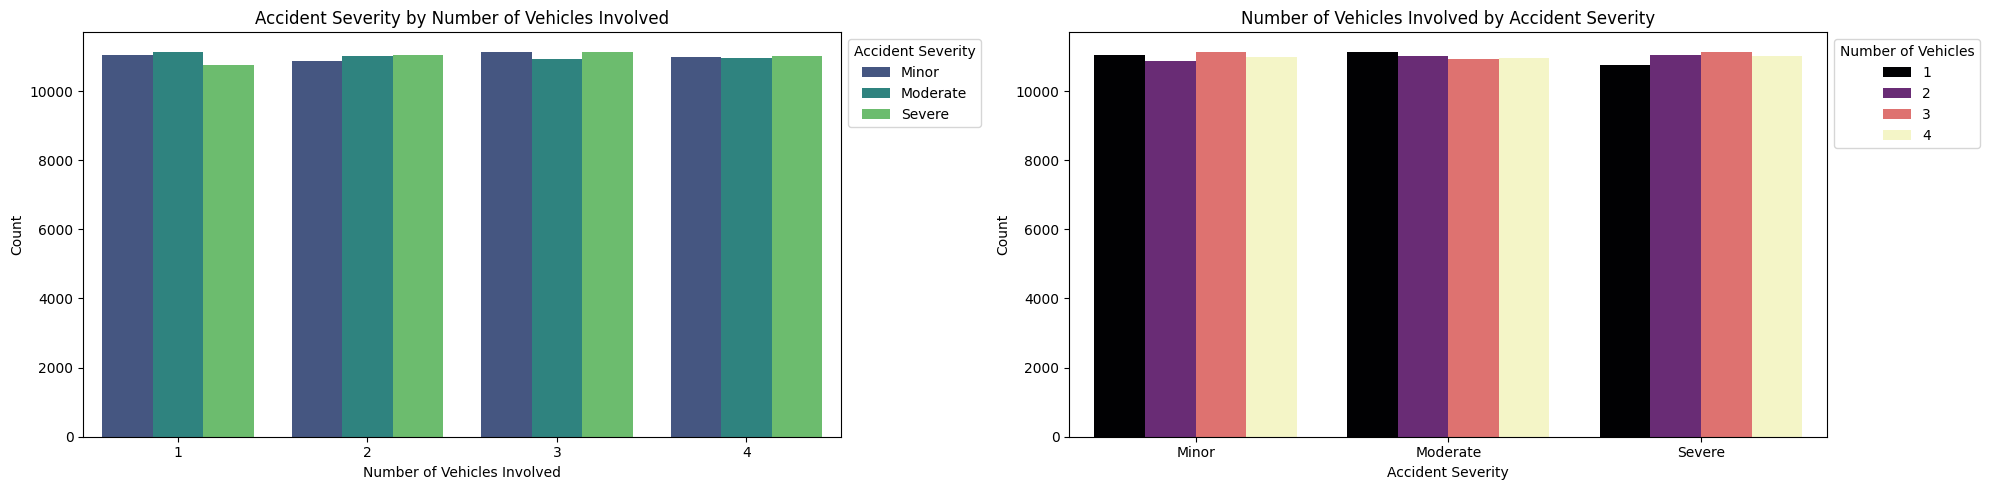

In [65]:
# Grouping data 
accident_severity_by_vehiclenumber = data.groupby(['Accident Severity', 'Number of Vehicles Involved']).size().reset_index(name= 'Count')

# Plot
plt.figure(figsize=(20, 5))

# 1. Number of Vehicles Involved vs Count
plt.subplot(1, 2, 1)
sns.barplot(data=accident_severity_by_vehiclenumber, x='Number of Vehicles Involved', y='Count', hue='Accident Severity', palette="viridis")
plt.title("Accident Severity by Number of Vehicles Involved")
plt.xlabel("Number of Vehicles Involved")
plt.ylabel("Count")
plt.legend(title="Accident Severity", loc="upper left", bbox_to_anchor=(1, 1))

# 2. Accident Severity vs Count 
plt.subplot(1, 2, 2)
sns.barplot(data=accident_severity_by_vehiclenumber, x='Accident Severity', y='Count', hue='Number of Vehicles Involved', palette="magma")
plt.title("Number of Vehicles Involved by Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Count")
plt.legend(title="Number of Vehicles", loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()